# SPY Intraday Momentum: Replication and Original Research

**Research question.** Can a time-of-day breakout, disciplined exits and lagged risk sizing exploit persistent intraday price moves after linear transaction costs? Do additional entry filters or risk-allocation models improve the same baseline?

The primary reference is Carlo Zarattini, Andrew Aziz and Andrea Barbon, *Beat the Market: An Effective Intraday Momentum Strategy for S&P500 ETF (SPY)*, version **3 February 2025**. Page references use the printed PDF pages.

**Read in this order:** data and timing -> noise area -> opposite-band strategy -> current-band/VWAP exit -> volatility sizing -> ER -> LSTM -> TCN and Ridge -> consolidated saved evidence -> pending persistence/risk-control experiments -> research interpretation.

**Evidence status.** The uploaded notebook contains saved results for Sections 2-10 and 12 saved figures. Their trading calculations have not been rerun during packaging because the source CSV datasets were not attached. The consolidated overview is rebuilt only from the printed saved statistics. Section 11 has no saved full-SPY results; software checks on small synthetic fixtures do not establish its investment performance.

**Portable execution.** Downloading is off by default. The project uses the local data folder, or the path set by the SPY_DATA_DIR environment variable. Credentials belong in environment variables or a local .env file. See README.md for installation and execution commands.


## 0. Research design and notation

| Stage | Question answered | Paper location / status |
|---|---|---|
| Data and calendar | Which prices exist and when are they observable? | §2, p. 6; implementation audit |
| Noise area | Is the move unusually large for this time of day? | §3, pp. 6–8 |
| Opposite-band strategy | Does the simplest breakout rule earn net returns? | §3, pp. 9–11 |
| Current band + VWAP | Can earlier exits contain reversals? | §3, pp. 12–14 |
| Volatility sizing | How much capital should be allocated each morning? | §3, pp. 14–15 |
| ER / LSTM / TCN + Ridge | Does added information improve the same baseline? | Original extensions |

Notation: $t$ is a trading session; $\tau$ is a completed minute within that session; $O_t$ is the session opening price; $P_{t,\tau}$ is the completed minute close; $C_t$ is the daily close; $E_{t-1}$ is the preceding session's closing equity. $V_{t,\tau}$ is minute volume, $Q_t$ is the daily share size, and $s_{t,\tau}\in\{-1,0,1\}$ is short/flat/long.

| Role | Dates in this notebook | Use |
|---|---|---|
| Warm-up | 4 Jan–29 Feb 2016 | Build rolling features; excluded from strategy returns |
| Development | 1 Mar 2016–31 Dec 2020 | Fit preprocessing and learned models |
| Validation | Trading sessions in 2021 | Choose thresholds and checkpoints |
| Historical test | 3 Jan 2022–30 Apr 2024 | Evaluate the frozen choices |

The replication's `train` label combines development and validation. The extensions subdivide it chronologically; no random train/test split is used. The paper's main backtest covers **May 2007–April 2024 using IQFeed and Matlab**, whereas this notebook uses **Alpaca SIP data and Python from March 2016**. Matching the stated rules does not imply matching its full-sample performance numbers. The historical test has already been inspected during research and should not be described as a fresh blind test.

## 1. Data pipeline
### 1.1 Configuration, dependencies and sample boundaries

**Paper:** SPY minute OHLCV is the trading input (§2, p. 6). **Implementation:** request unadjusted SIP minute bars, raw and fully adjusted daily bars, corporate actions and Cboe daily VIX. Minute execution prices must be expressed in the same dollar units as the per-share trading costs.

`DATA_START` precedes `ANALYSIS_START` so both 14-session rolling estimates and the later 20-session LSTM windows have history before evaluation begins. `OVERWRITE=False` reuses cached downloads. Dependencies are `pandas`, `numpy`, `requests`, `pandas_market_calendars`, `alpaca-py`, `matplotlib`, `torch` and `scikit-learn` across the whole notebook.

In [3]:
import os
import json
from io import StringIO
from pathlib import Path
from getpass import getpass

import pandas as pd
import requests
import pandas_market_calendars as mcal

from alpaca.data.historical import StockHistoricalDataClient
from alpaca.data.historical.corporate_actions import CorporateActionsClient
from alpaca.data.requests import StockBarsRequest, CorporateActionsRequest
from alpaca.data.timeframe import TimeFrame
from alpaca.data.enums import Adjustment


# ================= USER CONFIGURATION =================

API_KEY = ""  # Use environment variables or the existing getpass prompt.
API_SECRET = ""  # Use environment variables or the existing getpass prompt.

DATA_START = "2016-01-04"
ANALYSIS_START = "2016-03-01"     # Earlier observations are used for warm-up.
TRAIN_END = "2021-12-31"
END_DATE = "2024-04-30"

# Find the project root when launched from the root or notebooks directory.
_cwd = Path.cwd().resolve()
PROJECT_ROOT = next(
    (p for p in (_cwd, _cwd.parent)
     if (p / "notebooks").is_dir() and (p / "README.md").is_file()),
    _cwd,
)
try:
    from dotenv import load_dotenv
    load_dotenv(PROJECT_ROOT / ".env", override=False)
except ImportError:
    pass  # Environment variables and getpass also work without python-dotenv.

_default_data = PROJECT_ROOT / "data" if (PROJECT_ROOT / "notebooks").is_dir() else PROJECT_ROOT
_data_setting = Path(os.getenv("SPY_DATA_DIR", str(_default_data))).expanduser()
SAVE_DIR = (
    _data_setting if _data_setting.is_absolute()
    else PROJECT_ROOT / _data_setting
).resolve()
RUN_DOWNLOADS = os.getenv("SPY_RUN_DOWNLOADS", "0").lower() in {"1", "true", "yes"}

OVERWRITE = False               # Set to True to refresh cached data.

# ======================================================

SYMBOL = "SPY"
NY = "America/New_York"
CACHE_DIR = SAVE_DIR / "alpaca_cache"




### 1.2 Normalize bars and write cache files

UTC timestamps provide an unambiguous time axis; New York dates identify the exchange session. Normalize numeric columns, check prices/volumes and duplicate timestamps before downstream joins. These are implementation checks, rather than additional trading signals.

The temporary-file replacement in `save_csv` prevents a partially written CSV from being mistaken for a completed cache after an interrupted write.

In [4]:
def save_csv(df, path):
    """Write to a temporary file before replacing the destination."""
    temp = path.with_suffix(".tmp")
    df.to_csv(temp, index=False, encoding="utf-8-sig")
    temp.replace(path)


def normalize_bars(df):
    """Standardize timestamps and numeric fields, then validate the bars."""
    df = df.copy()

    df["timestamp"] = pd.to_datetime(df.timestamp, utc=True)
    df["date"] = (
        df.timestamp.dt.tz_convert(NY)
        .dt.strftime("%Y-%m-%d")
    )
    df = df.sort_values("timestamp").reset_index(drop=True)

    if df.timestamp.duplicated().any():
        raise ValueError("Duplicate bar timestamps detected.")

    numeric = [
        "open", "high", "low", "close",
        "volume", "vwap", "trade_count",
    ]
    df[numeric] = df[numeric].apply(
        pd.to_numeric, errors="raise"
    )

    if df[numeric].isna().any().any() or df.volume.le(0).any():
        raise ValueError("Missing values or non-positive volume detected.")

    if df[
        ["open", "high", "low", "close", "vwap"]
    ].le(0).any().any():
        raise ValueError("Non-positive prices detected.")

    return df




### 1.3 Download complete monthly batches

The SDK handles pagination; month-sized cache files allow interrupted downloads to resume. Requests cover the first session from local midnight through the final session's close. After concatenation, bars pass through the same normalization routine.

**Interview point:** API limits, feed coverage and bar timestamps are part of the research implementation. A strategy can appear to fail simply because a batch is truncated or a session boundary is misinterpreted.

In [5]:
def fetch_bars(client, schedule, timeframe, adjustment, tag):
    """Download bars in monthly batches with automatic SDK pagination."""
    frames = []

    for month, part in schedule.groupby(
        schedule.index.to_period("M")
    ):
        first = part.index[0].strftime("%Y-%m-%d")
        last = part.index[-1].strftime("%Y-%m-%d")

        # Include the requested date range in each cache filename.
        path = CACHE_DIR / (
            f"{SYMBOL}_sip_{tag}_{first}_{last}.csv"
        )

        if path.exists() and not OVERWRITE:
            batch = pd.read_csv(path)
            print(f"{tag} {month}: loaded from cache")

        else:
            req = StockBarsRequest(
                symbol_or_symbols=SYMBOL,
                timeframe=timeframe,

                # Midnight is required to include the first daily bar.
                start=pd.Timestamp(
                    first, tz=NY
                ).to_pydatetime(),

                end=(
                    part.market_close.iloc[-1]
                    - pd.Timedelta(microseconds=1)
                ).to_pydatetime(),

                feed="sip",
                adjustment=adjustment,

                # Do not cap the total number of bars across all pages.
                limit=None,
            )

            batch = client.get_stock_bars(req).df

            if batch.empty:
                raise RuntimeError(
                    f"{tag} {month}: no bars returned by the API."
                )

            batch = batch.reset_index()
            save_csv(batch, path)

            print(
                f"{tag} {month}: downloaded {len(batch):,} bars"
            )

        frames.append(batch)

    return normalize_bars(
        pd.concat(frames, ignore_index=True)
    )




### 1.4 Corporate actions and dividend records

Corporate-action records are collected over a broad processing-date window, then filtered by their effective ex-dates. Keep both dividend and split records to explain changes in the adjusted/raw price ratio.

$$a_t=\frac{C_t^{\mathrm{adjusted}}}{C_t^{\mathrm{raw}}}.$$

A material change in $a_t$ should have a corresponding corporate-action record. Dividend amounts are obtained from records, rather than inferred from a price gap. This is a data-consistency check; it does not by itself modify the intraday signal.

In [6]:
def fetch_actions(client):
    """Download corporate actions and filter by their effective ex-dates."""
    # The endpoint filters by process_date rather than ex_date.
    # Query a broad processing window before applying the local ex-date filter.
    today = pd.Timestamp.now(tz="UTC").date()

    path = CACHE_DIR / (
        f"{SYMBOL}_actions_1993_{today}.json"
    )

    if path.exists() and not OVERWRITE:
        payload = json.loads(
            path.read_text(encoding="utf-8")
        )

    else:
        payload = client.get_corporate_actions(
            CorporateActionsRequest(
                symbols=[SYMBOL],
                start=pd.Timestamp("1993-01-01").date(),
                end=today,
                limit=None,
            )
        )

        path.write_text(
            json.dumps(payload, ensure_ascii=False, indent=2),
            encoding="utf-8",
        )

    records = []

    for kind, items in payload.items():
        if isinstance(items, list):
            records.extend(
                dict(item, action_group=kind)
                for item in items
            )

    actions = pd.DataFrame(records)

    if actions.empty or "ex_date" not in actions:
        raise RuntimeError(
            "No SPY corporate actions retrieved. "
            "Missing dividend data must not be treated as zero."
        )

    actions["ex_date"] = pd.to_datetime(
        actions.ex_date, errors="raise"
    ).dt.strftime("%Y-%m-%d")

    actions = actions.loc[
        actions.ex_date.between(DATA_START, END_DATE)
    ].copy()

    if "id" in actions:
        actions = actions.drop_duplicates("id")

    dividends = actions.loc[
        actions.action_group.eq("cash_dividends")
    ].copy()

    if dividends.empty:
        raise RuntimeError(
            "No SPY cash dividends retrieved for the selected period."
        )

    dividends["rate"] = pd.to_numeric(
        dividends.rate, errors="raise"
    )

    dividends = dividends.rename(
        columns={
            "ex_date": "date",
            "rate": "dividend",
        }
    ).sort_values("date")

    # Preserve split-related records for subsequent adjustment checks.
    splits = actions.loc[
        actions.action_group.isin([
            "forward_splits",
            "reverse_splits",
            "unit_splits",
            "stock_dividends",
        ])
    ].copy()

    return actions, dividends, splits




### 1.5 VIX observations and their information time

The Cboe file supplies daily VIX OHLC. For a decision at the SPY open, the current session's **closing** VIX is not yet known. A causal opening-time feature can therefore use

$$\mathrm{VIX}^{\mathrm{available}}_t=\mathrm{VIX}^{\mathrm{close}}_{t-1}.$$

The paper's volatility-regime analysis uses VIX at the market open (§4.1, pp. 17–18). Daily lagged VIX here is a different data convention, used later by the LSTM; it is not a filter in the three replication strategies.

In [7]:
def fetch_vix():
    """Download official daily VIX observations from Cboe."""
    url = (
        "https://cdn-api.cboe.com/api/global/"
        "us_indices/daily_prices/VIX_History.csv"
    )

    path = CACHE_DIR / (
        f"VIX_{DATA_START}_{END_DATE}.csv"
    )

    if path.exists() and not OVERWRITE:
        return pd.read_csv(path, dtype={"date": str})

    response = requests.get(url, timeout=(10, 60))
    response.raise_for_status()

    vix = pd.read_csv(StringIO(response.text))
    vix.columns = vix.columns.str.strip().str.lower()

    vix["date"] = pd.to_datetime(
        vix.date,
        format="%m/%d/%Y",
        errors="raise",
    ).dt.strftime("%Y-%m-%d")

    vix = vix.loc[
        vix.date.between(DATA_START, END_DATE)
    ].copy()

    if vix.empty or vix.date.duplicated().any():
        raise ValueError("Empty VIX data or duplicate dates detected.")

    cols = ["open", "high", "low", "close"]
    vix[cols] = vix[cols].apply(
        pd.to_numeric, errors="raise"
    )

    if (
        vix[cols].isna().any().any()
        or vix[cols].le(0).any().any()
    ):
        raise ValueError("Missing or non-positive VIX values detected.")

    vix = vix.sort_values("date").reset_index(drop=True)
    save_csv(vix, path)

    return vix




### 1.6 Regular hours, completed bars and cumulative VWAP

The exchange calendar defines open/close, daylight-saving changes and early closes. A bar stamped 09:59 contains the interval ending at **10:00**; its close is observable at 10:00. The first decision then uses the following 10:00 minute's open as its execution reference.

Two session-reset VWAP estimates are retained:

$$\mathrm{VWAP}^{\mathrm{SIP}}_{t,\tau}=\frac{\sum_{k\le\tau}v^{\mathrm{minute}}_{t,k}V_{t,k}}{\sum_{k\le\tau}V_{t,k}},\qquad
\widetilde{\mathrm{VWAP}}_{t,\tau}=\frac{\sum_{k\le\tau}\frac{H_{t,k}+L_{t,k}+P_{t,k}}{3}V_{t,k}}{\sum_{k\le\tau}V_{t,k}}.$$

The strategy uses the second, HLC3-based series (`vwap_paper`). The article states that VWAP uses market-hours data (p. 13), but its displayed strategy equations do not specify this minute-price approximation. Treat HLC3 as the notebook's implementation convention, not as an equation explicitly specified by the paper. Missing minutes are left unfilled and reported.

In [8]:
def prepare_minutes(raw, calendar):
    """Filter regular trading hours and calculate two cumulative VWAPs."""
    df = raw.merge(
        calendar[
            ["date", "market_open", "market_close", "split"]
        ],
        on="date",
        how="inner",
        validate="many_to_one",
    )

    # The calendar handles holidays, early closes, and daylight saving time.
    df = df.loc[
        df.timestamp.ge(df.market_open)
        & df.timestamp.lt(df.market_close)
    ].copy().sort_values("timestamp").reset_index(drop=True)

    if df.empty:
        raise ValueError("No minute bars within regular trading hours.")

    df["timestamp_ny"] = df.timestamp.dt.tz_convert(NY)

    # Bar timestamps identify the beginning of each minute.
    # The completed bar becomes available after the corresponding minute ends.
    df["bar_end_ny"] = (
        df.timestamp_ny + pd.Timedelta(minutes=1)
    )

    df["minute_since_open"] = (
        (df.timestamp - df.market_open)
        .dt.total_seconds() / 60
    ).astype(int)

    df = df.rename(columns={"vwap": "vwap_minute"})

    df["hlc3"] = (
        df.high + df.low + df.close
    ) / 3

    # Estimate traded dollar volume using Alpaca's minute VWAP.
    df["dollar_volume"] = df.vwap_minute * df.volume
    df["hlc3_volume"] = df.hlc3 * df.volume

    groups = df.groupby("date", sort=False)
    cum_volume = groups.volume.cumsum()

    # Cumulative VWAP based on the provider's minute trade VWAP.
    df["vwap_sip"] = (
        groups.dollar_volume.cumsum() / cum_volume
    )

    # Cumulative HLC3-based VWAP used in the authors' public Python example.
    df["vwap_paper"] = (
        groups.hlc3_volume.cumsum() / cum_volume
    )

    quality = calendar[
        ["date", "split", "expected_minutes"]
    ].copy()

    quality["downloaded_minutes"] = (
        quality.date.map(df.groupby("date").size())
        .fillna(0)
        .astype(int)
    )

    quality["missing_minutes"] = (
        quality.expected_minutes
        - quality.downloaded_minutes
    )

    first = df.groupby("date").timestamp.min()
    last = df.groupby("date").timestamp.max()

    quality["has_open_bar"] = (
        quality.date.map(first).eq(calendar.market_open)
    )

    quality["has_close_bar"] = (
        quality.date.map(last).eq(
            calendar.market_close
            - pd.Timedelta(minutes=1)
        )
    )

    # Leave missing minutes unfilled.
    return (
        df.drop(
            columns=[
                "market_open",
                "market_close",
                "hlc3_volume",
            ]
        ),
        quality,
    )




### 1.7 Daily features, adjustment checks and lagged risk

Maintain separate daily return series:

$$r_t^{\mathrm{raw}}=\frac{C_t^{\mathrm{raw}}}{C_{t-1}^{\mathrm{raw}}}-1,\qquad
r_t^{\mathrm{adjusted}}=\frac{C_t^{\mathrm{adjusted}}}{C_{t-1}^{\mathrm{adjusted}}}-1.$$

Raw returns drive the daily sizing volatility; adjusted returns provide the passive SPY benchmark. The estimated risk for day $t$ uses only completed returns $r_{t-14},\ldots,r_{t-1}$.

The file also records $C_{t-1}^{\mathrm{raw}}-D_t$ as `prev_close_ex_dividend`. **The current noise-boundary code actually uses `prev_close_raw`**, consistent with the displayed prior-close anchor on p. 7. Computing the ex-dividend column should not be mistaken for applying it to the signal.

In [9]:
def prepare_daily(
    raw, adjusted, dividends, actions, vix, calendar
):
    """Combine daily prices, dividends, lagged volatility, and lagged VIX."""
    for frame in [raw, adjusted]:
        if frame.date.duplicated().any():
            raise ValueError("Duplicate daily dates detected.")

    daily = calendar[["date", "split"]].merge(
        raw[
            ["date", "open", "high", "low", "close", "volume"]
        ],
        on="date",
        how="left",
        validate="one_to_one",
    )

    daily = daily.merge(
        adjusted[["date", "close"]].rename(
            columns={"close": "adjusted_close"}
        ),
        on="date",
        how="left",
        validate="one_to_one",
    )

    price_cols = [
        "open", "high", "low", "close", "adjusted_close"
    ]

    if daily[price_cols].isna().any().any():
        raise ValueError(
            "At least one session is missing raw or adjusted daily prices."
        )

    # Flag adjustment-factor changes without corresponding corporate actions.
    # Do not infer or fabricate dividend amounts from price changes.
    factor = daily.adjusted_close / daily.close

    changed = daily.loc[
        factor.pct_change(
            fill_method=None
        ).abs().gt(0.0001),
        "date",
    ]

    missing = sorted(
        set(changed) - set(actions.ex_date)
    )

    if missing:
        raise RuntimeError(
            "Adjustment-factor changes have no corresponding "
            f"corporate-action records on: {missing}. "
            "Downloaded bars remain cached. "
            "Complete the corporate-action data before proceeding."
        )

    div_by_day = dividends.groupby("date").dividend.sum()

    daily["dividend"] = (
        daily.date.map(div_by_day).fillna(0.0)
    )

    daily["prev_close_raw"] = daily.close.shift(1)

    daily["prev_close_ex_dividend"] = (
        daily.prev_close_raw - daily.dividend
    )

    daily["return_raw"] = daily.close.pct_change(
        fill_method=None
    )

    daily["return_adjusted"] = (
        daily.adjusted_close.pct_change(
            fill_method=None
        )
    )

    # Use only the previous 14 completed daily returns for position sizing.
    daily["vol14_lagged"] = (
        daily.return_raw
        .rolling(14)
        .std(ddof=1)
        .shift(1)
    )

    daily = daily.merge(
        vix[["date", "close"]].rename(
            columns={"close": "vix_close"}
        ),
        on="date",
        how="left",
        validate="one_to_one",
    )

    # Today's closing VIX is unavailable at today's market open.
    # Use the previous trading day's closing VIX for an opening-time filter.
    daily["vix_prev_close"] = daily.vix_close.shift(1)

    return daily




### 1.8 Orchestrate downloads and retain provenance

The orchestrator creates the NYSE calendar, assigns warm-up/train/test labels by date, requests the source tables, builds features and writes the project CSVs plus a configuration record. The final requested session must already have closed.

`SPY_1min.csv`, `SPY_daily_features.csv` and `NYSE_calendar.csv` are the main downstream inputs. `quality_report.csv` records expected/downloaded minutes and opening/closing-bar coverage; `project_config.json` records settings without credentials. Keep unsuccessful/incomplete sessions in the calendar so subsequent rolling windows represent **14 actual trading sessions**.

In [10]:
def download_project_data():
    if not (
        DATA_START
        <= ANALYSIS_START
        <= TRAIN_END
        < END_DATE
    ):
        raise ValueError(
            "Download, warm-up, training, and test dates are inconsistent."
        )

    SAVE_DIR.mkdir(parents=True, exist_ok=True)
    CACHE_DIR.mkdir(parents=True, exist_ok=True)

    schedule = mcal.get_calendar("NYSE").schedule(
        DATA_START, END_DATE
    )

    if schedule.empty:
        raise ValueError("No trading sessions in the selected period.")

    # Restrict requests to completed historical sessions.
    # A 20-minute buffer accommodates delayed historical SIP access.
    cutoff = (
        pd.Timestamp.now(tz="UTC")
        - pd.Timedelta(minutes=20)
    )

    if schedule.market_close.iloc[-1] > cutoff:
        raise ValueError(
            "The final session must have closed at least 20 minutes ago."
        )

    calendar = schedule.reset_index(names="session_date")

    calendar["date"] = (
        calendar.session_date.dt.strftime("%Y-%m-%d")
    )

    calendar["expected_minutes"] = (
        (calendar.market_close - calendar.market_open)
        .dt.total_seconds() / 60
    ).astype(int)

    # Apply a chronological split without shuffling observations.
    calendar["split"] = "test"
    calendar.loc[
        calendar.date.le(TRAIN_END), "split"
    ] = "train"
    calendar.loc[
        calendar.date.lt(ANALYSIS_START), "split"
    ] = "warmup"

    # Read credentials from configuration, environment variables, or prompts.
    key = (
        API_KEY.strip()
        or os.getenv("APCA_API_KEY_ID", "").strip()
        or getpass("Alpaca API Key ID: ").strip()
    )

    secret = (
        API_SECRET.strip()
        or os.getenv("APCA_API_SECRET_KEY", "").strip()
        or getpass("Alpaca Secret Key: ").strip()
    )

    if not key or not secret:
        raise ValueError("Both API Key and Secret Key are required.")

    stock = StockHistoricalDataClient(key, secret)

    # Raw responses preserve all available corporate-action fields.
    ca_client = CorporateActionsClient(
        key, secret, raw_data=True
    )

    minute_raw = fetch_bars(
        stock,
        schedule,
        TimeFrame.Minute,
        Adjustment.RAW,
        "1min_raw",
    )

    daily_raw = fetch_bars(
        stock,
        schedule,
        TimeFrame.Day,
        Adjustment.RAW,
        "daily_raw",
    )

    daily_adjusted = fetch_bars(
        stock,
        schedule,
        TimeFrame.Day,
        Adjustment.ALL,
        "daily_all",
    )

    actions, dividends, splits = fetch_actions(ca_client)
    vix = fetch_vix()

    minutes, quality = prepare_minutes(
        minute_raw, calendar
    )

    daily = prepare_daily(
        daily_raw,
        daily_adjusted,
        dividends,
        actions,
        vix,
        calendar,
    )

    if quality.downloaded_minutes.eq(0).any():
        raise RuntimeError(
            "At least one trading session has no minute bars. "
            "Check the cached data."
        )

    outputs = {
        "SPY_1min.csv": minutes,
        "SPY_daily_raw.csv": daily_raw,
        "SPY_daily_adjusted.csv": daily_adjusted,
        "SPY_dividends.csv": dividends,
        "SPY_splits.csv": splits,
        "SPY_corporate_actions.csv": actions,
        "VIX_daily.csv": vix,
        "NYSE_calendar.csv": calendar,
        "SPY_daily_features.csv": daily,
        "quality_report.csv": quality,
    }

    for name, frame in outputs.items():
        save_csv(frame, SAVE_DIR / name)

    # Record dataset settings and quality summaries without credentials.
    config = {
        "symbol": SYMBOL,
        "feed": "sip",
        "data_start": DATA_START,
        "analysis_start": ANALYSIS_START,
        "train_end": TRAIN_END,
        "end_date": END_DATE,

        "downloaded_at_utc": (
            pd.Timestamp.now(tz="UTC").isoformat()
        ),

        "minute_rows": len(minutes),

        "missing_minute_days": int(
            quality.missing_minutes.gt(0).sum()
        ),

        "vix_missing_days": int(
            daily.vix_close.isna().sum()
        ),

        "vwap_paper": (
            "cumulative HLC3 * volume / "
            "cumulative volume, RTH only"
        ),

        "vix_signal": (
            "previous trading day's daily close"
        ),
    }

    (SAVE_DIR / "project_config.json").write_text(
        json.dumps(config, ensure_ascii=False, indent=2),
        encoding="utf-8",
    )

    print(
        f"\nCompleted: {len(minutes):,} minute bars "
        f"across {len(daily):,} trading sessions."
    )
    print("Output directory:", SAVE_DIR.resolve())
    print(
        "Sessions with missing minute bars:",
        config["missing_minute_days"],
    )

    return minutes, daily, quality




### 1.9 Optional data download

Set SPY_RUN_DOWNLOADS=1 only when you intend to request data. The downloader writes monthly cache batches and the ten project CSVs. Downloading is disabled by default so opening or running this notebook does not silently start API requests.

The retained log below is historical output from the uploaded run: 814,246 minute bars, 2,095 calendar sessions and eight sessions with missing bars. The private local directory has been removed. It is not a newly executed download log.


In [11]:
if RUN_DOWNLOADS:
    minutes, daily_features, quality = download_project_data()
else:
    print("Downloads skipped. Use existing CSV files in:", SAVE_DIR)


Downloads skipped. Use existing CSV files in: D:\WU 学习资料\WUTIS


## 2. Construct the noise area
### 2.1 Load and align the trading sessions

**Paper, §3, pp. 6–8:** compare the current intraday move with historical moves over the **same open-to-time interval**. Load the minute bars and daily/session tables, normalize time zones and verify one-to-one timestamp coverage within exchange hours.

The lookback is fixed at $L=14$ trading sessions and the volatility multiplier at $\mathrm{VM}=1$, matching the paper's main specification. These constants are not tuned on the historical test.

In [12]:
from pathlib import Path
import pandas as pd

# Use the same folder as SAVE_DIR in the download script.
DATA_DIR = SAVE_DIR
LOOKBACK = 14
VOL_MULTIPLIER = 1.0

bars = pd.read_csv(
    DATA_DIR / "SPY_1min.csv",
    usecols=["timestamp", "open", "close", "split"],
)
daily = pd.read_csv(DATA_DIR / "SPY_daily_features.csv")
calendar = pd.read_csv(DATA_DIR / "NYSE_calendar.csv")

# Parse timestamps in UTC, then derive the New York trading date.
bars["timestamp"] = pd.to_datetime(bars["timestamp"], utc=True)
bars["date"] = (
    bars["timestamp"].dt.tz_convert("America/New_York")
    .dt.tz_localize(None).dt.normalize()
)
daily["date"] = pd.to_datetime(daily["date"])
calendar["date"] = pd.to_datetime(calendar["date"])

for column in ["market_open", "market_close"]:
    calendar[column] = pd.to_datetime(calendar[column], utc=True)

bars = bars.sort_values("timestamp").reset_index(drop=True)
calendar = calendar.sort_values("date")

if bars["timestamp"].duplicated().any():
    raise ValueError("Duplicate minute timestamps.")

if daily["date"].duplicated().any() or calendar["date"].duplicated().any():
    raise ValueError("Duplicate daily dates.")

# Validate session boundaries, including early-close sessions.
bars = bars.merge(
    calendar[["date", "market_open", "market_close"]],
    on="date",
    how="left",
    validate="many_to_one",
)

inside_session = (
    bars["timestamp"].ge(bars["market_open"])
    & bars["timestamp"].lt(bars["market_close"])
)

if not inside_session.all():
    raise ValueError("Some bars are outside the trading calendar.")



### 2.2 Time-of-day index and the absolute move

For each completed minute $\tau$, use the **actual opening bar** to calculate

$$m_{t,\tau}=\left|\frac{P_{t,\tau}}{O_t}-1\right|.$$

This reproduces the open-to-time absolute move on p. 6. `minute_from_open=30` denotes the completed first 30 minutes, whose close is known at 10:00 in a normal session. If the opening bar is missing, a later opening price is not substituted.

In [13]:
# A bar's close becomes available at the end of that minute.
bar_end = bars["timestamp"] + pd.Timedelta(minutes=1)
bars["bar_end_ny"] = bar_end.dt.tz_convert("America/New_York")

elapsed_seconds = (
    bar_end - bars["market_open"]
).dt.total_seconds()

if (elapsed_seconds % 60 != 0).any():
    raise ValueError("Some bars are not aligned to whole minutes.")

bars["minute_from_open"] = (elapsed_seconds / 60).astype(int)

# Use the actual opening bar; never substitute a later bar.
opens = bars.loc[
    bars["timestamp"].eq(bars["market_open"]),
    ["date", "open"],
].set_index("date")["open"]

bars["day_open"] = bars["date"].map(opens)
bars["abs_move"] = (
    bars["close"] / bars["day_open"] - 1
).abs()



### 2.3 The 14-session mean absolute move

At each time-of-day index, estimate the noise scale from the previous 14 sessions:

$$\sigma^{\mathrm{noise}}_{t,\tau}=\frac{1}{14}\sum_{i=1}^{14}m_{t-i,\tau}.$$

This is the paper's **mean absolute open-to-time move**, not a standard deviation. The code pivots dates × elapsed minutes, reindexes the full session calendar, then applies `shift(1).rolling(14, min_periods=14).mean()`.

$$\sigma^{\mathrm{noise}}_{t,\tau}\ \text{depends only on sessions before }t.$$

Requiring all 14 observations leaves an unavailable estimate after missing historical bars or an early close at that time of day. No future observation fills the gap.

In [14]:
# Keep all sessions so a missing day does not shorten the lookback.
moves = bars.pivot(
    index="date",
    columns="minute_from_open",
    values="abs_move",
).reindex(
    pd.DatetimeIndex(calendar["date"], name="date")
)

# Shift first: today's prices must not enter today's noise estimate.
sigma = moves.shift(1).rolling(
    window=LOOKBACK,
    min_periods=LOOKBACK,
).mean()

sigma = sigma.stack().rename("sigma14").reset_index()

bars = bars.merge(
    sigma,
    on=["date", "minute_from_open"],
    how="left",
    validate="one_to_one",
)



### 2.4 Overnight-gap-adjusted boundaries

The initial opening-price boundaries on p. 7 are refined by the prior close. The main specification, generalized by the volatility multiplier in §4.4, p. 21, is

$$U_{t,\tau}=\max(O_t,C_{t-1})\left(1+\mathrm{VM}\,\sigma^{\mathrm{noise}}_{t,\tau}\right),$$
$$L_{t,\tau}=\min(O_t,C_{t-1})\left(1-\mathrm{VM}\,\sigma^{\mathrm{noise}}_{t,\tau}\right),\qquad
\mathcal N_{t,\tau}=[L_{t,\tau},U_{t,\tau}].$$

**Intuition:** after a gap down the upper anchor remains the higher prior close; after a gap up the lower anchor remains the lower prior close. This requires more evidence before classifying the move as an abnormal imbalance. `sigma14`, `upper_bound` and `lower_bound` directly implement these quantities, with raw prior closing prices and $\mathrm{VM}=1$.

In [15]:
# Implement the overnight-gap adjustment in the paper's main formula.
previous_close = daily.set_index("date")["prev_close_raw"]
bars["prev_close"] = bars["date"].map(previous_close)

anchors = bars[["day_open", "prev_close"]]

bars["upper_bound"] = anchors.max(axis=1, skipna=False) * (
    1 + VOL_MULTIPLIER * bars["sigma14"]
)

bars["lower_bound"] = anchors.min(axis=1, skipna=False) * (
    1 - VOL_MULTIPLIER * bars["sigma14"]
)

# Keep unavailable estimates as NaN; do not fill missing prices.
minute_features = bars[[
    "date",
    "bar_end_ny",
    "minute_from_open",
    "split",
    "open",
    "close",
    "day_open",
    "prev_close",
    "sigma14",
    "upper_bound",
    "lower_bound",
]].copy()

ready = minute_features.dropna(
    subset=["upper_bound", "lower_bound"]
)

print("Total minute bars:", len(minute_features))
print("Bars with valid noise bounds:", len(ready))
print(ready.head(10).to_string(index=False))

Total minute bars: 814246
Bars with valid noise bounds: 769813
      date                bar_end_ny  minute_from_open  split   open    close  day_open  prev_close  sigma14  upper_bound  lower_bound
2016-01-25 2016-01-25 09:31:00-05:00                 1 warmup 189.93 189.8828    189.93      190.52 0.000647   190.643289   189.807093
2016-01-25 2016-01-25 09:32:00-05:00                 2 warmup 189.89 189.9800    189.93      190.52 0.001182   190.745145   189.705552
2016-01-25 2016-01-25 09:33:00-05:00                 3 warmup 189.99 189.8600    189.93      190.52 0.001311   190.769679   189.681094
2016-01-25 2016-01-25 09:34:00-05:00                 4 warmup 189.85 189.9750    189.93      190.52 0.001367   190.780521   189.670286
2016-01-25 2016-01-25 09:35:00-05:00                 5 warmup 189.99 189.8500    189.93      190.52 0.001346   190.776386   189.674408
2016-01-25 2016-01-25 09:36:00-05:00                 6 warmup 189.85 189.6200    189.93      190.52 0.001235   190.755324   189

### 2.5 Audit unavailable bounds

An unavailable boundary can arise from the initial lookback, an early close in the preceding 14 sessions, or a missing historical bar. The calendar-based limit is

$$\tau_t^{\max}=\min_{i=1,\ldots,14}N_{t-i},$$

where $N_t$ is the session's scheduled minute count. If $\tau>\tau_t^{\max}$, at least one required historical observation cannot exist. Remaining unavailable points are marked `needs_check`.

**Implementation choice:** do not interpolate prices or silently shorten the historical window. The later engine holds cash on an incomplete current price session, and selects flat at a decision with unavailable signal features. These choices can affect measured performance and are not extra alpha rules from the article.

In [16]:
# Classify unavailable bounds by their likely cause.
audit = minute_features.copy()

invalid = audit[["upper_bound", "lower_bound"]].isna().any(axis=1)

# Find the shortest session within the previous 14 trading days.
history_limit = (
    calendar.sort_values("date")
    .set_index("date")["expected_minutes"]
    .shift(1)
    .rolling(LOOKBACK, min_periods=LOOKBACK)
    .min()
)

limit = audit["date"].map(history_limit)

audit["status"] = "valid"
audit.loc[invalid, "status"] = "needs_check"

audit.loc[
    invalid & limit.isna(),
    "status",
] = "initial_14_sessions"

audit.loc[
    invalid & audit["minute_from_open"].gt(limit),
    "status",
] = "early_close_in_lookback"

print(
    audit.groupby(["split", "status"])
    .size()
    .unstack(fill_value=0)
)

# Check missing minute bars reported by the download script.
quality = pd.read_csv(DATA_DIR / "quality_report.csv")
missing_days = quality.loc[quality["missing_minutes"].gt(0)]

print("Sessions with missing minute bars:", len(missing_days))
print(missing_days.head(10).to_string(index=False))

status  early_close_in_lookback  initial_14_sessions  needs_check   valid
split                                                                    
test                       7560                    0           56  219600
train                     30240                    0          991  540598
warmup                        0                 5460          126    9615
Sessions with missing minute bars: 8
      date  split  expected_minutes  downloaded_minutes  missing_minutes  has_open_bar  has_close_bar
2016-02-02 warmup               390                 381                9          True           True
2019-08-12  train               390                 360               30          True          False
2020-03-09  train               390                 376               14          True           True
2020-03-12  train               390                 376               14          True           True
2020-03-16  train               390                 376               14          T

## 3. Paper strategy A: opposite-band stop
### 3.1 Initial capital and costs

**Paper, p. 10:** initial equity is $E_0=\$100{,}000$, commission is $c=\$0.0035$ per share per execution, and adverse slippage is $\delta=\$0.001$ per share per execution. For signed order change $\Delta q$, use

$$P^{\mathrm{fill}}=P^{\mathrm{reference}}+\operatorname{sign}(\Delta q)\delta,\qquad
\mathrm{commission}=|\Delta q|c.$$

Consequently, a one-share round trip costs $2(c+\delta)=\$0.009$. A reversal from $+Q$ to $-Q$ trades $2Q$ shares, rather than $Q$.

In [17]:
import numpy as np
import pandas as pd

INITIAL_CASH = 100_000.0
COMMISSION_PER_SHARE = 0.0035
SLIPPAGE_PER_SHARE = 0.001




### 3.2 Position state, share size and execution

**Paper, pp. 9–10:** check signals and stops at HH:00/HH:30, reverse only after an opposite-band breach, and finish the session flat. Fix the share size once per day:

$$Q_t=\left\lfloor\frac{E_{t-1}}{O_t}\right\rfloor.$$

For valid boundaries at a decision time, the state update is

$$s_{t,\tau}=\begin{cases}
1,&P_{t,\tau}>U_{t,\tau},\\
-1,&P_{t,\tau}<L_{t,\tau},\\
s_{t,\tau^-},&L_{t,\tau}\le P_{t,\tau}\le U_{t,\tau}.
\end{cases}\qquad q_{t,\tau}=Q_t s_{t,\tau}.$$

Thus a position **remains open inside the noise area** until the opposite boundary is breached; this distinguishes strategy A from the later current-band stop. Unavailable bounds select flat as an implementation fallback.

**Timing convention:** the 09:59 bar close generates the 10:00 decision; the 10:00 minute open is the next-bar reference. Both actions share the boundary timestamp, so latency is still approximated. The end-of-session exit uses the last minute close as a simulated market-on-close reference, including early-close days. Commission and adverse slippage apply to every execution. Incomplete current price sessions remain as cash days in the return series.

In [18]:
def backtest_baseline(
    features,
    trading_calendar,
    initial_cash=INITIAL_CASH,
    commission=COMMISSION_PER_SHARE,
    slippage=SLIPPAGE_PER_SHARE,
):
    """Backtest the opposite-band baseline using next-bar opens."""
    if initial_cash <= 0 or commission < 0 or slippage < 0:
        raise ValueError("Invalid cash or cost assumptions.")

    data = features.copy()
    data["date"] = pd.to_datetime(data["date"]).dt.normalize()
    data["bar_end_ny"] = (
        pd.to_datetime(data["bar_end_ny"], utc=True)
        .dt.tz_convert("America/New_York")
    )
    data = data.sort_values(["date", "bar_end_ny"])

    if data["bar_end_ny"].duplicated().any():
        raise ValueError("Duplicate minute bars.")

    grouped = data.groupby("date", sort=False)

    sessions = trading_calendar.copy()
    sessions["date"] = pd.to_datetime(sessions["date"]).dt.normalize()

    for column in ["market_open", "market_close"]:
        sessions[column] = pd.to_datetime(sessions[column], utc=True)

    sessions = sessions.loc[
        sessions["split"].isin(["train", "test"])
    ].sort_values("date")

    if sessions.empty or sessions["date"].duplicated().any():
        raise ValueError("Missing or duplicate evaluation sessions.")

    equity = float(initial_cash)
    results, orders = [], []

    for session in sessions.itertuples(index=False):
        if equity <= 0:
            raise ValueError("The portfolio has exhausted its equity.")

        start_equity = equity
        result = {
            "date": session.date,
            "split": session.split,
            "equity_start": start_equity,
            "equity_end": start_equity,
            "gross_pnl": 0.0,
            "commission": 0.0,
            "slippage": 0.0,
            "net_pnl": 0.0,
            "strategy_return": 0.0,
            "orders": 0,
            "missing_signal_points": 0,
            "status": "missing_session",
        }

        # Preserve every evaluation session, including cash-only days.
        if session.date not in grouped.indices:
            results.append(result)
            continue

        day = grouped.get_group(session.date).copy()
        expected = int(session.expected_minutes)

        expected_ends = pd.date_range(
            session.market_open + pd.Timedelta(minutes=1),
            periods=expected,
            freq="min",
        )
        actual_ends = pd.DatetimeIndex(
            day["bar_end_ny"]
        ).tz_convert("UTC")

        prices = day[["open", "close"]].to_numpy(dtype=float)

        complete = (
            len(day) == expected
            and (actual_ends == expected_ends).all()
            and expected_ends[-1] == session.market_close
            and np.isfinite(prices).all()
            and (prices > 0).all()
        )

        # Incomplete price sessions stay in the calendar with zero return.
        if not complete:
            result["status"] = "incomplete_prices"
            results.append(result)
            continue

        # Fix share size at the start of the day, as in the paper.
        quantity = int(
            np.floor(start_equity / float(day["open"].iloc[0]))
        )

        cash, position = start_equity, 0
        total_commission, total_slippage = 0.0, 0.0
        order_count = 0

        def execute(target, reference_price, execution_time, reason):
            nonlocal cash, position
            nonlocal total_commission, total_slippage, order_count

            change = int(target - position)
            if change == 0:
                return

            traded = abs(change)
            fee = traded * commission
            slip_cost = traded * slippage

            # Apply adverse slippage to both purchases and sales.
            fill_price = (
                float(reference_price) + np.sign(change) * slippage
            )

            cash -= change * fill_price + fee
            position = int(target)

            total_commission += fee
            total_slippage += slip_cost
            order_count += 1

            orders.append({
                "date": session.date,
                "split": session.split,
                "execution_time": execution_time,
                "side": "buy" if change > 0 else "sell",
                "shares": traded,
                "reference_price": reference_price,
                "fill_price": fill_price,
                "commission": fee,
                "slippage": slip_cost,
                "position_after": position,
                "reason": reason,
            })

        # A decision uses the completed bar; execution uses the next open.
        day["next_open"] = day["open"].shift(-1)

        decision = (
            day["bar_end_ny"].dt.minute.isin([0, 30])
            & day["bar_end_ny"].lt(session.market_close)
        )

        missing_points = 0

        for bar in day.loc[decision].itertuples(index=False):
            valid_bounds = (
                np.isfinite(bar.upper_bound)
                and np.isfinite(bar.lower_bound)
                and bar.upper_bound >= bar.lower_bound
            )

            if not valid_bounds:
                missing_points += 1
                target, reason = 0, "missing_bounds"

            elif bar.close > bar.upper_bound:
                target, reason = quantity, "upper_breakout"

            elif bar.close < bar.lower_bound:
                target, reason = -quantity, "lower_breakout"

            else:
                target, reason = position, "hold"

            execute(
                target,
                bar.next_open,
                bar.bar_end_ny,
                reason,
            )

        # Simulate a preplanned market-on-close exit, including early closes.
        execute(
            0,
            float(day["close"].iloc[-1]),
            session.market_close.tz_convert("America/New_York"),
            "market_close",
        )

        equity = float(cash)
        net_pnl = equity - start_equity

        result.update({
            "equity_end": equity,
            "gross_pnl": net_pnl + total_commission + total_slippage,
            "commission": total_commission,
            "slippage": total_slippage,
            "net_pnl": net_pnl,
            "strategy_return": net_pnl / start_equity,
            "orders": order_count,
            "missing_signal_points": missing_points,
            "status": (
                "partial_bounds" if missing_points else "complete"
            ),
        })

        results.append(result)

    order_columns = [
        "date", "split", "execution_time", "side", "shares",
        "reference_price", "fill_price", "commission", "slippage",
        "position_after", "reason",
    ]

    return (
        pd.DataFrame(results).set_index("date"),
        pd.DataFrame(orders, columns=order_columns),
    )

### 3.3 Common performance metrics

Use daily **net** returns $r_t=(E_t-E_{t-1})/E_{t-1}$, including cash days. With $n$ evaluation sessions and $W_0=1$,

$$W_k=\prod_{t=1}^{k}(1+r_t),\qquad R_{\mathrm{total}}=W_n-1,\qquad
\mathrm{CAGR}=W_n^{252/n}-1,$$
$$\sigma_{\mathrm{ann}}=\sqrt{252}\,s_r,\qquad
\mathrm{Sharpe}=\sqrt{252}\,\frac{\bar r}{s_r},\qquad
\mathrm{MDD}=\min_{0\le k\le n}\left(\frac{W_k}{\max_{0\le j\le k}W_j}-1\right).$$

$s_r$ uses the sample standard deviation (`ddof=1`); the risk-free rate is set to zero. CAGR is geometric, whereas the Sharpe numerator is the arithmetic mean. The drawdown series includes the initial wealth, so a loss on the first day is not missed. No-variance series receive an undefined Sharpe rather than an artificial large value.

In [19]:
import matplotlib.pyplot as plt


def performance_metrics(returns):
    """Use daily net returns, 252 sessions/year, and zero risk-free rate."""
    values = returns.to_numpy(dtype=float)

    if len(values) == 0 or not np.isfinite(values).all():
        raise ValueError("Missing daily returns.")

    if (values <= -1).any():
        raise ValueError("A daily return implies portfolio insolvency.")

    wealth = np.r_[1.0, np.cumprod(1.0 + values)]
    daily_vol = values.std(ddof=1) if len(values) > 1 else np.nan

    return {
        "days": len(values),
        "total_return": wealth[-1] - 1.0,
        "annual_return": wealth[-1] ** (252.0 / len(values)) - 1.0,
        "annual_volatility": daily_vol * np.sqrt(252.0),
        "sharpe": (
            values.mean() / daily_vol * np.sqrt(252.0)
            if daily_vol > 0 else np.nan
        ),
        "max_drawdown": (
            wealth / np.maximum.accumulate(wealth) - 1.0
        ).min(),
    }




### 3.4 Run the base strategy and establish the benchmark

The passive series uses adjusted daily close returns as the split/dividend-adjusted SPY benchmark. The active strategy uses raw execution prices and exits daily. Active trading costs are explicit; the passive series does not simulate entry fees or reinvestment orders.

Check the calendar and session-status summary alongside the metrics. The supplied outputs report **1,472 train sessions and 584 test sessions**. The opposite-band version's test CAGR is 11.26% and Sharpe 1.100; this is a local-sample result, not the article's 2007–2024 estimate.

In [20]:
baseline_daily, baseline_orders = backtest_baseline(
    minute_features,
    calendar,
)

# Adjusted daily returns provide the passive total-return benchmark.
benchmark = daily[["date", "return_adjusted"]].copy()
benchmark["date"] = pd.to_datetime(
    benchmark["date"]
).dt.normalize()

if benchmark["date"].duplicated().any():
    raise ValueError("Duplicate benchmark dates.")

baseline_daily["buy_hold_return"] = baseline_daily.index.map(
    benchmark.set_index("date")["return_adjusted"]
)

records = []

for split in ["train", "test"]:
    sample = baseline_daily.loc[
        baseline_daily["split"].eq(split)
    ]

    if sample.empty:
        continue

    for name, column in [
        ("Baseline", "strategy_return"),
        ("SPY buy & hold", "buy_hold_return"),
    ]:
        records.append({
            "split": split,
            "strategy": name,
            **performance_metrics(sample[column]),
        })

performance = pd.DataFrame(records).set_index(
    ["split", "strategy"]
)

formatters = {
    column: lambda value: f"{value:.2%}"
    for column in [
        "total_return",
        "annual_return",
        "annual_volatility",
        "max_drawdown",
    ]
}
formatters["sharpe"] = lambda value: f"{value:.3f}"

print(performance.to_string(formatters=formatters))

print("\nSession status:")
print(
    baseline_daily.groupby(["split", "status"])
    .size()
    .unstack(fill_value=0)
)

print("\nOrder count:", len(baseline_orders))
print(
    "Total commission:",
    round(baseline_daily["commission"].sum(), 2),
)
print(
    "Total slippage:",
    round(baseline_daily["slippage"].sum(), 2),
)



                      days total_return annual_return annual_volatility sharpe max_drawdown
split strategy                                                                             
train Baseline        1472        9.17%         1.51%             8.48%  0.220      -13.02%
      SPY buy & hold  1472      171.55%        18.65%            17.46%  1.068      -33.79%
test  Baseline         584       28.05%        11.26%            10.17%  1.100       -8.93%
      SPY buy & hold   584        9.37%         3.94%            18.60%  0.301      -24.50%

Session status:
status  complete  incomplete_prices  partial_bounds
split                                              
test         541                  1              42
train       1256                  6             210

Order count: 2521
Total commission: 3062.98
Total slippage: 875.14


### 3.5 Net equity curves on comparable scales

For visual comparison, restart each displayed period at the same capital:

$$\widetilde E_{p,k}=100{,}000\prod_{t\in p,\ t\le k}(1+r_t).$$

This rebases the **display**. The underlying full-history backtest equity remains continuous across the train/test boundary, affecting integer share rounding. Compare the strategy with SPY within the same panel, rather than comparing absolute dollar wealth across differently sized periods.

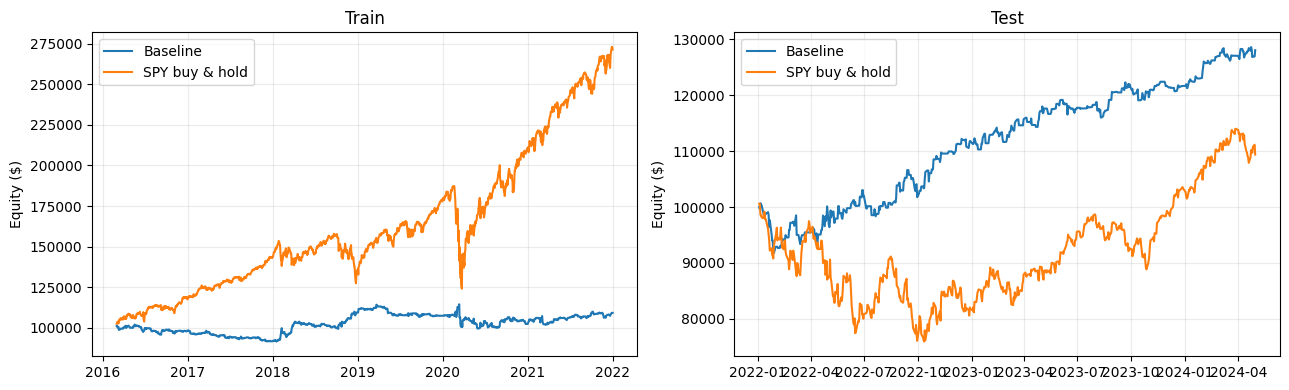

In [21]:
# Restart the plotted equity at the same capital for each evaluation split.
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, split in zip(axes, ["train", "test"]):
    sample = baseline_daily.loc[
        baseline_daily["split"].eq(split)
    ]

    for name, column in [
        ("Baseline", "strategy_return"),
        ("SPY buy & hold", "buy_hold_return"),
    ]:
        equity_curve = (
            INITIAL_CASH * (1 + sample[column]).cumprod()
        )
        ax.plot(sample.index, equity_curve, label=name)

    ax.set_title(split.capitalize())
    ax.set_ylabel("Equity ($)")
    ax.grid(alpha=0.25)
    ax.legend()

fig.tight_layout()



### 3.6 The case study's three requested metrics

Display Sharpe, annualized return and annualized volatility side by side for train and test. Return/volatility bars use percentage units; Sharpe is unitless. A higher return caused by greater exposure should be evaluated together with volatility and drawdown.

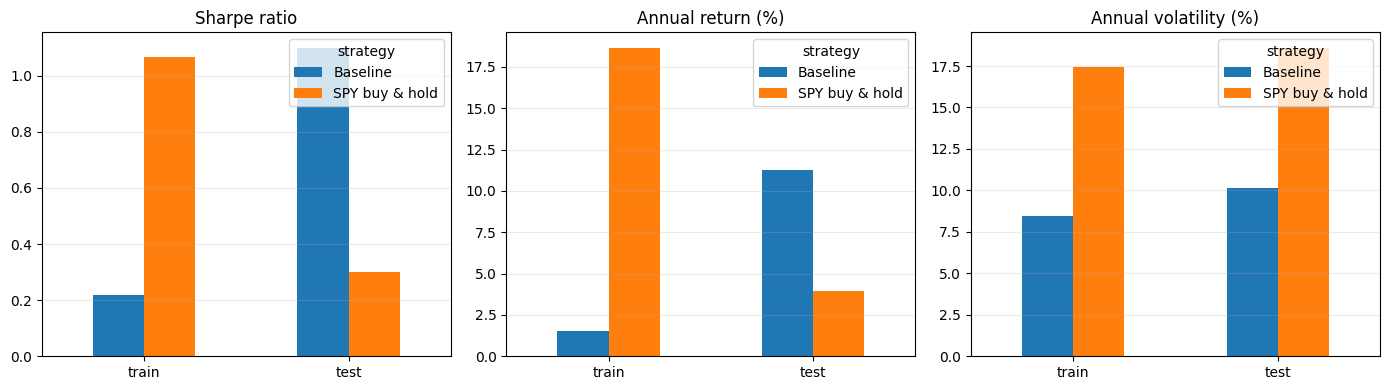

In [22]:
# Compare Sharpe ratio, annualized return, and annualized volatility.
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, metric, label, scale in [
    (axes[0], "sharpe", "Sharpe ratio", 1),
    (axes[1], "annual_return", "Annual return (%)", 100),
    (axes[2], "annual_volatility", "Annual volatility (%)", 100),
]:
    comparison = (
        performance[metric]
        .unstack("strategy")
        .reindex(["train", "test"])
        * scale
    )

    comparison.plot.bar(ax=ax, rot=0)
    ax.set_title(label)
    ax.set_xlabel("")
    ax.grid(axis="y", alpha=0.25)

fig.tight_layout()
plt.show()

## 4. Paper strategy B: current band + VWAP
### 4.1 Align the session VWAP to completed signal bars

Merge the saved `vwap_paper` series using **bar-end timestamps**, not its original start timestamps. The information available at decision time $\tau$ is the cumulative VWAP through the same completed bar. The join is one-to-one, and regular-session VWAP resets each day.

All other features, decision times, initial capital and cost assumptions remain common to the strategy-A comparison.

In [23]:
from pathlib import Path
import numpy as np
import pandas as pd

# Run this in the same notebook as the previous backtest.
required = [
    "minute_features", "calendar", "daily", "DATA_DIR",
    "INITIAL_CASH", "COMMISSION_PER_SHARE", "SLIPPAGE_PER_SHARE",
    "performance_metrics",
]
missing = [name for name in required if name not in globals()]

if missing:
    raise RuntimeError(
        "Run the previous cells first: " + ", ".join(missing)
    )

# The downloader already computed a cumulative HLC3-based session VWAP.
vwap_source = pd.read_csv(
    Path(DATA_DIR) / "SPY_1min.csv",
    usecols=["timestamp", "vwap_paper"],
)

vwap_source["bar_end_ny"] = (
    pd.to_datetime(vwap_source["timestamp"], utc=True)
    + pd.Timedelta(minutes=1)
).dt.tz_convert("America/New_York")

features_vwap = minute_features.drop(
    columns=["vwap"], errors="ignore"
).copy()

features_vwap["bar_end_ny"] = pd.to_datetime(
    features_vwap["bar_end_ny"], utc=True
).dt.tz_convert("America/New_York")

features_vwap = features_vwap.merge(
    vwap_source[["bar_end_ny", "vwap_paper"]].rename(
        columns={"vwap_paper": "vwap"}
    ),
    on="bar_end_ny",
    how="left",
    validate="one_to_one",
)




### 4.2 Tighter trailing stops and explicit flat states

**Paper, p. 13:** replace the opposite-side stop with a stop on the current band and VWAP:

$$B^{\mathrm{long}}_{t,\tau}=\max(U_{t,\tau},\widetilde{\mathrm{VWAP}}_{t,\tau}),\qquad
B^{\mathrm{short}}_{t,\tau}=\min(L_{t,\tau},\widetilde{\mathrm{VWAP}}_{t,\tau}).$$

The implemented target state at every half-hour decision is

$$s_{t,\tau}=\begin{cases}
1,&P_{t,\tau}>U_{t,\tau}\ \text{and}\ P_{t,\tau}>\widetilde{\mathrm{VWAP}}_{t,\tau},\\
-1,&P_{t,\tau}<L_{t,\tau}\ \text{and}\ P_{t,\tau}<\widetilde{\mathrm{VWAP}}_{t,\tau},\\
0,&\text{otherwise}.
\end{cases}$$

This implements the current-band/VWAP exit idea and also requires a **new entry** to be on the corresponding side of VWAP. That entry convention and the HLC3 VWAP proxy should be stated explicitly when discussing fidelity to the article. Equality selects flat; the implementation uses strict inequalities. The stop reference changes with current features and is not a separately ratcheted monotonic stop.

Because positions start and finish flat, signed order cash flows yield daily PnL:

$$\Pi_t^{\mathrm{gross}}=-\sum_j\Delta q_{t,j}P^{\mathrm{reference}}_{t,j},\quad
\Pi_t^{\mathrm{net}}=\Pi_t^{\mathrm{gross}}-(c+\delta)\sum_j|\Delta q_{t,j}|,\quad
E_t=E_{t-1}+\Pi_t^{\mathrm{net}}.$$

For `stop_mode='opposite'`, forward filling retains the previous side within the bands. For `band_vwap`, the explicit zero state exits when either condition is lost. Both branches liquidate at the scheduled close and charge reversal turnover correctly.

In [24]:
def backtest_momentum(
    features,
    trading_calendar,
    stop_mode="opposite",
    initial_cash=100_000.0,
    commission=0.0035,
    slippage=0.001,
):
    """Compare stop rules using the same event ledger and sizing."""
    if stop_mode not in ["opposite", "band_vwap"]:
        raise ValueError("Unknown stop_mode.")

    if initial_cash <= 0 or commission < 0 or slippage < 0:
        raise ValueError("Invalid cash or cost assumptions.")

    if stop_mode == "band_vwap" and "vwap" not in features:
        raise ValueError("Merge VWAP into the features first.")

    data = features.copy()
    data["date"] = pd.to_datetime(data["date"]).dt.normalize()

    data["bar_end_ny"] = pd.to_datetime(
        data["bar_end_ny"], utc=True
    ).dt.tz_convert("America/New_York")

    data = data.sort_values(["date", "bar_end_ny"])

    if data["bar_end_ny"].duplicated().any():
        raise ValueError("Duplicate minute bars.")

    grouped = data.groupby("date", sort=False)

    sessions = trading_calendar.copy()
    sessions["date"] = pd.to_datetime(
        sessions["date"]
    ).dt.normalize()

    for column in ["market_open", "market_close"]:
        sessions[column] = pd.to_datetime(
            sessions[column], utc=True
        )

    sessions = sessions.loc[
        sessions["split"].isin(["train", "test"])
    ].sort_values("date")

    if sessions.empty or sessions["date"].duplicated().any():
        raise ValueError("Missing or duplicate evaluation sessions.")

    equity = float(initial_cash)
    results, orders = [], []

    for session in sessions.itertuples(index=False):
        if equity <= 0:
            raise ValueError("The portfolio has exhausted its equity.")

        start = equity
        result = {
            "date": session.date,
            "split": session.split,
            "equity_start": start,
            "equity_end": start,
            "gross_pnl": 0.0,
            "commission": 0.0,
            "slippage": 0.0,
            "net_pnl": 0.0,
            "strategy_return": 0.0,
            "orders": 0,
            "missing_signal_points": 0,
            "status": "missing_session",
        }

        if session.date not in grouped.indices:
            results.append(result)
            continue

        day = grouped.get_group(session.date).copy()
        expected = int(session.expected_minutes)

        expected_ends = pd.date_range(
            session.market_open + pd.Timedelta(minutes=1),
            periods=expected,
            freq="min",
        )
        actual_ends = pd.DatetimeIndex(
            day["bar_end_ny"]
        ).tz_convert("UTC")

        prices = day[["open", "close"]].to_numpy(dtype=float)

        complete = (
            len(day) == expected
            and (actual_ends == expected_ends).all()
            and expected_ends[-1] == session.market_close
            and np.isfinite(prices).all()
            and (prices > 0).all()
        )

        if not complete:
            result["status"] = "incomplete_prices"
            results.append(result)
            continue

        # Both models use the same daily share-sizing formula.
        quantity = int(
            np.floor(start / float(day["open"].iloc[0]))
        )

        # Execution follows the completed signal bar.
        day["next_open"] = day["open"].shift(-1)

        ticks = day.loc[
            day["bar_end_ny"].dt.minute.isin([0, 30])
            & day["bar_end_ny"].lt(session.market_close)
        ]

        valid_bounds = (
            np.isfinite(ticks["upper_bound"])
            & np.isfinite(ticks["lower_bound"])
            & ticks["upper_bound"].ge(ticks["lower_bound"])
        )

        if stop_mode == "opposite":
            # NaN means retain the previous position inside the bands.
            eligible = valid_bounds
            direction = pd.Series(np.nan, index=ticks.index)
            reasons = pd.Series("hold", index=ticks.index)

            direction.loc[~eligible] = 0
            reasons.loc[~eligible] = "missing_bounds"

            long_signal = (
                eligible
                & ticks["close"].gt(ticks["upper_bound"])
            )
            short_signal = (
                eligible
                & ticks["close"].lt(ticks["lower_bound"])
            )

        else:
            # Each decision explicitly selects long, short, or flat.
            valid_vwap = (
                np.isfinite(ticks["vwap"])
                & ticks["vwap"].gt(0)
            )
            eligible = valid_bounds & valid_vwap

            direction = pd.Series(0.0, index=ticks.index)
            reasons = pd.Series(
                "vwap_or_band_exit", index=ticks.index
            )

            reasons.loc[~valid_bounds] = "missing_bounds"
            reasons.loc[
                valid_bounds & ~valid_vwap
            ] = "missing_vwap"

            long_signal = (
                eligible
                & ticks["close"].gt(ticks["upper_bound"])
                & ticks["close"].gt(ticks["vwap"])
            )
            short_signal = (
                eligible
                & ticks["close"].lt(ticks["lower_bound"])
                & ticks["close"].lt(ticks["vwap"])
            )

        direction.loc[long_signal] = 1
        direction.loc[short_signal] = -1
        reasons.loc[long_signal] = "upper_breakout"
        reasons.loc[short_signal] = "lower_breakout"

        # Carry positions only forward within the same trading day.
        direction = direction.ffill().fillna(0)

        # Append the preplanned close-of-session liquidation.
        targets = np.r_[
            direction.to_numpy() * quantity, 0
        ].astype(int)

        changes = np.diff(np.r_[0, targets])

        references = np.r_[
            ticks["next_open"].to_numpy(dtype=float),
            float(day["close"].iloc[-1]),
        ]
        times = ticks["bar_end_ny"].tolist() + [
            session.market_close.tz_convert("America/New_York")
        ]
        reason_list = reasons.tolist() + ["market_close"]

        # A reversal trades twice the position size.
        commissions = np.abs(changes) * commission
        slippages = np.abs(changes) * slippage

        # Positions start and finish flat, so net cash flows equal PnL.
        gross = -float(np.dot(changes, references))
        fees = float(commissions.sum())
        slip = float(slippages.sum())
        net = gross - fees - slip
        equity = start + net

        for i in np.flatnonzero(changes):
            change = int(changes[i])

            orders.append({
                "date": session.date,
                "split": session.split,
                "execution_time": times[i],
                "side": "buy" if change > 0 else "sell",
                "shares": abs(change),
                "reference_price": references[i],
                "fill_price": (
                    references[i] + np.sign(change) * slippage
                ),
                "commission": commissions[i],
                "slippage": slippages[i],
                "position_after": targets[i],
                "reason": reason_list[i],
            })

        missing_points = int((~eligible).sum())

        result.update({
            "equity_end": equity,
            "gross_pnl": gross,
            "commission": fees,
            "slippage": slip,
            "net_pnl": net,
            "strategy_return": net / start,
            "orders": int(np.count_nonzero(changes)),
            "missing_signal_points": missing_points,
            "status": (
                "partial_bounds" if missing_points else "complete"
            ),
        })

        results.append(result)

    order_columns = [
        "date", "split", "execution_time", "side", "shares",
        "reference_price", "fill_price", "commission", "slippage",
        "position_after", "reason",
    ]

    return (
        pd.DataFrame(results).set_index("date"),
        pd.DataFrame(orders, columns=order_columns),
    )

### 4.3 Reproduce the base engine before comparing exits

First verify that the refactored `opposite` branch reproduces the earlier baseline returns. Then compare opposite-band and band/VWAP exits under the same fixed $1\times$ share budget. This check separates the economic effect of the stop from an accidental change in accounting or execution.

The saved test-period result improves from Sharpe **1.100 → 1.740** and maximum drawdown **−8.93% → −4.67%**. Report the accompanying order counts and costs; a tighter stop can also increase turnover. These sample-specific outputs should not be substituted for Table 2 of the paper.

In [25]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Reuse the previous cash, commission, and slippage assumptions.
settings = {
    "initial_cash": INITIAL_CASH,
    "commission": COMMISSION_PER_SHARE,
    "slippage": SLIPPAGE_PER_SHARE,
}

opposite_daily, opposite_orders = backtest_momentum(
    features_vwap,
    calendar,
    stop_mode="opposite",
    **settings,
)

vwap_daily, vwap_orders = backtest_momentum(
    features_vwap,
    calendar,
    stop_mode="band_vwap",
    **settings,
)

# Verify that refactoring has preserved the previous baseline.
if "baseline_daily" in globals():
    if not baseline_daily.index.equals(opposite_daily.index):
        raise ValueError(
            "The evaluation dates differ from the previous baseline."
        )

    if not np.allclose(
        baseline_daily["strategy_return"],
        opposite_daily["strategy_return"],
        rtol=1e-8,
        atol=1e-10,
    ):
        raise ValueError(
            "Baseline changed; check data and cost settings."
        )

benchmark = daily[["date", "return_adjusted"]].copy()
benchmark["date"] = pd.to_datetime(
    benchmark["date"]
).dt.normalize()

if benchmark["date"].duplicated().any():
    raise ValueError("Duplicate benchmark dates.")

comparison = pd.DataFrame({
    "split": opposite_daily["split"],
    "Opposite band": opposite_daily["strategy_return"],
    "Band + VWAP": vwap_daily["strategy_return"],
})

comparison["SPY buy & hold"] = comparison.index.map(
    benchmark.set_index("date")["return_adjusted"]
)

model_names = [
    "Opposite band",
    "Band + VWAP",
    "SPY buy & hold",
]

records = []

for split in ["train", "test"]:
    sample = comparison.loc[comparison["split"].eq(split)]

    if sample.empty:
        continue

    for model in model_names:
        records.append({
            "split": split,
            "strategy": model,
            **performance_metrics(sample[model]),
        })

performance_vwap = pd.DataFrame(records).set_index(
    ["split", "strategy"]
)

formatters = {
    column: lambda value: f"{value:.2%}"
    for column in [
        "total_return",
        "annual_return",
        "annual_volatility",
        "max_drawdown",
    ]
}
formatters["sharpe"] = lambda value: f"{value:.3f}"

print(performance_vwap.to_string(formatters=formatters))

for name, result in [
    ("Opposite band", opposite_daily),
    ("Band + VWAP", vwap_daily),
]:
    print("\n" + name + " - orders and costs:")
    print(
        result.groupby("split")[
            ["orders", "commission", "slippage"]
        ].sum().round(2)
    )

    print("Session status:")
    print(pd.crosstab(result["split"], result["status"]))



                      days total_return annual_return annual_volatility sharpe max_drawdown
split strategy                                                                             
train Opposite band   1472        9.17%         1.51%             8.48%  0.220      -13.02%
      Band + VWAP     1472       23.64%         3.70%             6.52%  0.590      -12.41%
      SPY buy & hold  1472      171.55%        18.65%            17.46%  1.068      -33.79%
test  Opposite band    584       28.05%        11.26%            10.17%  1.100       -8.93%
      Band + VWAP      584       32.63%        12.96%             7.15%  1.740       -4.67%
      SPY buy & hold   584        9.37%         3.94%            18.60%  0.301      -24.50%

Opposite band - orders and costs:
       orders  commission  slippage
split                              
test      751      765.29    218.65
train    1770     2297.69    656.48
Session status:
status  complete  incomplete_prices  partial_bounds
split            

### 4.4 Compare equity and risk-adjusted performance

Blue denotes the opposite-band strategy, green the band/VWAP version, and orange passive SPY. The plots and metric bars provide the same comparison in cumulative wealth and in Sharpe/return/volatility. This is the paper's second refinement stage, before introducing leverage.

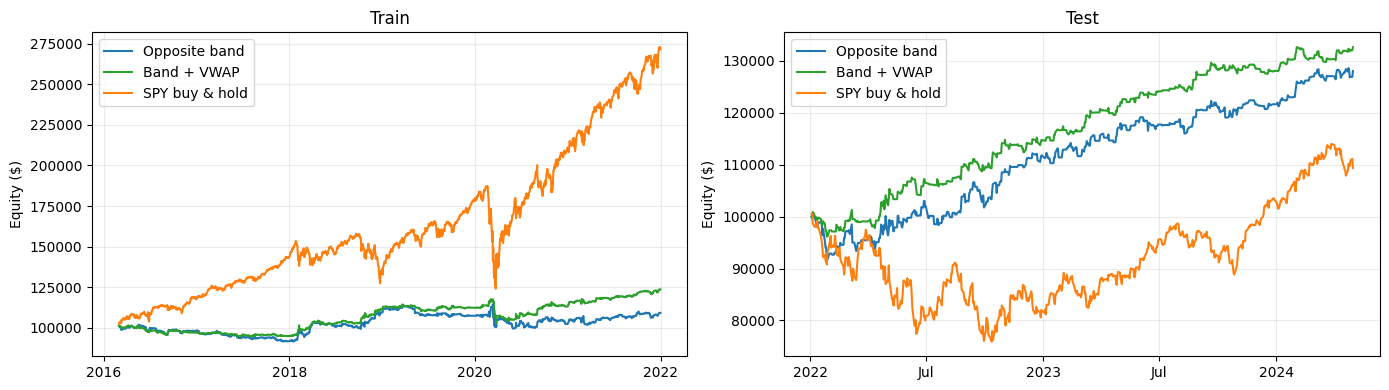

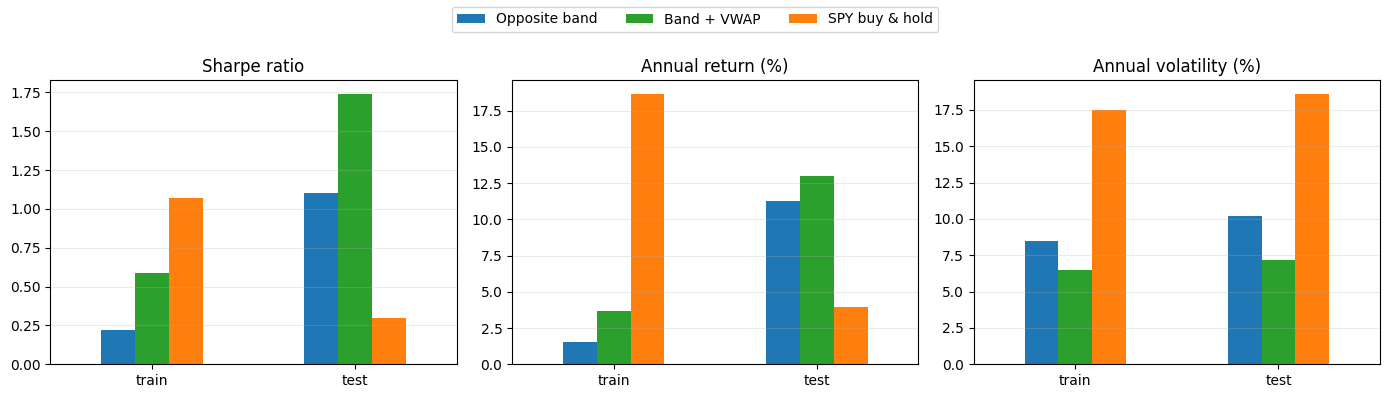

In [26]:
# Preserve the original colors and add green for the VWAP version.
colors = {
    "Opposite band": "tab:blue",
    "Band + VWAP": "tab:green",
    "SPY buy & hold": "tab:orange",
}

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, split in zip(axes, ["train", "test"]):
    sample = comparison.loc[comparison["split"].eq(split)]

    for model in model_names:
        curve = INITIAL_CASH * (1 + sample[model]).cumprod()

        ax.plot(
            sample.index,
            curve,
            label=model,
            color=colors[model],
        )

    locator = mdates.AutoDateLocator(minticks=3, maxticks=6)
    ax.xaxis.set_major_locator(locator)
    ax.xaxis.set_major_formatter(
        mdates.ConciseDateFormatter(locator)
    )

    ax.set_title(split.capitalize())
    ax.set_ylabel("Equity ($)")
    ax.grid(alpha=0.25)
    ax.legend()

fig.tight_layout()

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, metric, title, scale in [
    (axes[0], "sharpe", "Sharpe ratio", 1),
    (axes[1], "annual_return", "Annual return (%)", 100),
    (axes[2], "annual_volatility", "Annual volatility (%)", 100),
]:
    values = (
        performance_vwap[metric]
        .unstack("strategy")
        .reindex(
            index=["train", "test"],
            columns=model_names,
        )
        * scale
    )

    values.plot.bar(
        ax=ax,
        rot=0,
        legend=False,
        color=[colors[model] for model in model_names],
    )

    ax.set_title(title)
    ax.set_xlabel("")
    ax.grid(axis="y", alpha=0.25)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3)
fig.tight_layout(rect=[0, 0, 1, 0.9])

plt.show()

## 5. Paper strategy C: daily volatility sizing
### 5.1 A second, different volatility estimate

**Paper, p. 15:** estimate SPY's daily close-to-close risk from the prior 14 completed sessions:

$$\mu_t=\frac{1}{14}\sum_{i=1}^{14}r_{t-i}^{\mathrm{raw}},\qquad
\sigma_t^{\mathrm{daily}}=\sqrt{\frac{1}{13}\sum_{i=1}^{14}(r_{t-i}^{\mathrm{raw}}-\mu_t)^2}.$$

`spy_returns.shift(1).rolling(14).std(ddof=1)` implements this estimate. It is a **sample standard deviation of daily signed returns**, unlike $\sigma^{\mathrm{noise}}$, which is a mean absolute intraday move. Both are causal, but they answer different questions: signal threshold versus share size.

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

required = [
    "backtest_momentum", "features_vwap", "calendar", "daily",
    "vwap_daily", "comparison", "performance_metrics",
    "INITIAL_CASH", "COMMISSION_PER_SHARE", "SLIPPAGE_PER_SHARE",
]
missing = [name for name in required if name not in globals()]
if missing:
    raise RuntimeError(
        "Run the previous VWAP cells first. Missing: " + ", ".join(missing)
    )

VOL_TARGET_DAILY = 0.02
MAX_LEVERAGE = 4.0
VOL_LOOKBACK = 14

# Keep the full calendar, including warmup sessions and missing-data days.
cal_sizing = calendar.copy()
cal_sizing["date"] = pd.to_datetime(cal_sizing["date"]).dt.normalize()
cal_sizing = cal_sizing.sort_values("date").reset_index(drop=True)
session_dates = pd.DatetimeIndex(cal_sizing["date"])
if session_dates.has_duplicates:
    raise ValueError("Duplicate calendar sessions.")

daily_sizing = daily.copy()
if "date" in daily_sizing.columns:
    daily_sizing["date"] = pd.to_datetime(daily_sizing["date"]).dt.normalize()
    daily_sizing = daily_sizing.set_index("date")
else:
    daily_sizing.index = pd.to_datetime(daily_sizing.index).normalize()
if daily_sizing.index.has_duplicates:
    raise ValueError("Duplicate daily observations.")

# Use raw close-to-close SPY returns for the sizing volatility estimate.
# Shift first: today's return must never affect today's position size.
spy_returns = daily_sizing["return_raw"].reindex(session_dates)
sigma_daily = (
    spy_returns.shift(1)
    .rolling(VOL_LOOKBACK, min_periods=VOL_LOOKBACK)
    .std(ddof=1)
)
sigma_daily.index.name = "date"




### 5.2 Target daily risk and separate notional from equity

Use the paper's $\sigma_{\mathrm{target}}=2\%$ and leverage cap 4:

$$\ell_t=\min\left(4,\frac{0.02}{\sigma_t^{\mathrm{daily}}}\right),\qquad
Q_t=\left\lfloor\frac{E_{t-1}\ell_t}{O_t}\right\rfloor.$$

For daily risk 4%, 1%, or 0.25%, the planned leverage is respectively $0.5$, $2$, or capped at $4$. Missing/zero volatility gives cash as an implementation fallback.

The engine receives the **notional budget** $B_t=E_{t-1}\ell_t$ to calculate shares, but the actual equity update remains

$$E_t=E_{t-1}+\Pi_t^{\mathrm{net}},\qquad r_t=\frac{\Pi_t^{\mathrm{net}}}{E_{t-1}}.$$

Do not add the notional budget to portfolio equity or compound it as capital. The cap controls opening-price-based sizing; it is not a continuously enforced intraday exposure cap. The 2% target is SPY exposure sizing, not a guarantee that realized strategy volatility equals 2% daily. Financing, borrow costs and size-dependent impact are not included in this implementation.

In [28]:
def backtest_with_sizing(
    features,
    trading_calendar,
    volatility,
    sizing="vol_target",
    initial_cash=100_000.0,
    commission=0.0035,
    slippage=0.001,
    target_daily=0.02,
    max_leverage=4.0,
):
    """Reuse the existing execution engine with a daily notional budget."""
    if sizing not in {"fixed", "vol_target"}:
        raise ValueError("sizing must be 'fixed' or 'vol_target'.")
    if initial_cash <= 0 or target_daily <= 0 or max_leverage <= 0:
        raise ValueError("Cash, target volatility and leverage cap must be positive.")
    if commission < 0 or slippage < 0:
        raise ValueError("Trading costs must be nonnegative.")

    cal = trading_calendar.copy()
    cal["date"] = pd.to_datetime(cal["date"]).dt.normalize()
    cal = cal.sort_values("date")
    if cal["date"].duplicated().any():
        raise ValueError("Duplicate calendar sessions.")
    cal = cal[cal["split"].isin(["train", "test"])]

    bars = features.copy()
    bars["date"] = pd.to_datetime(bars["date"]).dt.normalize()
    groups = {
        date: group
        for date, group in bars.groupby("date", sort=False)
    }

    equity = float(initial_cash)
    daily_rows = []
    order_frames = []

    for _, session in cal.iterrows():
        date = session["date"]
        equity_start = equity
        if equity_start <= 0:
            raise RuntimeError(
                f"Nonpositive portfolio equity before {date.date()}."
            )

        sigma = float(volatility.get(date, np.nan))
        valid_sigma = np.isfinite(sigma) and sigma > 0
        leverage = (
            1.0 if sizing == "fixed"
            else min(max_leverage, target_daily / sigma) if valid_sigma
            else 0.0
        )
        notional_budget = equity_start * leverage

        if leverage == 0.0:
            # Preserve the session in the return series while holding cash.
            row = {
                "split": session["split"],
                "gross_pnl": 0.0,
                "commission": 0.0,
                "slippage": 0.0,
                "net_pnl": 0.0,
                "orders": 0,
                "missing_signal_points": 0,
                "status": "missing_volatility",
            }
        else:
            day_bars = groups.get(date, bars.iloc[:0])
            one_calendar = session.to_frame().T

            # The engine sizes shares as floor(initial_cash / day_open).
            # Supply the notional budget, then transfer only dollar PnL
            # into the actual portfolio equity. Do not compound the budget.
            day_result, day_orders = backtest_momentum(
                day_bars,
                one_calendar,
                stop_mode="band_vwap",
                initial_cash=notional_budget,
                commission=commission,
                slippage=slippage,
            )
            if len(day_result) != 1:
                raise RuntimeError(
                    f"Expected one daily result for {date.date()}."
                )

            row = day_result.iloc[0].to_dict()
            row.pop("date", None)

            if not day_orders.empty:
                day_orders = day_orders.copy()
                day_orders["leverage"] = leverage
                day_orders["portfolio_equity_start"] = equity_start
                order_frames.append(day_orders)

        equity = equity_start + float(row["net_pnl"])
        if not np.isfinite(equity) or equity <= 0:
            raise RuntimeError(f"Portfolio exhausted on {date.date()}.")

        row.update({
            "date": date,
            "equity_start": equity_start,
            "equity_end": equity,
            "strategy_return": float(row["net_pnl"]) / equity_start,
            "sigma_daily_lagged": sigma,
            "leverage": leverage,
            "notional_budget": notional_budget,
        })
        daily_rows.append(row)

    result = pd.DataFrame(daily_rows).set_index("date").sort_index()
    orders = (
        pd.concat(order_frames, ignore_index=True)
        if order_frames else pd.DataFrame()
    )
    return result, orders




### 5.3 Verify the fixed-size special case

Set `sizing='fixed'`, so $\ell_t=1$. The wrapper must reproduce the existing band/VWAP engine's equity, gross PnL, commissions, slippage, net PnL and daily returns. The assertions below are existing regression checks, retained from the supplied notebook.

This confirms that the new wrapper changes the sizing budget while preserving the underlying signal and transaction-cost model.

In [29]:
settings = {
    "initial_cash": INITIAL_CASH,
    "commission": COMMISSION_PER_SHARE,
    "slippage": SLIPPAGE_PER_SHARE,
    "target_daily": VOL_TARGET_DAILY,
    "max_leverage": MAX_LEVERAGE,
}

# A 1x run must reproduce the previous fixed-size VWAP strategy.
fixed_check, _ = backtest_with_sizing(
    features_vwap,
    cal_sizing,
    sigma_daily,
    sizing="fixed",
    **settings,
)

previous_vwap = vwap_daily.copy()
previous_vwap.index = pd.to_datetime(previous_vwap.index).normalize()
previous_vwap = previous_vwap.sort_index()

if not fixed_check.index.equals(previous_vwap.index):
    raise AssertionError("The 1x check uses different trading sessions.")

for column in [
    "equity_start", "equity_end", "gross_pnl",
    "commission", "slippage", "net_pnl", "strategy_return",
]:
    np.testing.assert_allclose(
        fixed_check[column].to_numpy(dtype=float),
        previous_vwap[column].to_numpy(dtype=float),
        rtol=1e-8,
        atol=1e-8,
        err_msg=f"The 1x check failed for {column}.",
    )

print("1x regression check passed.")



1x regression check passed.


### 5.4 Run the complete paper-inspired specification

Append volatility sizing to the fixed-size stop comparison. The original three stages and passive SPY now share a common daily calendar.

**Saved local result:** the volatility-sized version has test CAGR **30.04%**, annualized volatility **13.49%**, Sharpe **2.015** and maximum drawdown **−9.95%**. Its fixed-size VWAP predecessor has test Sharpe **1.740** and drawdown **−4.67%**: adding exposure raises both return and downside risk.

For context only, the paper's Table 3 reports full-sample annual returns/Sharpe of **6.2% / 0.61**, **9.7% / 1.24** and **19.6% / 1.33** for the three stages. The different source data, dates, VWAP and execution conventions prevent a direct numerical replication claim.

In [30]:
vol_target_daily, vol_target_orders = backtest_with_sizing(
    features_vwap,
    cal_sizing,
    sigma_daily,
    sizing="vol_target",
    **settings,
)

# Add the dynamic strategy without changing the existing comparison series.
comparison_dynamic = comparison.copy()
comparison_dynamic.index = pd.to_datetime(
    comparison_dynamic.index
).normalize()
comparison_dynamic = comparison_dynamic.sort_index()

if not comparison_dynamic.index.equals(vol_target_daily.index):
    raise AssertionError("Comparison series use different trading sessions.")

comparison_dynamic["Band + VWAP + Vol target"] = (
    vol_target_daily["strategy_return"]
)

models = [
    "Opposite band",
    "Band + VWAP",
    "Band + VWAP + Vol target",
    "SPY buy & hold",
]

rows = []
for split in ["train", "test"]:
    sample = comparison_dynamic[
        comparison_dynamic["split"] == split
    ]
    for model in models:
        metrics = performance_metrics(sample[model])
        rows.append({
            "split": split,
            "strategy": model,
            **metrics,
        })

performance_dynamic = pd.DataFrame(rows).set_index(
    ["split", "strategy"]
)

formatted = performance_dynamic.copy()
for column in [
    "total_return", "annual_return",
    "annual_volatility", "max_drawdown",
]:
    formatted[column] = formatted[column].map(
        lambda x: f"{x:.2%}"
    )

formatted["sharpe"] = formatted["sharpe"].map(
    lambda x: f"{x:.3f}"
)

print("\nPerformance comparison:")
print(formatted.to_string())

print("\nDynamic strategy: leverage and costs:")
summary = vol_target_daily.groupby("split").agg(
    average_leverage=("leverage", "mean"),
    maximum_leverage=("leverage", "max"),
    orders=("orders", "sum"),
    commission=("commission", "sum"),
    slippage=("slippage", "sum"),
)
print(summary.round(3).to_string())

print("\nDynamic strategy: data status:")
print(pd.crosstab(
    vol_target_daily["split"],
    vol_target_daily["status"],
))




Performance comparison:
                                days total_return annual_return annual_volatility sharpe max_drawdown
split strategy                                                                                       
train Opposite band             1472        9.17%         1.51%             8.48%  0.220      -13.02%
      Band + VWAP               1472       23.64%         3.70%             6.52%  0.590      -12.41%
      Band + VWAP + Vol target  1472       92.72%        11.89%            14.48%  0.847      -25.72%
      SPY buy & hold            1472      171.55%        18.65%            17.46%  1.068      -33.79%
test  Opposite band              584       28.05%        11.26%            10.17%  1.100       -8.93%
      Band + VWAP                584       32.63%        12.96%             7.15%  1.740       -4.67%
      Band + VWAP + Vol target   584       83.80%        30.04%            13.49%  2.015       -9.95%
      SPY buy & hold             584        9.37%        

### 5.5 Show all three paper stages together

The purple line adds volatility sizing to the green VWAP strategy; blue retains the opposite-band baseline and orange the passive benchmark. Train and test are displayed separately with the same initial plotted equity. The bars repeat the case study's required Sharpe, annualized return and volatility comparison.

This is the natural baseline for the following original experiments: **band + VWAP + volatility sizing**.

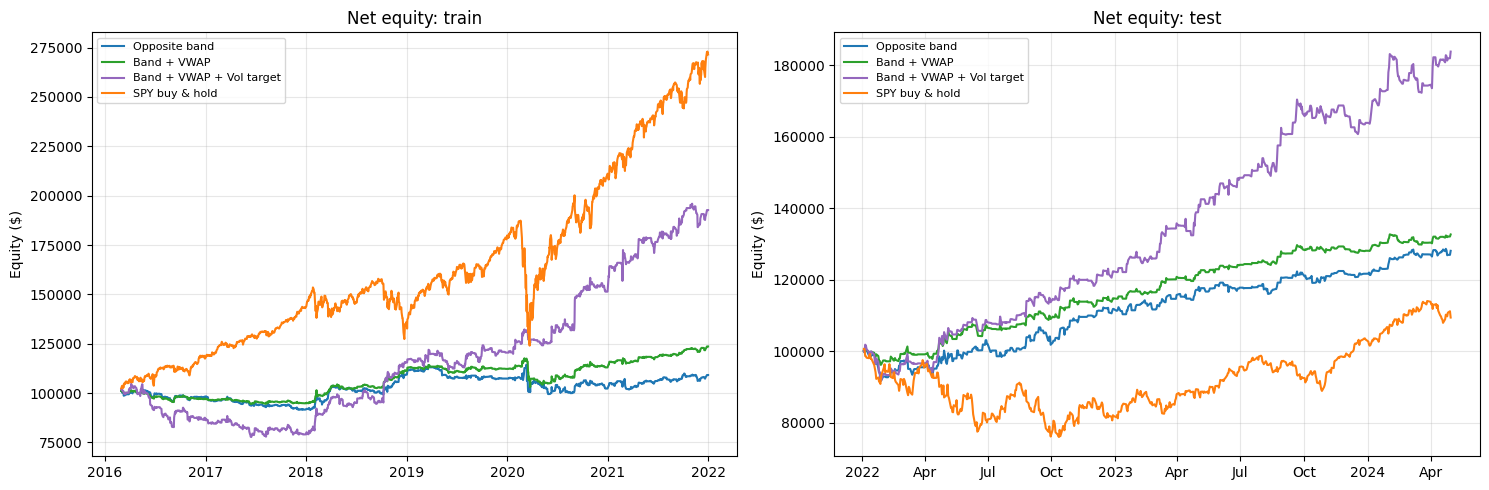

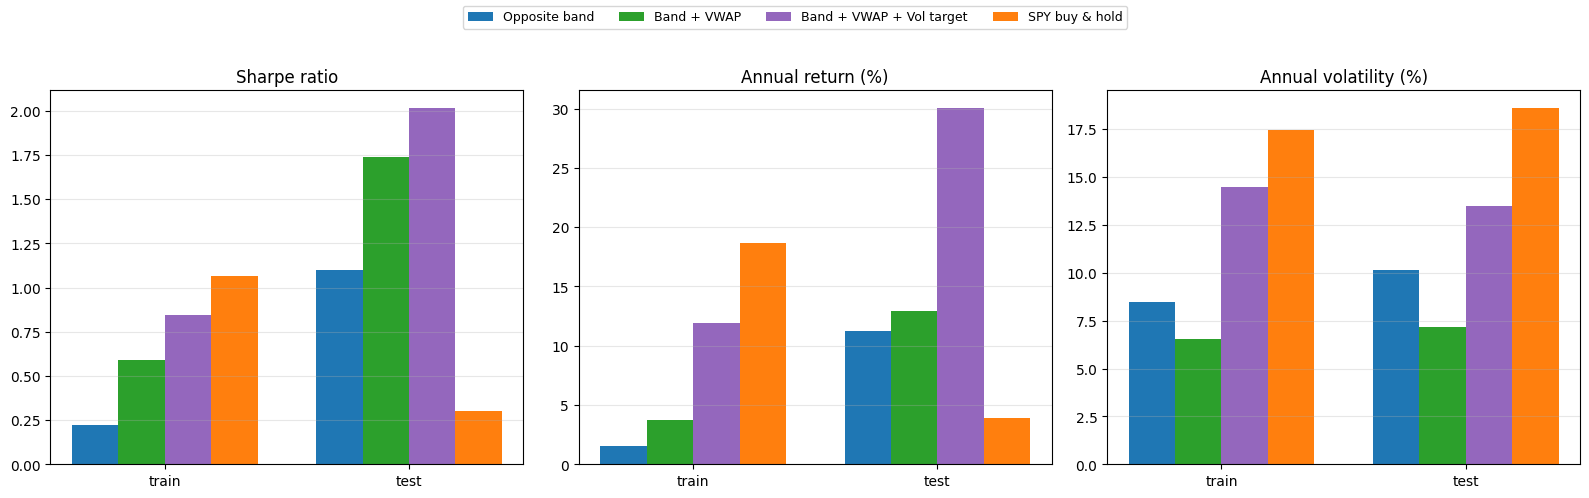

In [31]:
# Reset only the displayed equity to initial cash for each split.
colors = ["tab:blue", "tab:green", "tab:purple", "tab:orange"]
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, split in zip(axes, ["train", "test"]):
    sample = comparison_dynamic[
        comparison_dynamic["split"] == split
    ]
    for model, color in zip(models, colors):
        curve = INITIAL_CASH * (1.0 + sample[model]).cumprod()
        ax.plot(
            sample.index,
            curve,
            label=model,
            color=color,
        )

    locator = mdates.AutoDateLocator()
    ax.xaxis.set_major_locator(locator)
    ax.xaxis.set_major_formatter(
        mdates.ConciseDateFormatter(locator)
    )
    ax.set_title(f"Net equity: {split}")
    ax.set_ylabel("Equity ($)")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)

fig.tight_layout()
plt.show()

# Compare the three metrics requested by the case study.
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metric_specs = [
    ("sharpe", "Sharpe ratio", 1.0),
    ("annual_return", "Annual return (%)", 100.0),
    ("annual_volatility", "Annual volatility (%)", 100.0),
]
width = 0.19
x = np.arange(2)

for ax, (metric, title, multiplier) in zip(axes, metric_specs):
    for i, (model, color) in enumerate(zip(models, colors)):
        values = [
            performance_dynamic.loc[(split, model), metric] * multiplier
            for split in ["train", "test"]
        ]
        ax.bar(
            x + (i - 1.5) * width,
            values,
            width,
            label=model,
            color=color,
        )

    ax.set_xticks(x, ["train", "test"])
    ax.set_title(title)
    ax.grid(axis="y", alpha=0.3)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=4,
    fontsize=9,
)
fig.tight_layout(rect=(0, 0, 1, 0.9))
plt.show()

## 6. Original research protocol

The extensions ask two different questions: **which breakout should be entered?** (ER, TCN/Ridge) and **how much risk should be taken that day?** (LSTM). The underlying band/VWAP direction, end-of-day liquidation, dynamic sizing baseline, proportional costs and chronological sample are retained.

Preprocessing and model weights are fitted on development data. The 2021 validation period selects the operational choice; the chosen model/threshold is then frozen for historical-test evaluation. Each extension includes a no-change special-case check. A constant exposure control is needed to distinguish genuine timing skill from simply taking less risk.

An original variation need not outperform to be informative. The objective is a clearly defined mechanism, a fair backtest and an honest explanation of what the evidence supports. Repeated experiments still create research-selection risk even when each individual script avoids look-ahead.

## 7. Extension A: efficiency-ratio entry filter
### 7.1 Hypothesis and causal 30-minute score

**Extension:** a breakout reached by a relatively direct price path may be more persistent than one reached after substantial back-and-forth movement. At a completed decision bar, define

$$\mathrm{ER}_{t,\tau}=\frac{|P_{t,\tau}-P_{t,\tau-30}|}{\sum_{k=\tau-29}^{\tau}|P_{t,k}-P_{t,k-1}|}\in[0,1].$$

The day-open price precedes the first completed minute close. A zero denominator receives score zero. Cache the original directions and next-open references, and calculate ER using exactly 30 completed minute changes. Nothing from after the decision enters the score.

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

required = [
    "features_vwap", "cal_sizing", "sigma_daily",
    "vol_target_daily", "comparison_dynamic", "performance_metrics",
    "INITIAL_CASH", "COMMISSION_PER_SHARE", "SLIPPAGE_PER_SHARE",
    "VOL_TARGET_DAILY", "MAX_LEVERAGE",
]
missing = [name for name in required if name not in globals()]
if missing:
    raise RuntimeError("Run previous cells first: " + ", ".join(missing))

ER_WINDOW = 30
ER_THRESHOLDS = [0.0, 0.2, 0.4, 0.6]
ER_VALIDATION_START = pd.Timestamp("2021-01-01")
ER_MIN_ACTIVE_DAYS = 20


# ---------------------------------------------------------
# 1. Prepare a daily cache from the existing feature table.
# ---------------------------------------------------------

er_features = features_vwap.copy()
er_features["date"] = pd.to_datetime(
    er_features["date"]
).dt.normalize()
er_features["bar_end_ny"] = pd.to_datetime(
    er_features["bar_end_ny"], utc=True
).dt.tz_convert("America/New_York")

er_features = er_features.sort_values(["date", "bar_end_ny"])

if er_features["bar_end_ny"].duplicated().any():
    raise ValueError("Duplicate minute timestamps.")

er_calendar = cal_sizing.copy()
er_calendar["date"] = pd.to_datetime(
    er_calendar["date"]
).dt.normalize()

for col in ["market_open", "market_close"]:
    er_calendar[col] = pd.to_datetime(er_calendar[col], utc=True)

er_calendar = er_calendar[
    er_calendar["split"].isin(["train", "test"])
].sort_values("date").reset_index(drop=True)

er_groups = {
    date: group
    for date, group in er_features.groupby("date", sort=False)
}

er_cache = {}

for session in er_calendar.itertuples(index=False):
    date = session.date
    info = {
        "split": session.split,
        "status": "missing_session",
        "missing_signal_points": 0,
    }
    er_cache[date] = info

    day = er_groups.get(date)
    if day is None or day.empty:
        continue

    expected_ends = pd.date_range(
        session.market_open + pd.Timedelta(minutes=1),
        periods=int(session.expected_minutes),
        freq="min",
    )
    actual_ends = pd.DatetimeIndex(
        day["bar_end_ny"]
    ).tz_convert("UTC")

    prices = day[["open", "close"]].to_numpy(dtype=float)

    complete = (
        len(day) == len(expected_ends)
        and actual_ends.equals(expected_ends)
        and expected_ends[-1] == session.market_close
        and np.isfinite(prices).all()
        and (prices > 0).all()
    )

    if not complete:
        info["status"] = "incomplete_prices"
        continue

    opens = day["open"].to_numpy(dtype=float)
    closes = day["close"].to_numpy(dtype=float)

    # Include the day open before the first completed minute close.
    path = np.r_[opens[0], closes]

    # ER uses exactly 30 completed minute changes.
    movement = (
        pd.Series(np.abs(np.diff(path)))
        .rolling(ER_WINDOW, min_periods=ER_WINDOW)
        .sum()
        .to_numpy()
    )

    lagged_price = np.full(len(day), np.nan)
    lagged_price[ER_WINDOW - 1:] = path[
        :len(day) - ER_WINDOW + 1
    ]
    displacement = np.abs(closes - lagged_price)

    efficiency = np.divide(
        displacement,
        movement,
        out=np.full(len(day), np.nan),
        where=np.isfinite(movement) & (movement > 0),
    )
    efficiency[np.isfinite(movement) & (movement == 0)] = 0.0
    efficiency = np.clip(efficiency, 0.0, 1.0)

    # Match the existing half-hour decision schedule.
    decision_mask = (
        day["bar_end_ny"].dt.minute.isin([0, 30])
        & day["bar_end_ny"].lt(session.market_close)
    )
    idx = np.flatnonzero(decision_mask.to_numpy())

    upper = day["upper_bound"].to_numpy(dtype=float)[idx]
    lower = day["lower_bound"].to_numpy(dtype=float)[idx]
    vwap = day["vwap"].to_numpy(dtype=float)[idx]
    decision_prices = closes[idx]

    eligible = (
        np.isfinite(upper)
        & np.isfinite(lower)
        & (upper >= lower)
        & np.isfinite(vwap)
        & (vwap > 0)
    )

    direction = np.zeros(len(idx), dtype=int)
    direction[
        eligible
        & (decision_prices > upper)
        & (decision_prices > vwap)
    ] = 1
    direction[
        eligible
        & (decision_prices < lower)
        & (decision_prices < vwap)
    ] = -1

    info.update({
        "status": "partial_bounds" if (~eligible).any() else "complete",
        "missing_signal_points": int((~eligible).sum()),
        "day_open": opens[0],
        "direction": direction,
        "efficiency": efficiency[idx],
        "references": np.r_[opens[idx + 1], closes[-1]],
        "times": day["bar_end_ny"].iloc[idx].tolist() + [
            session.market_close.tz_convert("America/New_York")
        ],
    })

### 7.2 Filter new entries while preserving exit rules

An original-rule nonzero direction is a new entry when it differs from the currently held side. Admit it only if

$$\mathrm{ER}_{t,\tau}\ge h.$$

An already-held same-side position is not closed solely because its ER decreases. An original flat signal still closes it; a rejected reversal closes the old side and remains flat. The daily share quantity, costs and liquidation are the baseline's existing rules.

This targets entry quality without inventing a separate ER stop. The explicit state transition also permits a later retry after a rejected entry if the baseline direction remains nonzero.

In [33]:

def backtest_er(threshold=None, dates=None):
    """
    threshold=None disables filtering.
    Daily sizing and execution match the existing VWAP strategy.
    """
    allowed_dates = None if dates is None else set(dates)

    equity = float(INITIAL_CASH)
    daily_rows, order_rows = [], []

    for session in er_calendar.itertuples(index=False):
        date = session.date
        if allowed_dates is not None and date not in allowed_dates:
            continue

        info = er_cache[date]
        start = equity

        sigma = float(sigma_daily.get(date, np.nan))
        leverage = (
            min(MAX_LEVERAGE, VOL_TARGET_DAILY / sigma)
            if np.isfinite(sigma) and sigma > 0 else 0.0
        )

        gross = fee = slip = 0.0
        order_count = attempts = rejected = 0
        status = info["status"]
        missing_points = info["missing_signal_points"]

        if leverage == 0:
            status = "missing_volatility"
            missing_points = 0

        elif "direction" in info:
            quantity = int(np.floor(
                start * leverage / info["day_open"]
            ))

            held = 0
            targets = []

            for desired, score in zip(
                info["direction"], info["efficiency"]
            ):
                desired = int(desired)

                # Consult ER only when opening a new side.
                if desired != 0 and desired != held:
                    attempts += 1

                    if threshold is not None:
                        if not np.isfinite(score) or score < threshold:
                            desired = 0
                            rejected += 1

                # A rejected reversal still closes the old position.
                # A low ER does not close an unchanged same-side position.
                held = desired
                targets.append(quantity * held)

            # Finish every session flat.
            targets.append(0)
            changes = np.diff(
                np.r_[0, targets]
            ).astype(np.int64)

            references = info["references"]
            gross = -float(np.dot(changes, references))
            traded_shares = int(np.abs(changes).sum())

            fee = traded_shares * COMMISSION_PER_SHARE
            slip = traded_shares * SLIPPAGE_PER_SHARE
            order_count = int(np.count_nonzero(changes))

            for j in np.flatnonzero(changes):
                change = int(changes[j])

                order_rows.append({
                    "date": date,
                    "split": session.split,
                    "execution_time": info["times"][j],
                    "side": "buy" if change > 0 else "sell",
                    "shares": abs(change),
                    "reference_price": references[j],
                    "fill_price": (
                        references[j]
                        + np.sign(change) * SLIPPAGE_PER_SHARE
                    ),
                    "commission": abs(change) * COMMISSION_PER_SHARE,
                    "slippage": abs(change) * SLIPPAGE_PER_SHARE,
                    "position_after": targets[j],
                    "leverage": leverage,
                    "reason": (
                        "market_close"
                        if j == len(targets) - 1 else "signal"
                    ),
                })

        net = gross - fee - slip
        equity = start + net

        if not np.isfinite(equity) or equity <= 0:
            raise RuntimeError(f"Portfolio exhausted on {date.date()}.")

        daily_rows.append({
            "date": date,
            "split": session.split,
            "equity_start": start,
            "equity_end": equity,
            "gross_pnl": gross,
            "commission": fee,
            "slippage": slip,
            "net_pnl": net,
            "strategy_return": net / start,
            "orders": order_count,
            "entry_attempts": attempts,
            "rejected_entries": rejected,
            "leverage": leverage,
            "missing_signal_points": missing_points,
            "status": status,
        })

    if not daily_rows:
        raise ValueError("No evaluation sessions.")

    return (
        pd.DataFrame(daily_rows).set_index("date").sort_index(),
        pd.DataFrame(order_rows),
    )


### 7.3 Zero-threshold identity check

Since a finite ER lies in $[0,1]$, $h=0$ should admit all valid candidate entries and reproduce the baseline:

$$r_t^{\mathrm{ER},h=0}=r_t^{\mathrm{baseline}}.$$

Compare all principal equity/PnL/cost columns rather than only aggregate Sharpe. The saved output confirms the existing check passed.

In [34]:
er_zero_daily, _ = backtest_er(threshold=0.0)

er_previous = vol_target_daily.copy()
er_previous.index = pd.to_datetime(
    er_previous.index
).normalize()
er_previous = er_previous.sort_index()

if not er_zero_daily.index.equals(er_previous.index):
    raise AssertionError("Baseline calendars differ.")

for col in [
    "equity_start", "equity_end", "gross_pnl",
    "commission", "slippage", "net_pnl", "strategy_return",
]:
    np.testing.assert_allclose(
        er_zero_daily[col].to_numpy(dtype=float),
        er_previous[col].to_numpy(dtype=float),
        rtol=1e-8,
        atol=1e-7,
        err_msg=f"ER baseline check failed for {col}.",
    )

print("ER zero-threshold baseline check passed.")

ER zero-threshold baseline check passed.


### 7.4 Select the ER threshold using validation only

Evaluate the fixed grid $\mathcal H=\{0,0.2,0.4,0.6\}$ on 2021. Require at least 20 active days and finite Sharpe, then choose

$$h^*=\underset{h\in\mathcal H}{\arg\max}\ \mathrm{Sharpe}_{\mathrm{validation}}(h).$$

Ties favor the lower threshold. Including zero permits the evidence to select the original strategy. The chosen threshold is frozen before running the full historical comparison. Validation-only runs restart equity at the configured initial cash; full-history runs retain continuous equity. Integer share rounding can therefore create small reporting differences between their validation metrics.

In [35]:
er_validation_dates = er_calendar.loc[
    er_calendar["split"].eq("train")
    & er_calendar["date"].ge(ER_VALIDATION_START),
    "date",
]

if er_validation_dates.empty:
    raise ValueError("No validation sessions.")

selection_rows = []

for threshold in ER_THRESHOLDS:
    val_daily, _ = backtest_er(
        threshold=threshold,
        dates=er_validation_dates,
    )

    selection_rows.append({
        "threshold": threshold,
        **performance_metrics(val_daily["strategy_return"]),
        "active_days": int(val_daily["orders"].gt(0).sum()),
        "orders": int(val_daily["orders"].sum()),
        "rejected_entries": int(
            val_daily["rejected_entries"].sum()
        ),
        "cost": float(
            (val_daily["commission"] + val_daily["slippage"]).sum()
        ),
    })

er_threshold_table = pd.DataFrame(selection_rows)

eligible_thresholds = er_threshold_table[
    np.isfinite(er_threshold_table["sharpe"])
    & er_threshold_table["active_days"].ge(ER_MIN_ACTIVE_DAYS)
]

if eligible_thresholds.empty:
    raise ValueError("Insufficient active validation days.")

er_best_threshold = float(
    eligible_thresholds.sort_values(
        ["sharpe", "threshold"],
        ascending=[False, True],
    ).iloc[0]["threshold"]
)

print("\nValidation threshold comparison:")
print(er_threshold_table.round(4).to_string(index=False))
print(f"\nSelected ER threshold: {er_best_threshold:.2f}")

# Freeze the threshold for the full historical comparison.
er_daily, er_orders = backtest_er(
    threshold=er_best_threshold
)




Validation threshold comparison:
 threshold  days  total_return  annual_return  annual_volatility  sharpe  max_drawdown  active_days  orders  rejected_entries     cost
       0.0   252        0.2727         0.2727             0.1531  1.6520       -0.0606          144     419                 0 1519.695
       0.2   252        0.2022         0.2022             0.1403  1.3834       -0.0741          133     365                65 1291.455
       0.4   252        0.0660         0.0660             0.0838  0.8041       -0.0586           74     154               450  494.433
       0.6   252       -0.0012        -0.0012             0.0083 -0.1343       -0.0082            5      10               806   29.367

Selected ER threshold: 0.00


### 7.5 Interpret the selected ER strategy

The retained outputs select **$h^*=0$** and report zero rejected entries. Consequently, the ER variant has the baseline's returns, costs and turnover. This experiment provides no evidence for the proposed filtering rule on the evaluated validation grid.

The next table keeps all three paper stages visible. It should be presented as an unsuccessful but checked extension, rather than as a new profitable strategy.

In [36]:
er_comparison = comparison_dynamic.copy()
er_comparison.index = pd.to_datetime(
    er_comparison.index
).normalize()
er_comparison = er_comparison.sort_index()

if not er_comparison.index.equals(er_daily.index):
    raise AssertionError("Comparison calendars differ.")

ER_MODEL_NAME = "Vol target + ER filter"
er_comparison[ER_MODEL_NAME] = er_daily["strategy_return"]

er_models = [
    "Opposite band",
    "Band + VWAP",
    "Band + VWAP + Vol target",
    ER_MODEL_NAME,
    "SPY buy & hold",
]

performance_rows = []

for split in ["train", "test"]:
    sample = er_comparison[er_comparison["split"].eq(split)]

    for model in er_models:
        performance_rows.append({
            "split": split,
            "strategy": model,
            **performance_metrics(sample[model]),
        })

er_performance = pd.DataFrame(
    performance_rows
).set_index(["split", "strategy"])

formatted = er_performance.copy()

for col in [
    "total_return", "annual_return",
    "annual_volatility", "max_drawdown",
]:
    formatted[col] = formatted[col].map(
        lambda value: f"{value:.2%}"
    )

formatted["sharpe"] = formatted["sharpe"].map(
    lambda value: f"{value:.3f}"
)

print("\nPerformance comparison:")
print(formatted.to_string())

print("\nER strategy: activity and costs:")
print(
    er_daily.groupby("split").agg(
        orders=("orders", "sum"),
        entry_attempts=("entry_attempts", "sum"),
        rejected_entries=("rejected_entries", "sum"),
        commission=("commission", "sum"),
        slippage=("slippage", "sum"),
    ).round(2).to_string()
)



Performance comparison:
                                days total_return annual_return annual_volatility sharpe max_drawdown
split strategy                                                                                       
train Opposite band             1472        9.17%         1.51%             8.48%  0.220      -13.02%
      Band + VWAP               1472       23.64%         3.70%             6.52%  0.590      -12.41%
      Band + VWAP + Vol target  1472       92.72%        11.89%            14.48%  0.847      -25.72%
      Vol target + ER filter    1472       92.72%        11.89%            14.48%  0.847      -25.72%
      SPY buy & hold            1472      171.55%        18.65%            17.46%  1.068      -33.79%
test  Opposite band              584       28.05%        11.26%            10.17%  1.100       -8.93%
      Band + VWAP                584       32.63%        12.96%             7.15%  1.740       -4.67%
      Band + VWAP + Vol target   584       83.80%        

### 7.6 ER comparison plots

The red ER curve overlaps the purple volatility-target curve because validation selected zero filtering. The dashed style helps indicate the retained comparison, but overlap is the correct result. Metric bars should likewise match.

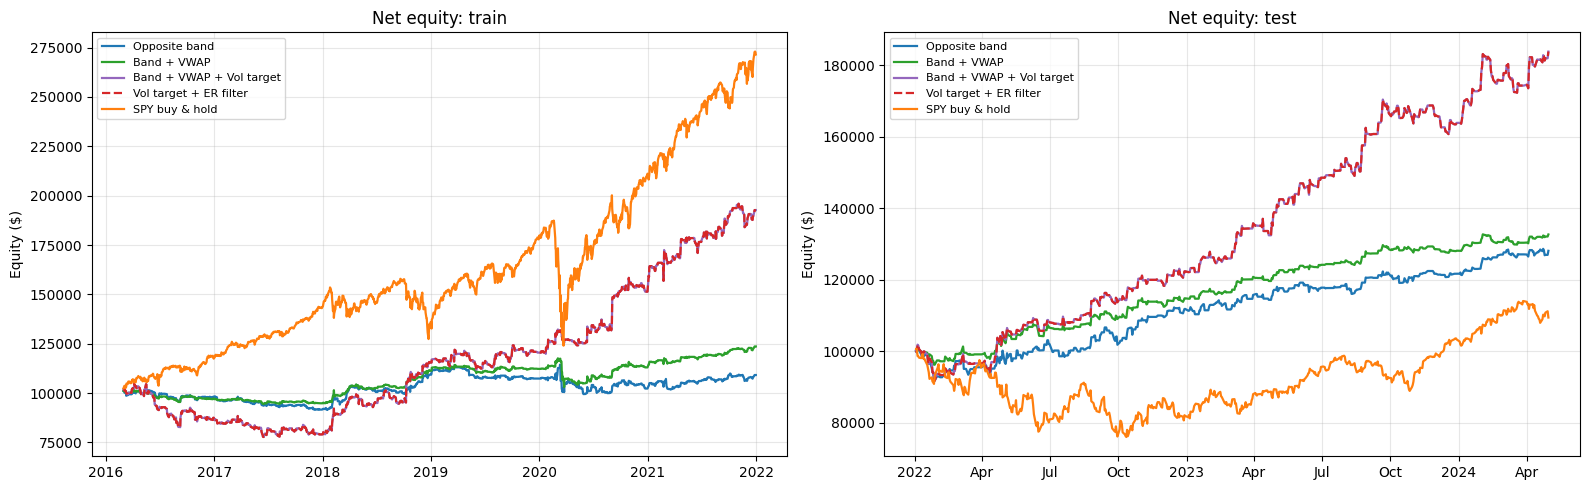

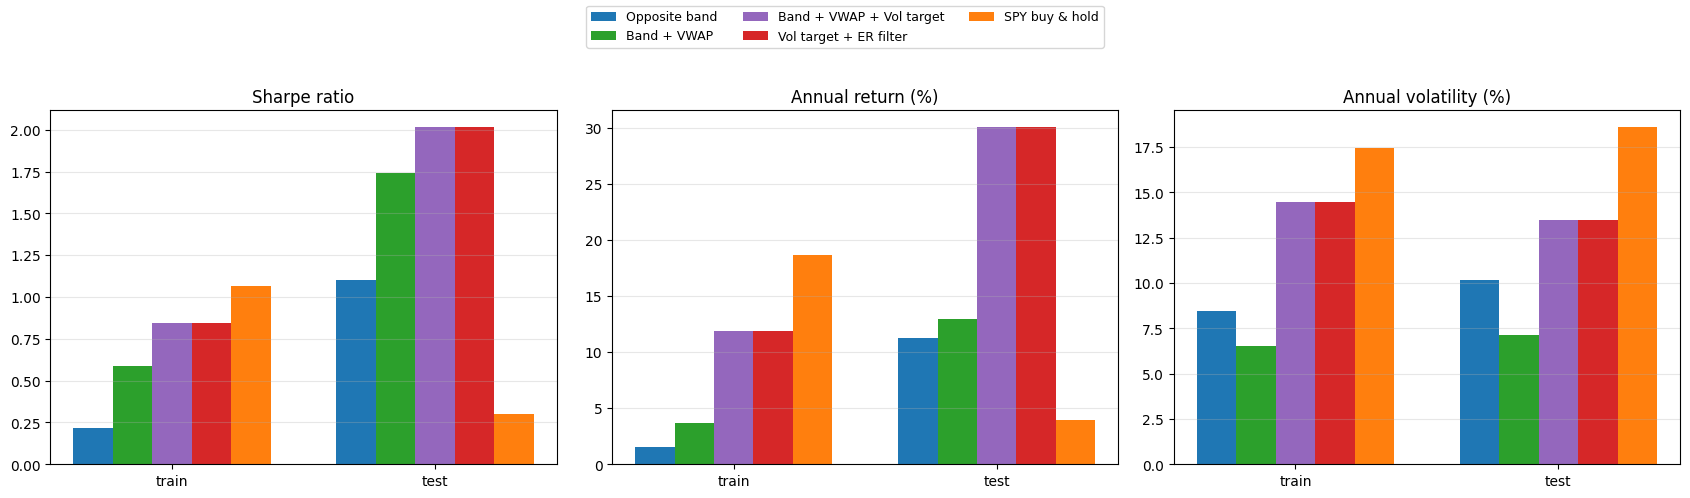

In [37]:
er_colors = [
    "tab:blue", "tab:green", "tab:purple",
    "tab:red", "tab:orange",
]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, split in zip(axes, ["train", "test"]):
    sample = er_comparison[er_comparison["split"].eq(split)]

    for model, color in zip(er_models, er_colors):
        curve = INITIAL_CASH * (1 + sample[model]).cumprod()

        ax.plot(
            sample.index,
            curve,
            label=model,
            color=color,
            linestyle="--" if model == ER_MODEL_NAME else "-",
            linewidth=1.6,
        )

    locator = mdates.AutoDateLocator()
    ax.xaxis.set_major_locator(locator)
    ax.xaxis.set_major_formatter(
        mdates.ConciseDateFormatter(locator)
    )
    ax.set_title(f"Net equity: {split}")
    ax.set_ylabel("Equity ($)")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)

fig.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

metric_specs = [
    ("sharpe", "Sharpe ratio", 1.0),
    ("annual_return", "Annual return (%)", 100.0),
    ("annual_volatility", "Annual volatility (%)", 100.0),
]

x = np.arange(2)
width = 0.15

for ax, (metric, title, scale) in zip(axes, metric_specs):
    for i, (model, color) in enumerate(zip(er_models, er_colors)):
        values = [
            er_performance.loc[(split, model), metric] * scale
            for split in ["train", "test"]
        ]

        ax.bar(
            x + (i - 2) * width,
            values,
            width,
            label=model,
            color=color,
        )

    ax.set_xticks(x, ["train", "test"])
    ax.set_title(title)
    ax.grid(axis="y", alpha=0.3)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="upper center", ncol=3, fontsize=9,
)
fig.tight_layout(rect=(0, 0, 1, 0.86))
plt.show()

### 7.7 Diagnose equality directly

Report the selected threshold, rejected-entry count and

$$\max_t|r_t^{\mathrm{ER}}-r_t^{\mathrm{baseline}}|.$$

The saved maximum difference is approximately $8.7\times10^{-19}$, numerical floating-point noise. The plotting result is therefore explained by the model selection, rather than by a missing plotted series.

In [38]:
print("Selected ER threshold:", er_best_threshold)

print("\nValidation comparison:")
print(
    er_threshold_table[
        ["threshold", "sharpe", "annual_return",
         "active_days", "rejected_entries"]
    ].to_string(index=False)
)

print("\nRejected entries:", er_daily["rejected_entries"].sum())

difference = (
    er_daily["strategy_return"]
    - vol_target_daily["strategy_return"]
)
print("Maximum daily return difference:", difference.abs().max())

Selected ER threshold: 0.0

Validation comparison:
 threshold    sharpe  annual_return  active_days  rejected_entries
       0.0  1.652008       0.272728          144                 0
       0.2  1.383395       0.202243          133                65
       0.4  0.804057       0.065997           74               450
       0.6 -0.134336      -0.001150            5               806

Rejected entries: 0
Maximum daily return difference: 8.673617379884035e-19


## 8. Extension B: LSTM daily risk allocation
### 8.1 Hypothesis, calendar and fixed model capacity

**Extension:** preserve the original intraday trading direction but learn whether the coming session merits more or less of its planned risk. This is a daily sizing model, not a prediction of SPY's closing price.

Use 20 preceding sessions, 8 features, one LSTM layer with 16 hidden units, seed 42 and CPU execution. Development/validation/test dates are inherited from the existing calendar. The small model and fixed configuration limit capacity relative to the available daily history; they do not eliminate overfitting.

In [39]:
import copy
import numpy as np
import pandas as pd
import torch
from torch import nn
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

required = [
    "daily", "cal_sizing", "features_vwap", "sigma_daily",
    "vwap_daily", "vol_target_daily", "comparison_dynamic",
    "performance_metrics", "INITIAL_CASH",
    "VOL_TARGET_DAILY", "MAX_LEVERAGE",
]
missing = [name for name in required if name not in globals()]
if missing:
    raise RuntimeError("Run previous cells first: " + ", ".join(missing))

DL_SEQUENCE = 20
DL_VALIDATION_START = pd.Timestamp("2021-01-01")
DL_SEED = 42
DL_HIDDEN = 16
DL_EPOCHS = 80
DL_PATIENCE = 15
DL_LEARNING_RATE = 0.001
DL_WEIGHT_DECAY = 0.001

np.random.seed(DL_SEED)
torch.manual_seed(DL_SEED)
torch.set_num_threads(2)

# Use CPU for this small model.
DL_DEVICE = torch.device("cpu")


# ---------------------------------------------------------
# Prepare the evaluation calendar.
# ---------------------------------------------------------

dl_cal = cal_sizing.copy()
dl_cal["date"] = pd.to_datetime(dl_cal["date"]).dt.normalize()
dl_cal = dl_cal.sort_values("date").reset_index(drop=True)

dl_all_dates = pd.DatetimeIndex(dl_cal["date"])

dl_eval_cal = dl_cal[
    dl_cal["split"].isin(["train", "test"])
].copy()

dl_dates = pd.DatetimeIndex(dl_eval_cal["date"])
dl_split = pd.Series(
    dl_eval_cal["split"].to_numpy(),
    index=dl_dates,
)

dl_daily = daily.copy()
if "date" in dl_daily.columns:
    dl_daily["date"] = pd.to_datetime(
        dl_daily["date"]
    ).dt.normalize()
    dl_daily = dl_daily.set_index("date")
else:
    dl_daily.index = pd.to_datetime(dl_daily.index).normalize()

if dl_daily.index.has_duplicates or dl_all_dates.has_duplicates:
    raise ValueError("Duplicate daily dates.")

dl_daily = dl_daily.sort_index().reindex(dl_all_dates)

needed_columns = [
    "open", "high", "low", "close",
    "volume", "return_raw", "vix_close",
]
if not set(needed_columns).issubset(dl_daily.columns):
    raise ValueError("Daily source columns are incomplete.")


# ---------------------------------------------------------
# Each row describes that completed day.
# The model window ends on the day BEFORE the sizing decision.
# ---------------------------------------------------------



### 8.2 Eight daily state features

For a completed day $u$, construct raw one-day and five-day returns, range, candle body, recent risk, relative volume, VIX level and VIX change. Important transformations are

$$r_u^{(5)}=C_u/C_{u-5}-1,\quad \mathrm{range}_u=(H_u-L_u)/C_u,\quad
\mathrm{body}_u=C_u/O_u-1,$$
$$\mathrm{RV}_u=V_u/\overline V_{u,20}-1,\quad
\mathrm{VIXlevel}_u=\mathrm{VIXclose}_u/100,\quad
\Delta\mathrm{VIX}_u=\mathrm{VIXclose}_u/\mathrm{VIXclose}_{u-1}-1.$$

The rolling risk feature includes returns through completed day $u$. Although each feature row includes that day's close, the next step supplies only rows **strictly before** decision day $t$. The model therefore uses past observed states when selecting morning risk.

In [40]:
dl_features = pd.DataFrame(index=dl_all_dates)

dl_features["return_1"] = dl_daily["return_raw"]
dl_features["return_5"] = (
    dl_daily["close"] / dl_daily["close"].shift(5) - 1
)
dl_features["range"] = (
    (dl_daily["high"] - dl_daily["low"]) / dl_daily["close"]
)
dl_features["body"] = (
    dl_daily["close"] / dl_daily["open"] - 1
)
dl_features["volatility_14"] = (
    dl_daily["return_raw"].rolling(14, min_periods=14).std(ddof=1)
)
dl_features["relative_volume"] = (
    dl_daily["volume"]
    / dl_daily["volume"].rolling(20, min_periods=20).mean()
    - 1
)
dl_features["vix_level"] = dl_daily["vix_close"] / 100
dl_features["vix_change"] = (
    dl_daily["vix_close"] / dl_daily["vix_close"].shift(1) - 1
)

dl_features = dl_features.replace([np.inf, -np.inf], np.nan)

dl_train_mask = (
    dl_split.eq("train")
    & (dl_dates < DL_VALIDATION_START)
).to_numpy()

dl_val_mask = (
    dl_split.eq("train")
    & (dl_dates >= DL_VALIDATION_START)
).to_numpy()

dl_test_mask = dl_split.eq("test").to_numpy()

if (
    dl_train_mask.sum() < 200
    or dl_val_mask.sum() < 100
    or dl_test_mask.sum() == 0
):
    raise ValueError("Insufficient training, validation or test sessions.")



### 8.3 Fit scaling on development history and exclude today

Estimate feature medians, means and standard deviations on development observations only. Fill missing values with those medians, standardize, and clip inputs to $[-5,5]$:

$$z_{u,j}=\operatorname{clip}\left(\frac{\operatorname{impute}(x_{u,j})-\mu_j^{\mathrm{dev}}}{s_j^{\mathrm{dev}}},-5,5\right),\qquad
X_t=[z_{t-20},\ldots,z_{t-1}].$$

`position - DL_SEQUENCE:position` excludes the current session completely. Validation/test observations never fit the preprocessing parameters. Historical warm-up observations can supply input context without becoming evaluated return rows.

In [41]:
# Fit preprocessing only on development-period observations.
preprocessing_mask = (
    dl_features.index >= dl_dates[dl_train_mask].min()
) & (
    dl_features.index < DL_VALIDATION_START
)

dl_median = dl_features.loc[preprocessing_mask].median()
if dl_median.isna().any():
    raise ValueError("A feature has no finite development observations.")

dl_filled = dl_features.fillna(dl_median)
dl_mean = dl_filled.loc[preprocessing_mask].mean()
dl_std = (
    dl_filled.loc[preprocessing_mask]
    .std(ddof=0)
    .replace(0, 1)
)

dl_scaled = ((dl_filled - dl_mean) / dl_std).clip(-5, 5)

sequences = []

for date in dl_dates:
    position = dl_all_dates.get_loc(date)

    if position < DL_SEQUENCE:
        raise ValueError(f"Insufficient history before {date.date()}.")

    # Exclude the current session entirely.
    window = dl_scaled.iloc[
        position - DL_SEQUENCE:position
    ].to_numpy(dtype=np.float32)

    if not np.isfinite(window).all():
        raise ValueError("Nonfinite model inputs.")

    sequences.append(window)

dl_X = np.stack(sequences)


# ---------------------------------------------------------
# Derive daily per-share trading results from the existing
# fixed-size VWAP backtest. All proportional costs are included.
# ---------------------------------------------------------



### 8.4 Per-share replay and a differentiable training return

Because the existing VWAP strategy fixes share size within a session and costs are proportional to shares, derive net PnL per unit of daily share size:

$$u_t=\frac{\Pi_t^{\mathrm{gross}}-\mathrm{commission}_t-\mathrm{slippage}_t}{Q_t^{\mathrm{fixed}}}.$$

The no-rounding proxy for the original dynamic strategy is

$$\widetilde r_t=\ell_t\,u_t/O_t.$$

This proxy is differentiable when multiplied by the predicted weight. Actual validation and evaluation still replay integer shares. The shortcut is valid for the present fixed-within-day sizing and linear costs; it would need revision for minimum commissions, nonlinear market impact or changing intraday quantities.

In [42]:
dl_vwap = vwap_daily.copy()
dl_vwap.index = pd.to_datetime(dl_vwap.index).normalize()
dl_vwap = dl_vwap.sort_index()

dl_previous = vol_target_daily.copy()
dl_previous.index = pd.to_datetime(dl_previous.index).normalize()
dl_previous = dl_previous.sort_index()

if (
    not dl_vwap.index.equals(dl_dates)
    or not dl_previous.index.equals(dl_dates)
):
    raise AssertionError("Existing strategy calendars differ.")

opening_source = features_vwap[["date", "day_open"]].copy()
opening_source["date"] = pd.to_datetime(
    opening_source["date"]
).dt.normalize()

dl_open = (
    opening_source.groupby("date")["day_open"]
    .first()
    .reindex(dl_dates)
)

valid_open = np.isfinite(dl_open) & dl_open.gt(0)
source_quantity = pd.Series(0.0, index=dl_dates)

source_quantity.loc[valid_open] = np.floor(
    dl_vwap.loc[valid_open, "equity_start"]
    / dl_open.loc[valid_open]
)

dl_unit = pd.DataFrame(index=dl_dates)
dl_unit["day_open"] = dl_open
dl_unit["split"] = dl_split
dl_unit["status"] = dl_vwap["status"]
dl_unit["orders"] = dl_vwap["orders"]

dl_sigma = sigma_daily.copy()
dl_sigma.index = pd.to_datetime(dl_sigma.index).normalize()
dl_sigma = dl_sigma.reindex(dl_dates)

dl_unit["leverage"] = 0.0
valid_sigma = np.isfinite(dl_sigma) & dl_sigma.gt(0)
dl_unit.loc[valid_sigma, "leverage"] = np.minimum(
    MAX_LEVERAGE,
    VOL_TARGET_DAILY / dl_sigma.loc[valid_sigma],
)

for col in ["gross_pnl", "commission", "slippage"]:
    bad = source_quantity.le(0) & dl_vwap[col].abs().gt(1e-8)
    if bad.any():
        raise AssertionError("Cannot derive per-share results.")

    dl_unit[col] = (
        dl_vwap[col]
        / source_quantity.replace(0, np.nan)
    ).fillna(0.0)

# Differentiable training return before integer-share rounding.
dl_proxy_return = (
    dl_unit["leverage"]
    * (
        dl_unit["gross_pnl"]
        - dl_unit["commission"]
        - dl_unit["slippage"]
    )
    / dl_unit["day_open"]
).replace([np.inf, -np.inf], np.nan).fillna(0.0)




### 8.5 Exact daily replay of the learned multiplier

For an allocation $w_t\in[0,1]$ chosen before the session,

$$Q_t(w_t)=\left\lfloor\frac{E_{t-1}\ell_t w_t}{O_t}\right\rfloor,\qquad
\Pi_t^{\mathrm{net}}(w_t)=Q_t(w_t)u_t,\qquad
r_t(w_t)=\Pi_t^{\mathrm{net}}(w_t)/E_{t-1}.$$

The model can reduce the baseline's risk, but cannot add a new trade direction or exceed its planned leverage. Replaying gross PnL and both cost components separately preserves the original accounting. The daily replay returns statistics; it does not generate a new detailed intraday order ledger.

In [43]:
def dl_replay(weights, dates=None):
    """Replay daily integer shares with the original per-share costs."""
    template = dl_unit
    if dates is not None:
        template = template.loc[template.index.isin(dates)]

    if template.empty:
        raise ValueError("No replay sessions.")

    equity = float(INITIAL_CASH)
    rows = []

    for date, row in template.iterrows():
        weight = float(weights.loc[date])

        if not np.isfinite(weight) or not 0 <= weight <= 1:
            raise ValueError("Risk multipliers must lie in [0, 1].")

        start = equity
        opening = float(row["day_open"])

        quantity = (
            int(np.floor(
                start * row["leverage"] * weight / opening
            ))
            if np.isfinite(opening) and opening > 0 else 0
        )

        gross = quantity * row["gross_pnl"]
        fee = quantity * row["commission"]
        slip = quantity * row["slippage"]
        net = gross - fee - slip

        equity = start + net
        if not np.isfinite(equity) or equity <= 0:
            raise RuntimeError(f"Portfolio exhausted on {date.date()}.")

        rows.append({
            "date": date,
            "split": row["split"],
            "equity_start": start,
            "equity_end": equity,
            "gross_pnl": gross,
            "commission": fee,
            "slippage": slip,
            "net_pnl": net,
            "strategy_return": net / start,
            "risk_multiplier": weight,
            "leverage": row["leverage"] * weight,
            "quantity": quantity,
            "orders": int(row["orders"]) if quantity > 0 else 0,
        })

    return pd.DataFrame(rows).set_index("date")




### 8.6 All-one allocation must recover the original

Check $w_t\equiv1$ against the existing volatility-target daily backtest, including equity, PnL and costs. The retained output confirms the identity and reports **1,220 development, 252 validation and 584 test sessions**, with input shape $(2056,20,8)$.

In [44]:
# A risk multiplier of one must reproduce the existing strategy.
dl_one = pd.Series(1.0, index=dl_dates)
dl_check = dl_replay(dl_one)

for col in [
    "equity_start", "equity_end", "gross_pnl",
    "commission", "slippage", "net_pnl", "strategy_return",
]:
    np.testing.assert_allclose(
        dl_check[col],
        dl_previous[col],
        rtol=1e-8,
        atol=1e-6,
        err_msg=f"Daily replay check failed for {col}.",
    )

print("Daily replay baseline check passed.")
print("Development sessions:", int(dl_train_mask.sum()))
print("Validation sessions:", int(dl_val_mask.sum()))
print("Test sessions:", int(dl_test_mask.sum()))
print("Input shape:", dl_X.shape)

Daily replay baseline check passed.
Development sessions: 1220
Validation sessions: 252
Test sessions: 584
Input shape: (2056, 20, 8)


### 8.7 A bounded LSTM allocation head

The LSTM compresses the past 20-day sequence into its final hidden state $h_t$. A sigmoid head yields

$$h_t=\mathrm{LSTM}_{\theta}(X_t),\qquad
w_t=\operatorname{sigmoid}(a^\top h_t+b)\in(0,1).$$

For completeness, an LSTM updates gates as $g_u=\operatorname{sigmoid}(W_g[z_u,h_{u-1}]+b_g)$ for $g\in\{f,i,o\}$, with candidate memory $\widetilde c_u=\tanh(W_c[z_u,h_{u-1}]+b_c)$:

$$c_u=f_u\odot c_{u-1}+i_u\odot\widetilde c_u,\qquad h_u=o_u\odot\tanh(c_u).$$

The head starts at $a=0$, $b=\log3$, hence $w_t=0.75$ before training. This initialization is an implementation prior, not a result learned from the test period. Adam uses learning rate $10^{-3}$ and weight decay $10^{-3}$.

In [45]:
class DailyRiskLSTM(nn.Module):
    def __init__(self, input_size, hidden_size=16):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=1,
            batch_first=True,
        )
        self.head = nn.Linear(hidden_size, 1)

        # Start from a constant 75% risk allocation.
        nn.init.zeros_(self.head.weight)
        nn.init.constant_(self.head.bias, np.log(3.0))

    def forward(self, x):
        _, (hidden, _) = self.lstm(x)
        return torch.sigmoid(self.head(hidden[-1])).squeeze(-1)


dl_model = DailyRiskLSTM(
    input_size=dl_X.shape[-1],
    hidden_size=DL_HIDDEN,
).to(DL_DEVICE)

dl_optimizer = torch.optim.Adam(
    dl_model.parameters(),
    lr=DL_LEARNING_RATE,
    weight_decay=DL_WEIGHT_DECAY,
)

dl_X_train = torch.as_tensor(
    dl_X[dl_train_mask], device=DL_DEVICE
)
dl_X_val = torch.as_tensor(
    dl_X[dl_val_mask], device=DL_DEVICE
)
dl_y_train = torch.as_tensor(
    dl_proxy_return.to_numpy()[dl_train_mask],
    dtype=torch.float32,
    device=DL_DEVICE,
)

dl_val_dates = dl_dates[dl_val_mask]




### 8.8 Train for net risk-adjusted returns

With the differentiable proxy $\widehat r_t=w_t\widetilde r_t$, minimize

$$\mathcal L(\theta)=-\sqrt{252}\frac{\operatorname{mean}(\widehat r_t)}{\max(\operatorname{std}_{\mathrm{sample}}(\widehat r_t),10^{-6})}
+0.05\operatorname{mean}\big[(w_t-0.75)^2\big].$$

The second term softly anchors allocation near the initialization. The loss is evaluated on development returns; it is not a supervised prediction of tomorrow's market return. Validation Sharpe is computed separately through the integer-share `dl_replay`, rather than through the smooth proxy.

In [46]:
def dl_training_loss(weights, returns):
    net_returns = weights * returns

    sharpe = (
        net_returns.mean()
        / net_returns.std(unbiased=True).clamp_min(1e-6)
        * np.sqrt(252.0)
    )

    # A soft anchor limits extreme allocations on this small dataset.
    allocation_penalty = 0.05 * ((weights - 0.75) ** 2).mean()

    return -sharpe + allocation_penalty


def dl_validation():
    dl_model.eval()

    with torch.no_grad():
        weights = dl_model(dl_X_val).cpu().numpy()

    weight_series = pd.Series(weights, index=dl_val_dates)
    result = dl_replay(weight_series, dates=dl_val_dates)

    return performance_metrics(
        result["strategy_return"]
    )["sharpe"]




### 8.9 Select the checkpoint with validation Sharpe

Train for at most 80 epochs, clip the gradient norm to 1 and stop after 15 epochs without a validation improvement exceeding $10^{-4}$. Retain the untrained constant-allocation initialization as an eligible checkpoint.

$$\theta^*=\underset{\theta_e}{\arg\max}\ \mathrm{Sharpe}_{\mathrm{validation}}\big(\mathrm{replay}(w_{\theta_e})\big).$$

The checkpoint is restored before test inference. The saved run selects epoch 80, so it reaches the configured training limit rather than triggering early stopping. Selecting a model using validation is intended; its validation Sharpe is not an unbiased estimate of future performance.

In [47]:
# Include the untrained constant-allocation initialization.
dl_best_score = dl_validation()
dl_best_state = copy.deepcopy(dl_model.state_dict())
dl_best_epoch = 0
dl_no_improvement = 0
dl_history_rows = []

if not np.isfinite(dl_best_score):
    raise ValueError("Validation Sharpe is undefined.")

for epoch in range(1, DL_EPOCHS + 1):
    dl_model.train()
    dl_optimizer.zero_grad()

    train_weights = dl_model(dl_X_train)
    loss = dl_training_loss(train_weights, dl_y_train)

    if not torch.isfinite(loss):
        raise RuntimeError("Nonfinite training loss.")

    loss.backward()
    nn.utils.clip_grad_norm_(dl_model.parameters(), max_norm=1.0)
    dl_optimizer.step()

    val_sharpe = dl_validation()

    dl_history_rows.append({
        "epoch": epoch,
        "loss": float(loss.detach().cpu()),
        "validation_sharpe": val_sharpe,
    })

    if np.isfinite(val_sharpe) and val_sharpe > dl_best_score + 1e-4:
        dl_best_score = val_sharpe
        dl_best_state = copy.deepcopy(dl_model.state_dict())
        dl_best_epoch = epoch
        dl_no_improvement = 0
    else:
        dl_no_improvement += 1

    if epoch == 1 or epoch % 10 == 0:
        print(
            f"Epoch {epoch:3d} | "
            f"Loss {loss.item():.4f} | "
            f"Validation Sharpe {val_sharpe:.3f}"
        )

    if dl_no_improvement >= DL_PATIENCE:
        print(f"Early stopping at epoch {epoch}.")
        break

# Freeze the validation-selected checkpoint.
dl_model.load_state_dict(dl_best_state)
dl_model.eval()

print(f"\nSelected epoch: {dl_best_epoch}")
print(f"Best validation Sharpe: {dl_best_score:.3f}")



Epoch   1 | Loss -0.6693 | Validation Sharpe 1.653
Epoch  10 | Loss -0.6706 | Validation Sharpe 1.653
Epoch  20 | Loss -0.6730 | Validation Sharpe 1.655
Epoch  30 | Loss -0.6774 | Validation Sharpe 1.659
Epoch  40 | Loss -0.6859 | Validation Sharpe 1.668
Epoch  50 | Loss -0.7019 | Validation Sharpe 1.686
Epoch  60 | Loss -0.7325 | Validation Sharpe 1.720
Epoch  70 | Loss -0.7804 | Validation Sharpe 1.765
Epoch  80 | Loss -0.8369 | Validation Sharpe 1.805

Selected epoch: 80
Best validation Sharpe: 1.805


### 8.10 Freeze the model and build constant-allocation controls

Evaluate the selected LSTM and two constant allocations: $w_t=0.5$ and

$$w_t=\bar w_{\mathrm{dev}}=\frac{1}{n_{\mathrm{dev}}}\sum_{t\in\mathrm{dev}}w_t.$$

The matched constant is estimated on development data only. In the saved run it is **58.39%**. This control helps determine whether improvements merely arise from lower average exposure. The LSTM's average allocation is 64.48% on validation and 67.41% on test; exposure is therefore not exactly matched within every period.

In [48]:
# Test inference occurs only after checkpoint selection.
with torch.no_grad():
    dl_all_weights = dl_model(
        torch.as_tensor(dl_X, device=DL_DEVICE)
    ).cpu().numpy()

dl_weights = pd.Series(
    dl_all_weights,
    index=dl_dates,
    name="risk_multiplier",
)

dl_lstm_daily = dl_replay(dl_weights)
dl_half_daily = dl_replay(pd.Series(0.5, index=dl_dates))

# Match average exposure using development data only.
dl_average_weight = float(dl_weights.loc[
    dl_dates[dl_train_mask]
].mean())

dl_constant_daily = dl_replay(
    pd.Series(dl_average_weight, index=dl_dates)
)

dl_history = pd.DataFrame(dl_history_rows)

print("\nRisk multiplier distribution:")
print(
    pd.DataFrame({
        "split": dl_split,
        "risk_multiplier": dl_weights,
    }).groupby("split")["risk_multiplier"].describe().round(3)
)


Risk multiplier distribution:
        count   mean    std    min    25%    50%    75%    max
split                                                         
test    584.0  0.674  0.127  0.448  0.529  0.754  0.774  0.805
train  1472.0  0.594  0.136  0.435  0.466  0.531  0.752  0.810


### 8.11 LSTM results and the interpretation of lower risk

Compare all strategies over identical development, validation and historical-test dates. The saved test results are:

| Strategy | CAGR | Annual volatility | Sharpe | Maximum drawdown |
|---|---:|---:|---:|---:|
| Original volatility target | 30.04% | 13.49% | 2.015 | −9.95% |
| Constant matched allocation | 16.82% | 7.87% | 2.015 | −5.89% |
| LSTM risk allocation | 19.48% | 9.26% | 1.969 | −7.59% |

The LSTM reduces drawdown relative to the full-risk baseline, but also reduces return and does **not improve test Sharpe**. It is also weaker in Sharpe/drawdown than the matched constant in this period, although its higher average exposure produces a higher CAGR. Validation gains do not establish a robust incremental timing edge.

In [49]:
dl_comparison = pd.DataFrame(index=dl_dates)
dl_comparison["Original vol target"] = (
    dl_previous["strategy_return"]
)
dl_comparison["Constant 50%"] = (
    dl_half_daily["strategy_return"]
)
dl_comparison["Constant matched allocation"] = (
    dl_constant_daily["strategy_return"]
)
dl_comparison["LSTM risk allocation"] = (
    dl_lstm_daily["strategy_return"]
)

dl_old_comparison = comparison_dynamic.copy()
dl_old_comparison.index = pd.to_datetime(
    dl_old_comparison.index
).normalize()

dl_comparison["SPY buy & hold"] = (
    dl_old_comparison["SPY buy & hold"].reindex(dl_dates)
)

dl_models = dl_comparison.columns.tolist()

dl_period_masks = {
    "development": dl_train_mask,
    "validation": dl_val_mask,
    "test": dl_test_mask,
}

dl_records = []

for period, mask in dl_period_masks.items():
    for model in dl_models:
        dl_records.append({
            "period": period,
            "strategy": model,
            **performance_metrics(
                dl_comparison.loc[mask, model]
            ),
        })

dl_performance = pd.DataFrame(dl_records).set_index(
    ["period", "strategy"]
)

dl_formatted = dl_performance.copy()

for col in [
    "total_return", "annual_return",
    "annual_volatility", "max_drawdown",
]:
    dl_formatted[col] = dl_formatted[col].map(
        lambda value: f"{value:.2%}"
    )

dl_formatted["sharpe"] = dl_formatted["sharpe"].map(
    lambda value: f"{value:.3f}"
)

print("\nPerformance comparison:")
print(dl_formatted.to_string())

print(
    "\nConstant matched allocation:",
    f"{dl_average_weight:.2%}",
)




Performance comparison:
                                         days total_return annual_return annual_volatility sharpe max_drawdown
period      strategy                                                                                          
development Original vol target          1220       51.40%         8.94%            14.30%  0.669      -25.72%
            Constant 50%                 1220       24.52%         4.63%             7.15%  0.669      -13.56%
            Constant matched allocation  1220       28.88%         5.38%             8.35%  0.669      -15.70%
            LSTM risk allocation         1220       40.68%         7.31%             8.78%  0.846      -12.64%
            SPY buy & hold               1220      111.15%        16.69%            18.26%  0.938      -33.79%
validation  Original vol target           252       27.29%        27.29%            15.31%  1.653       -6.06%
            Constant 50%                  252       13.13%        13.13%             7.

### 8.12 Equity and the pre-session allocation series

Display development, validation and test separately, followed by the learned daily allocation. The allocation plot describes a weight computed from preceding days; it is not selected after observing the current session's trading result. The baseline and constant-allocation controls should remain visible in the equity comparison.

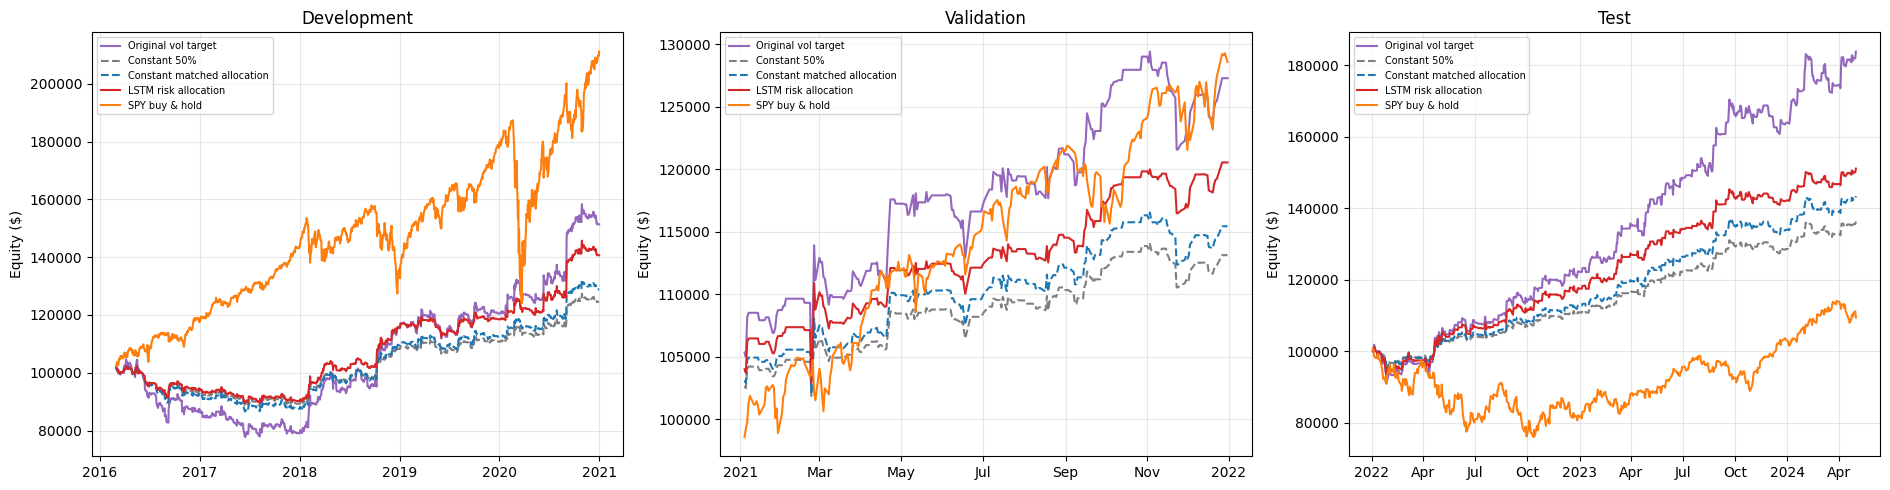

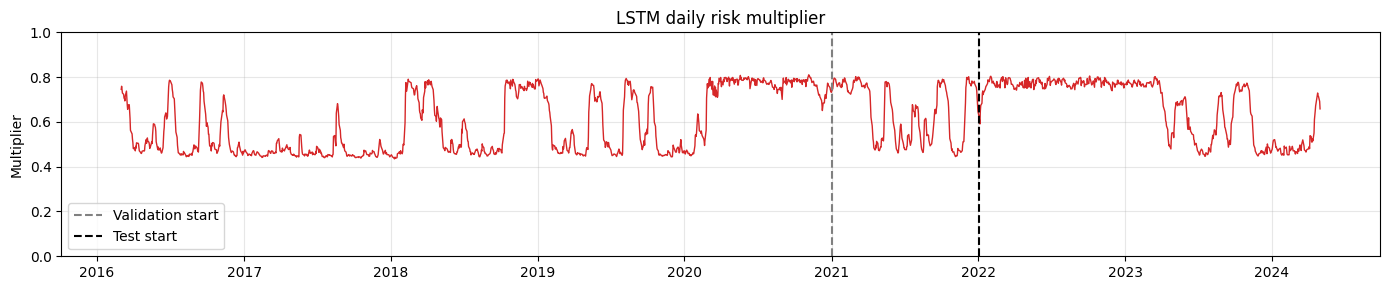

In [50]:
dl_colors = [
    "tab:purple", "tab:gray", "tab:blue",
    "tab:red", "tab:orange",
]

fig, axes = plt.subplots(1, 3, figsize=(19, 5))

for ax, (period, mask) in zip(axes, dl_period_masks.items()):
    sample = dl_comparison.loc[mask]

    for model, color in zip(dl_models, dl_colors):
        curve = INITIAL_CASH * (1 + sample[model]).cumprod()

        ax.plot(
            sample.index,
            curve,
            label=model,
            color=color,
            linestyle="--" if "Constant" in model else "-",
        )

    locator = mdates.AutoDateLocator()
    ax.xaxis.set_major_locator(locator)
    ax.xaxis.set_major_formatter(
        mdates.ConciseDateFormatter(locator)
    )
    ax.set_title(period.capitalize())
    ax.set_ylabel("Equity ($)")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=7)

fig.tight_layout()
plt.show()

# Display the allocation chosen before each trading session.
fig, ax = plt.subplots(figsize=(14, 3))

ax.plot(
    dl_weights.index,
    dl_weights,
    color="tab:red",
    linewidth=1,
)
ax.axvline(
    DL_VALIDATION_START,
    color="gray",
    linestyle="--",
    label="Validation start",
)
ax.axvline(
    dl_dates[dl_test_mask].min(),
    color="black",
    linestyle="--",
    label="Test start",
)
ax.set_ylim(0, 1)
ax.set_title("LSTM daily risk multiplier")
ax.set_ylabel("Multiplier")
ax.grid(alpha=0.3)
ax.legend()

fig.tight_layout()
plt.show()

### 8.13 Compact numerical report

Print the four principal risk/return metrics and mean allocations for each period. These diagnostics provide the numerical evidence behind the plotted curves. Differences between continuous-history period slices and separately restarted validation replays arise in part from integer share rounding.

In [51]:
selected_models = [
    "Original vol target",
    "Constant 50%",
    "Constant matched allocation",
    "LSTM risk allocation",
]

print(
    dl_performance.loc[
        pd.IndexSlice[:, selected_models],
        ["annual_return", "annual_volatility", "sharpe", "max_drawdown"],
    ].round(4).to_string()
)

print("\nAverage LSTM allocation:")
for period, mask in dl_period_masks.items():
    print(period, f"{dl_weights.loc[dl_dates[mask]].mean():.2%}")

                                         annual_return  annual_volatility  sharpe  max_drawdown
period      strategy                                                                           
development Original vol target                 0.0894             0.1430  0.6694       -0.2572
validation  Original vol target                 0.2729             0.1531  1.6526       -0.0606
test        Original vol target                 0.3004             0.1349  2.0150       -0.0995
development Constant 50%                        0.0463             0.0715  0.6693       -0.1356
validation  Constant 50%                        0.1313             0.0765  1.6515       -0.0306
test        Constant 50%                        0.1428             0.0674  2.0151       -0.0506
development Constant matched allocation         0.0538             0.0835  0.6692       -0.1570
validation  Constant matched allocation         0.1545             0.0894  1.6522       -0.0357
test        Constant matched allocation 

## 9. Extension C: TCN expected-return entry filter
### 9.1 Hypothesis and common data

**Extension:** use the most recent 30 completed minutes to estimate the net payoff of a hypothetical new breakout trade, then admit only attractive entries. Compare a nonlinear causal TCN with a simple Ridge regressor using the same inputs and labels.

Bring minute volume into the existing band/VWAP feature table, using the same completed-bar timestamps. The original half-hour decisions, complete-session policy and volatility-sized baseline remain the basis of evaluation. Threshold candidates are fixed at `None`, 0, 1 and 2 basis points, with `None` explicitly admitting every entry.

In [52]:
import copy
from pathlib import Path
import numpy as np
import pandas as pd
import torch
from torch import nn
import torch.nn.functional as F
from sklearn.linear_model import Ridge
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

required = [
    "features_vwap", "cal_sizing", "sigma_daily", "DATA_DIR",
    "vol_target_daily", "comparison_dynamic", "performance_metrics",
    "INITIAL_CASH", "COMMISSION_PER_SHARE", "SLIPPAGE_PER_SHARE",
    "VOL_TARGET_DAILY", "MAX_LEVERAGE",
]
missing = [name for name in required if name not in globals()]
if missing:
    raise RuntimeError("Run previous cells first: " + ", ".join(missing))

TCN_WINDOW = 30
TCN_VALIDATION_START = pd.Timestamp("2021-01-01")
TCN_THRESHOLDS = [None, 0.0, 1.0, 2.0]  # None means no filtering.
TCN_MIN_ACTIVE_DAYS = 20
TCN_SEED = 42

np.random.seed(TCN_SEED)
torch.manual_seed(TCN_SEED)
torch.set_num_threads(2)


# ---------------------------------------------------------
# Prepare source data.
# ---------------------------------------------------------

tcn_minutes = features_vwap[
    ["date", "bar_end_ny", "open", "close",
     "upper_bound", "lower_bound", "vwap"]
].copy()

tcn_minutes["date"] = pd.to_datetime(
    tcn_minutes["date"]
).dt.normalize()
tcn_minutes["bar_end_ny"] = pd.to_datetime(
    tcn_minutes["bar_end_ny"], utc=True
).dt.tz_convert("America/New_York")

volume_source = pd.read_csv(
    Path(DATA_DIR) / "SPY_1min.csv",
    usecols=["timestamp", "volume"],
)
volume_source["bar_end_ny"] = (
    pd.to_datetime(volume_source["timestamp"], utc=True)
    + pd.Timedelta(minutes=1)
).dt.tz_convert("America/New_York")

tcn_minutes = tcn_minutes.merge(
    volume_source[["bar_end_ny", "volume"]],
    on="bar_end_ny",
    how="left",
    validate="one_to_one",
).sort_values(["date", "bar_end_ny"])

tcn_calendar = cal_sizing.copy()
tcn_calendar["date"] = pd.to_datetime(
    tcn_calendar["date"]
).dt.normalize()
for col in ["market_open", "market_close"]:
    tcn_calendar[col] = pd.to_datetime(
        tcn_calendar[col], utc=True
    )
tcn_calendar = tcn_calendar[
    tcn_calendar["split"].isin(["train", "test"])
].sort_values("date").reset_index(drop=True)

groups = {
    date: frame
    for date, frame in tcn_minutes.groupby("date", sort=False)
}

tcn_cache = {}
sample_rows = []
sequence_rows = []

round_trip_cost = 2 * (
    COMMISSION_PER_SHARE + SLIPPAGE_PER_SHARE
)



### 9.2 Direction-normalized sequences and forward trade labels

For each nonzero baseline direction $d\in\{-1,1\}$ at decision $\tau$, construct a 30-minute sequence. The direction $d$ is the candidate side known at that decision and is applied to all rows in its window.

| Channel at completed minute $k$ | Formula / meaning |
|---|---|
| Minute return | $d(P_k/P_{k-1}-1)$; the session open precedes the first close |
| Open-relative move | $d(P_k/O_t-1)$ |
| VWAP-relative move | $d(P_k/\widetilde{\mathrm{VWAP}}_k-1)$ |
| Distance from the relevant band | $d(P_k-B_k)/O_t$, with $B_k=U_k$ for long and $L_k$ for short |
| Relative volume | $\log(V_k/\overline V_{k,30})$, using available bars through $k$ |
| Time within the session | $k/N_t$, where scheduled $N_t$ is already known |
| Candidate direction | $d$ |

Enter hypothetically at the next minute open. Exit at the first later half-hour at which the original direction no longer equals $d$, or at the session close. The target is the one-share net round-trip payoff in basis points:

$$y_{t,\tau}=10^4\frac{d(P_{\mathrm{exit}}-P_{\mathrm{entry}})-2(c+\delta)}{P_{\mathrm{entry}}}.$$

Future prices are used **only as training/evaluation labels**, not in sequence inputs. Every label ends within its own session, so labels do not cross the development/validation date boundary. Candidate samples also include continued same-side breakout signals while a position might already be held; they are not identical to the realized portfolio trades. Labels can overlap within a day and must not be treated as independent observations in significance testing.

In [53]:
for session in tcn_calendar.itertuples(index=False):
    date = session.date
    info = {
        "split": session.split,
        "status": "missing_session",
        "missing_signal_points": 0,
    }
    tcn_cache[date] = info

    day = groups.get(date)
    if day is None or day.empty:
        continue

    expected = pd.date_range(
        session.market_open + pd.Timedelta(minutes=1),
        periods=int(session.expected_minutes),
        freq="min",
    )
    actual = pd.DatetimeIndex(
        day["bar_end_ny"]
    ).tz_convert("UTC")

    prices = day[["open", "close"]].to_numpy(float)
    complete = (
        len(day) == len(expected)
        and actual.equals(expected)
        and expected[-1] == session.market_close
        and np.isfinite(prices).all()
        and (prices > 0).all()
    )
    if not complete:
        info["status"] = "incomplete_prices"
        continue

    opens = day["open"].to_numpy(float)
    closes = day["close"].to_numpy(float)
    upper = day["upper_bound"].to_numpy(float)
    lower = day["lower_bound"].to_numpy(float)
    vwap = day["vwap"].to_numpy(float)
    volume = day["volume"].to_numpy(float)

    path = np.r_[opens[0], closes]
    minute_return = np.diff(path) / path[:-1]

    # This volume baseline uses only the current and previous bars.
    recent_volume = (
        pd.Series(volume).rolling(30, min_periods=1).mean().to_numpy()
    )
    with np.errstate(divide="ignore", invalid="ignore"):
        relative_volume = np.log(volume / recent_volume)

    decision = (
        day["bar_end_ny"].dt.minute.isin([0, 30])
        & day["bar_end_ny"].lt(session.market_close)
    )
    idx = np.flatnonzero(decision.to_numpy())

    eligible = (
        np.isfinite(upper[idx])
        & np.isfinite(lower[idx])
        & (upper[idx] >= lower[idx])
        & np.isfinite(vwap[idx])
        & (vwap[idx] > 0)
    )

    direction = np.zeros(len(idx), dtype=int)
    direction[
        eligible
        & (closes[idx] > upper[idx])
        & (closes[idx] > vwap[idx])
    ] = 1
    direction[
        eligible
        & (closes[idx] < lower[idx])
        & (closes[idx] < vwap[idx])
    ] = -1

    references = np.r_[opens[idx + 1], closes[-1]]
    times = day["bar_end_ny"].iloc[idx].tolist() + [
        session.market_close.tz_convert("America/New_York")
    ]
    sample_ids = np.full(len(idx), -1, dtype=int)

    for j, side in enumerate(direction):
        if side == 0:
            continue

        end = int(idx[j]) + 1
        start = end - TCN_WINDOW
        if start < 0:
            raise ValueError("Insufficient history at first decision.")

        boundary = upper if side == 1 else lower

        # Every sequence ends at the completed decision bar.
        with np.errstate(divide="ignore", invalid="ignore"):
            sequence = np.column_stack([
                side * minute_return,
                side * (closes / opens[0] - 1),
                side * (closes / vwap - 1),
                side * (closes - boundary) / opens[0],
                relative_volume,
                np.arange(1, len(day) + 1) / len(day),
                np.full(len(day), side),
            ])[start:end]

        sequence[~np.isfinite(sequence)] = np.nan

        # Hypothetical entry at the next open, followed by the
        # first original-rule exit or reversal, otherwise the close.
        later_exit = np.flatnonzero(
            direction[j + 1:] != side
        )
        exit_j = (
            j + 1 + int(later_exit[0])
            if len(later_exit) else len(direction)
        )

        entry_price = references[j]
        exit_price = references[exit_j]
        net_per_share = (
            side * (exit_price - entry_price) - round_trip_cost
        )

        sample_ids[j] = len(sample_rows)
        sequence_rows.append(sequence.astype(np.float32))
        sample_rows.append({
            "date": date,
            "split": session.split,
            "decision_time": times[j],
            "label_end": times[exit_j],
            "direction": side,
            "target_bps": net_per_share / entry_price * 10_000,
        })

    info.update({
        "status": "partial_bounds" if (~eligible).any() else "complete",
        "missing_signal_points": int((~eligible).sum()),
        "day_open": opens[0],
        "direction": direction,
        "sample_ids": sample_ids,
        "references": references,
        "times": times,
    })



### 9.3 Development-only imputation and scaling

Split sequences by their trading dates. Estimate each channel's median, mean and standard deviation using development sequences only; repeated overlapping observations receive their representation in that sample array. Transform every sequence with the frozen parameters:

$$Z_{i,k,j}=\operatorname{clip}\left(\frac{\operatorname{impute}(X_{i,k,j})-\mu_j^{\mathrm{dev}}}{s_j^{\mathrm{dev}}},-8,8\right).$$

Targets remain in basis points. Zero-variance channels use scale one. Scaling all validation/test inputs with development statistics is allowed; fitting those statistics on validation/test is not.

In [54]:
if not sample_rows:
    raise ValueError("No valid breakout samples.")

tcn_samples = pd.DataFrame(sample_rows)
tcn_X_raw = np.stack(sequence_rows)

tcn_fit_mask = (
    tcn_samples["split"].eq("train")
    & tcn_samples["date"].lt(TCN_VALIDATION_START)
).to_numpy()

tcn_val_mask = (
    tcn_samples["split"].eq("train")
    & tcn_samples["date"].ge(TCN_VALIDATION_START)
).to_numpy()

tcn_val_dates = tcn_calendar.loc[
    tcn_calendar["split"].eq("train")
    & tcn_calendar["date"].ge(TCN_VALIDATION_START),
    "date",
]

if tcn_fit_mask.sum() < 100 or tcn_val_mask.sum() < 50:
    raise ValueError("Insufficient development or validation samples.")

# Fit imputation and scaling only on development sequences.
train_flat = tcn_X_raw[tcn_fit_mask].reshape(
    -1, tcn_X_raw.shape[-1]
)
tcn_median = np.nanmedian(train_flat, axis=0)
if not np.isfinite(tcn_median).all():
    raise ValueError("An input channel has no finite training values.")

filled_train = np.where(
    np.isnan(train_flat), tcn_median, train_flat
)
tcn_mean = filled_train.mean(axis=0)
tcn_std = filled_train.std(axis=0)
tcn_std[tcn_std < 1e-8] = 1.0

tcn_X = np.where(
    np.isnan(tcn_X_raw), tcn_median, tcn_X_raw
)
tcn_X = np.clip(
    (tcn_X - tcn_mean) / tcn_std, -8, 8
).astype(np.float32)

tcn_y = tcn_samples["target_bps"].to_numpy(np.float32)




### 9.4 Admit new entries with a forecast threshold

Let $\widehat y_{t,\tau}$ be the predicted net trade payoff. On an attempted new side, admit the candidate if

$$\widehat y_{t,\tau}\ge h.$$

The filter is consulted only when the nonzero desired side differs from the held side. An original exit still closes the position; a rejected reversal closes the old side; an unchanged held side is not closed by a low prediction. Subsequent decisions may retry an entry that was rejected earlier.

`threshold=None` disables forecast gating altogether. For numeric thresholds, missing/nonfinite predictions reject the entry. Integer shares, leverage, costs, daily equity compounding and close-of-session liquidation follow the existing baseline. Portfolio returns, not candidate-label averages, decide whether filtering is useful.

In [55]:
def backtest_tcn(scores=None, threshold=None, dates=None):
    allowed = None if dates is None else set(dates)
    equity = float(INITIAL_CASH)
    rows = []

    for session in tcn_calendar.itertuples(index=False):
        date = session.date
        if allowed is not None and date not in allowed:
            continue

        info = tcn_cache[date]
        start_equity = equity
        sigma = float(sigma_daily.get(date, np.nan))
        leverage = (
            min(MAX_LEVERAGE, VOL_TARGET_DAILY / sigma)
            if np.isfinite(sigma) and sigma > 0 else 0.0
        )

        gross = fee = slip = 0.0
        orders = rejected = attempts = 0
        status = info["status"]
        missing_points = info["missing_signal_points"]

        if leverage == 0:
            status = "missing_volatility"
            missing_points = 0

        elif "direction" in info:
            quantity = int(np.floor(
                start_equity * leverage / info["day_open"]
            ))
            held = 0
            targets = []

            for desired, sample_id in zip(
                info["direction"], info["sample_ids"]
            ):
                desired = int(desired)

                if desired != 0 and desired != held:
                    attempts += 1
                    if threshold is not None:
                        score = (
                            scores[sample_id]
                            if scores is not None and sample_id >= 0
                            else np.nan
                        )
                        if not np.isfinite(score) or score < threshold:
                            desired = 0
                            rejected += 1

                held = desired
                targets.append(quantity * held)

            targets.append(0)
            changes = np.diff(np.r_[0, targets]).astype(np.int64)

            gross = -float(np.dot(changes, info["references"]))
            shares = int(np.abs(changes).sum())
            fee = shares * COMMISSION_PER_SHARE
            slip = shares * SLIPPAGE_PER_SHARE
            orders = int(np.count_nonzero(changes))

        net = gross - fee - slip
        equity = start_equity + net
        if not np.isfinite(equity) or equity <= 0:
            raise RuntimeError(f"Portfolio exhausted on {date.date()}.")

        rows.append({
            "date": date,
            "split": session.split,
            "equity_start": start_equity,
            "equity_end": equity,
            "gross_pnl": gross,
            "commission": fee,
            "slippage": slip,
            "net_pnl": net,
            "strategy_return": net / start_equity,
            "orders": orders,
            "entry_attempts": attempts,
            "rejected_entries": rejected,
            "status": status,
            "missing_signal_points": missing_points,
        })

    if not rows:
        raise ValueError("No evaluation sessions.")
    return pd.DataFrame(rows).set_index("date").sort_index()




### 9.5 Recover the original strategy without filtering

The unfiltered engine must reproduce the prior volatility-target backtest's calendar and PnL/cost/equity columns. The retained output confirms the check passed and reports **3,573 development candidates, 844 validation candidates and 6,367 total sequences** of shape $(30,7)$; the remaining 1,950 candidates belong to the test period.

Candidate counts are larger than realized trade counts because the dataset includes repeated same-side signals. The evaluation continues to use one coherent daily portfolio.

In [56]:
tcn_base_daily = backtest_tcn()

previous = vol_target_daily.copy()
previous.index = pd.to_datetime(previous.index).normalize()
previous = previous.sort_index()

if not tcn_base_daily.index.equals(previous.index):
    raise AssertionError("Baseline calendars differ.")

for col in [
    "equity_start", "equity_end", "gross_pnl",
    "commission", "slippage", "net_pnl", "strategy_return",
]:
    np.testing.assert_allclose(
        tcn_base_daily[col], previous[col],
        rtol=1e-8, atol=1e-7,
        err_msg=f"TCN baseline check failed: {col}",
    )

print("TCN unfiltered baseline check passed.")
print("Development samples:", int(tcn_fit_mask.sum()))
print("Validation samples:", int(tcn_val_mask.sum()))
print("Sequence shape:", tcn_X.shape)

TCN unfiltered baseline check passed.
Development samples: 3573
Validation samples: 844
Sequence shape: (6367, 30, 7)


### 9.6 Small causal, dilated residual TCN

Left padding ensures that a convolution at sequence index $k$ reads current/past inputs only:

$$z_k=\sum_{m=0}^{K-1}W_m x_{k-md}+b,\qquad K=3.$$

Three residual blocks each contain two convolutions, 16 channels, ReLU and dropout 0.1, with dilations $d\in\{1,2,4\}$. The final sequence output is mapped to one predicted payoff. Its receptive field is

$$R=1+2(K-1)\sum_{d\in\{1,2,4\}}d=29\ \text{minutes}.$$

The input window has 30 minutes, but the last output directly covers its most recent 29 rows. This distinction is worth explaining rather than describing the entire window as fully used. The causal architecture does not replace the external requirement that all feature rows end at the decision time.

In [57]:
# ---------------------------------------------------------
# Small causal TCN.
# ---------------------------------------------------------

class CausalBlock(nn.Module):
    def __init__(self, inputs, channels, dilation):
        super().__init__()
        self.padding = 2 * dilation

        self.conv1 = nn.Conv1d(
            inputs, channels, kernel_size=3, dilation=dilation
        )
        self.conv2 = nn.Conv1d(
            channels, channels, kernel_size=3, dilation=dilation
        )
        self.skip = (
            nn.Conv1d(inputs, channels, kernel_size=1)
            if inputs != channels else nn.Identity()
        )
        self.dropout = nn.Dropout(0.1)

    def forward(self, x):
        residual = self.skip(x)

        out = self.conv1(F.pad(x, (self.padding, 0)))
        out = self.dropout(F.relu(out))

        out = self.conv2(F.pad(out, (self.padding, 0)))
        out = self.dropout(F.relu(out))

        return F.relu(out + residual)


class ReturnTCN(nn.Module):
    def __init__(self, input_channels):
        super().__init__()
        self.blocks = nn.Sequential(
            CausalBlock(input_channels, 16, dilation=1),
            CausalBlock(16, 16, dilation=2),
            CausalBlock(16, 16, dilation=4),
        )
        self.head = nn.Linear(16, 1)

    def forward(self, x):
        # Input: batch, time, feature.
        out = self.blocks(x.transpose(1, 2))
        return self.head(out[:, :, -1]).squeeze(-1)


tcn_model = ReturnTCN(tcn_X.shape[-1])

tcn_optimizer = torch.optim.Adam(
    tcn_model.parameters(), lr=0.001, weight_decay=0.001
)
tcn_loss_function = nn.SmoothL1Loss(beta=10.0)

train_dataset = torch.utils.data.TensorDataset(
    torch.from_numpy(tcn_X[tcn_fit_mask]),
    torch.from_numpy(tcn_y[tcn_fit_mask]),
)
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True,  # Shuffle only development samples.
    num_workers=0,
)

X_validation = torch.from_numpy(tcn_X[tcn_val_mask])
y_validation = torch.from_numpy(tcn_y[tcn_val_mask])

best_loss = np.inf
best_state = None
best_epoch = None
no_improvement = 0



### 9.7 Robust return-regression loss and checkpoint selection

Train with Smooth-L1 loss in basis-point units. For residual $e=\widehat y-y$ and $\beta=10$,

$$\ell_\beta(e)=\begin{cases}
e^2/(2\beta),&|e|<\beta,\\
|e|-\beta/2,&|e|\ge\beta.
\end{cases}$$

Use Adam with learning rate and weight decay $10^{-3}$, batches of 128 development candidates, gradient norm clipping at 1, at most 60 epochs and patience 10. Samples are shuffled within the development period; this does not randomize the date-based split.

The checkpoint minimizes validation prediction loss, not test loss or test Sharpe. The saved run selects **epoch 5** and stops at epoch 15. Prediction-loss selection and later portfolio-threshold selection both use validation, which adds selection flexibility.

In [58]:
for epoch in range(1, 61):
    tcn_model.train()
    total_loss = 0.0

    for batch_x, batch_y in train_loader:
        tcn_optimizer.zero_grad()
        prediction = tcn_model(batch_x)
        loss = tcn_loss_function(prediction, batch_y)

        if not torch.isfinite(loss):
            raise RuntimeError("Nonfinite training loss.")

        loss.backward()
        nn.utils.clip_grad_norm_(tcn_model.parameters(), 1.0)
        tcn_optimizer.step()
        total_loss += loss.item() * len(batch_x)

    tcn_model.eval()
    with torch.no_grad():
        validation_loss = tcn_loss_function(
            tcn_model(X_validation), y_validation
        ).item()

    if not np.isfinite(validation_loss):
        raise RuntimeError("Nonfinite validation loss.")

    if validation_loss < best_loss - 1e-4:
        best_loss = validation_loss
        best_state = copy.deepcopy(tcn_model.state_dict())
        best_epoch = epoch
        no_improvement = 0
    else:
        no_improvement += 1

    if epoch == 1 or epoch % 10 == 0:
        print(
            f"Epoch {epoch:2d} | "
            f"Train loss {total_loss / len(train_dataset):.3f} | "
            f"Validation loss {validation_loss:.3f}"
        )

    if no_improvement >= 10:
        print(f"Early stopping at epoch {epoch}.")
        break

tcn_model.load_state_dict(best_state)
tcn_model.eval()
print("Selected TCN epoch:", best_epoch)



Epoch  1 | Train loss 22.763 | Validation loss 15.788
Epoch 10 | Train loss 22.083 | Validation loss 15.427
Early stopping at epoch 15.
Selected TCN epoch: 5


### 9.8 Ridge as a same-information linear control

Flatten the same 30 × 7 sequence into 210 inputs and fit Ridge with $\alpha=10$:

$$\min_{a,b}\ \sum_{i\in\mathrm{dev}}(y_i-a^\top\operatorname{vec}(Z_i)-b)^2+10\|a\|_2^2.$$

Ridge uses the identical development labels, preprocessing and subsequent trade replay. This tests whether the TCN's extra nonlinear capacity is useful relative to a simpler model. Only validation predictions are populated during threshold selection; test predictions do not choose the threshold.

In [59]:
# Ridge sees the same 30-minute input and target.
tcn_ridge = Ridge(alpha=10.0)
tcn_ridge.fit(
    tcn_X[tcn_fit_mask].reshape(tcn_fit_mask.sum(), -1),
    tcn_y[tcn_fit_mask],
)

# Only validation scores are populated during threshold selection.
tcn_validation_scores = np.full(len(tcn_samples), np.nan)
ridge_validation_scores = np.full(len(tcn_samples), np.nan)

with torch.no_grad():
    tcn_validation_scores[tcn_val_mask] = (
        tcn_model(X_validation).numpy()
    )

ridge_validation_scores[tcn_val_mask] = tcn_ridge.predict(
    tcn_X[tcn_val_mask].reshape(tcn_val_mask.sum(), -1)
)




### 9.9 Select thresholds on portfolio Sharpe, then freeze

For each model, replay the 2021 portfolio for the predefined candidate set

$$\mathcal H=\{\mathrm{All\ entries},0,1,2\}\ \text{bp},\qquad
h^*=\arg\max_{h\in\mathcal H}\mathrm{Sharpe}_{\mathrm{validation}}(h),$$

subject to finite Sharpe and at least 20 active days. Ties favor the earlier candidate, including the unfiltered baseline. A fully cash strategy has undefined Sharpe and fails the activity rule.

**Saved selection:** the TCN's numeric thresholds reject every validation entry; the chosen action is **All entries**. Ridge chooses **2 bp**. These thresholds are frozen before prediction/replay on the historical test. “2 bp” is a predicted hypothetical net payoff, not a guaranteed realized return or an extra transaction-cost charge.

In [60]:
def select_return_threshold(scores, model_name):
    records = []

    for candidate, threshold in enumerate(TCN_THRESHOLDS):
        result = backtest_tcn(
            scores=scores,
            threshold=threshold,
            dates=tcn_val_dates,
        )
        records.append({
            "candidate": candidate,
            "threshold": (
                "All entries" if threshold is None
                else f"{threshold:.1f} bp"
            ),
            **performance_metrics(result["strategy_return"]),
            "active_days": int(result["orders"].gt(0).sum()),
            "orders": int(result["orders"].sum()),
            "rejected_entries": int(result["rejected_entries"].sum()),
        })

    table = pd.DataFrame(records)
    eligible = table[
        np.isfinite(table["sharpe"])
        & table["active_days"].ge(TCN_MIN_ACTIVE_DAYS)
    ]
    if eligible.empty:
        raise ValueError("No eligible validation threshold.")

    best = eligible.sort_values(
        ["sharpe", "candidate"], ascending=[False, True]
    ).iloc[0]

    threshold = TCN_THRESHOLDS[int(best["candidate"])]

    print(f"\n{model_name}: validation threshold comparison")
    print(table.round(4).to_string(index=False))
    print("Selected:", best["threshold"])

    return threshold, table


tcn_threshold, tcn_selection = select_return_threshold(
    tcn_validation_scores, "TCN"
)
ridge_threshold, ridge_selection = select_return_threshold(
    ridge_validation_scores, "Ridge"
)

# Freeze both thresholds before historical test inference.
with torch.no_grad():
    # Predict in small batches to limit memory usage.
    tcn_predictions = np.concatenate([
        tcn_model(torch.from_numpy(tcn_X[i:i + 512])).numpy()
        for i in range(0, len(tcn_X), 512)
    ])

ridge_predictions = tcn_ridge.predict(
    tcn_X.reshape(len(tcn_X), -1)
)

tcn_filtered_daily = backtest_tcn(
    tcn_predictions, tcn_threshold
)
ridge_filtered_daily = backtest_tcn(
    ridge_predictions, ridge_threshold
)


TCN: validation threshold comparison
 candidate   threshold  days  total_return  annual_return  annual_volatility  sharpe  max_drawdown  active_days  orders  rejected_entries
         0 All entries   252        0.2727         0.2727             0.1531   1.652       -0.0606          144     419                 0
         1      0.0 bp   252        0.0000         0.0000             0.0000     NaN        0.0000            0       0               844
         2      1.0 bp   252        0.0000         0.0000             0.0000     NaN        0.0000            0       0               844
         3      2.0 bp   252        0.0000         0.0000             0.0000     NaN        0.0000            0       0               844
Selected: All entries

Ridge: validation threshold comparison
 candidate   threshold  days  total_return  annual_return  annual_volatility  sharpe  max_drawdown  active_days  orders  rejected_entries
         0 All entries   252        0.2727         0.2727             0.

### 9.10 Portfolio results versus prediction diagnostics

The retained test results are original Sharpe **2.015**, Ridge **1.775**, and TCN **2.015**. TCN equals the original because its selected filter is disabled. Ridge's validation improvement does not continue into test Sharpe, though its lower activity/exposure reduces test volatility and drawdown.

The diagnostic table separately reports rank correlation and mean predicted/actual candidate payoff. In the saved output, TCN has positive test rank correlation (0.0667) but a negative mean prediction (−5.5710 bp). Ranking and calibration are different properties; neither alone establishes portfolio improvement. Candidate-label correlations are also not independent-trade significance tests.

In [61]:
tcn_comparison = pd.DataFrame({
    "split": tcn_base_daily["split"],
    "Original vol target": tcn_base_daily["strategy_return"],
    "Ridge return filter": ridge_filtered_daily["strategy_return"],
    "TCN return filter": tcn_filtered_daily["strategy_return"],
})

old_comparison = comparison_dynamic.copy()
old_comparison.index = pd.to_datetime(
    old_comparison.index
).normalize()

tcn_comparison["SPY buy & hold"] = (
    old_comparison["SPY buy & hold"]
    .reindex(tcn_comparison.index)
)

tcn_models = [
    "Original vol target",
    "Ridge return filter",
    "TCN return filter",
    "SPY buy & hold",
]

tcn_periods = {
    "development": (
        tcn_comparison["split"].eq("train")
        & (tcn_comparison.index < TCN_VALIDATION_START)
    ),
    "validation": (
        tcn_comparison["split"].eq("train")
        & (tcn_comparison.index >= TCN_VALIDATION_START)
    ),
    "test": tcn_comparison["split"].eq("test"),
}

records = []
for period, mask in tcn_periods.items():
    for model in tcn_models:
        records.append({
            "period": period,
            "strategy": model,
            **performance_metrics(
                tcn_comparison.loc[mask, model]
            ),
        })

tcn_performance = pd.DataFrame(records).set_index(
    ["period", "strategy"]
)
formatted = tcn_performance.copy()

for col in [
    "total_return", "annual_return",
    "annual_volatility", "max_drawdown",
]:
    formatted[col] = formatted[col].map(lambda x: f"{x:.2%}")

formatted["sharpe"] = formatted["sharpe"].map(
    lambda x: f"{x:.3f}"
)

print("\nPerformance comparison:")
print(formatted.to_string())

print("\nTCN activity:")
print(
    tcn_filtered_daily.groupby("split")[
        ["orders", "rejected_entries", "commission", "slippage"]
    ].sum().round(2).to_string()
)

# Candidate-level diagnostics are not realized portfolio returns.
diagnostic_rows = []
for name, prediction in [
    ("Ridge", ridge_predictions),
    ("TCN", tcn_predictions),
]:
    for period, mask in [
        ("validation", tcn_val_mask),
        ("test", tcn_samples["split"].eq("test").to_numpy()),
    ]:
        p = pd.Series(prediction[mask])
        y = pd.Series(tcn_y[mask])
        diagnostic_rows.append({
            "period": period,
            "model": name,
            "samples": len(p),
            "rank_correlation": p.corr(y, method="spearman"),
            "mean_prediction_bps": p.mean(),
            "mean_actual_bps": y.mean(),
        })

print("\nPrediction diagnostics:")
print(pd.DataFrame(diagnostic_rows).round(4).to_string(index=False))




Performance comparison:
                                 days total_return annual_return annual_volatility sharpe max_drawdown
period      strategy                                                                                  
development Original vol target  1220       51.40%         8.94%            14.30%  0.669      -25.72%
            Ridge return filter  1220      128.03%        18.56%            12.70%  1.403      -12.21%
            TCN return filter    1220       51.40%         8.94%            14.30%  0.669      -25.72%
            SPY buy & hold       1220      111.15%        16.69%            18.26%  0.938      -33.79%
validation  Original vol target   252       27.29%        27.29%            15.31%  1.653       -6.06%
            Ridge return filter   252       21.95%        21.95%            11.78%  1.743       -7.38%
            TCN return filter     252       27.29%        27.29%            15.31%  1.653       -6.06%
            SPY buy & hold        252       28.6

### 9.11 Display the frozen TCN and Ridge comparisons

Development, validation and historical-test panels show net equity on the same period-specific scale. The red TCN line coincides with the purple original strategy. The next section restores **all three paper stages** to the final figure so the original paper comparison is explicit.

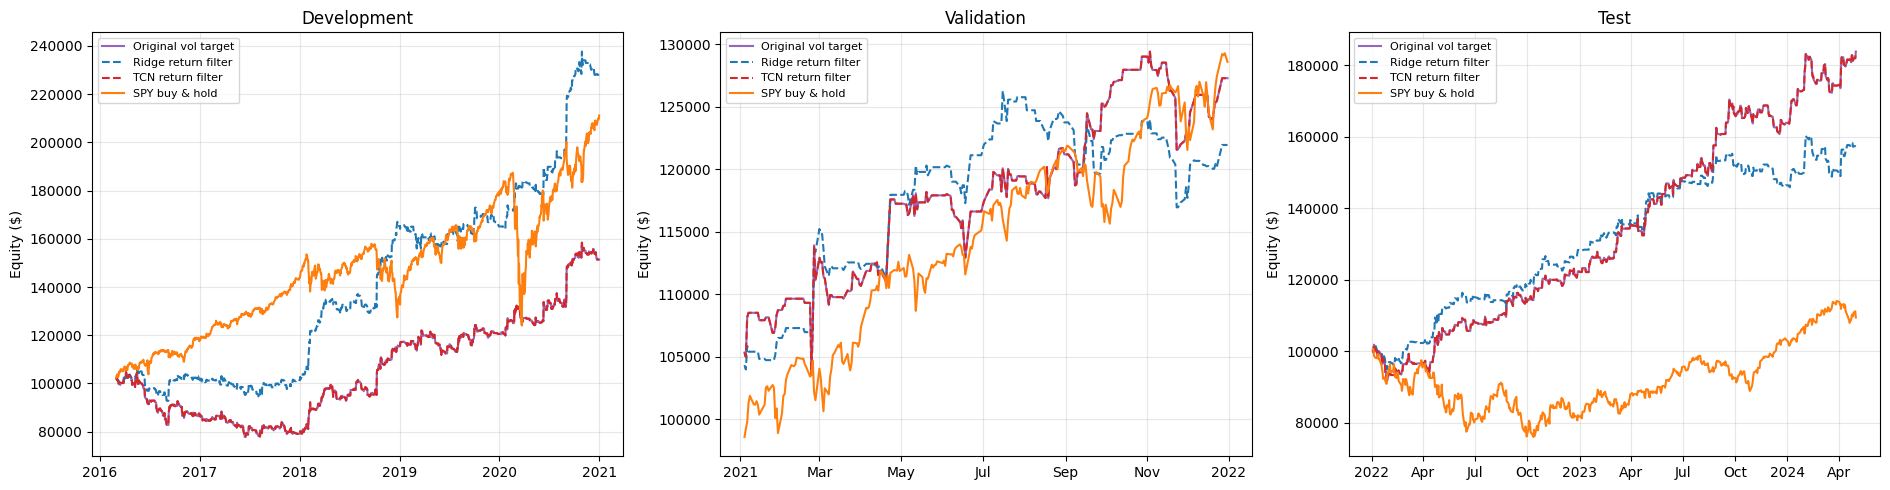

In [62]:
colors = ["tab:purple", "tab:blue", "tab:red", "tab:orange"]
fig, axes = plt.subplots(1, 3, figsize=(19, 5))

for ax, (period, mask) in zip(axes, tcn_periods.items()):
    sample = tcn_comparison.loc[mask]

    for model, color in zip(tcn_models, colors):
        curve = INITIAL_CASH * (1 + sample[model]).cumprod()
        ax.plot(
            sample.index, curve,
            label=model, color=color,
            linestyle="--" if "filter" in model else "-",
        )

    locator = mdates.AutoDateLocator()
    ax.xaxis.set_major_locator(locator)
    ax.xaxis.set_major_formatter(
        mdates.ConciseDateFormatter(locator)
    )
    ax.set_title(period.capitalize())
    ax.set_ylabel("Equity ($)")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)

fig.tight_layout()
plt.show()

## 10. Consolidated evidence and paper correspondence
### 10.1 All completed experiments on one historical test

This table includes the paper stages **and** ER, LSTM, Ridge and TCN. The former final table omitted ER and LSTM; including them does not change any strategy calculation.

The saved snapshot is reconstructed from the uploaded notebook's printed statistics and identity check. Its precision is limited to the reported rounding. Running the cell after the complete model pipeline recomputes full-precision statistics from the common daily-return calendar. Running it independently displays the embedded snapshot.

The 2022-2024 test has already been inspected during research. It is a historical holdout, not a fresh blind evaluation.


In [63]:
SAVED_OVERVIEW_ROWS = [{'period': 'development', 'strategy': 'Opposite band', 'days': 1220, 'total_return': 0.0232, 'annual_return': 0.004699999999999999, 'annual_volatility': 0.0882, 'sharpe': 0.098, 'max_drawdown': -0.13019999999999998}, {'period': 'development', 'strategy': 'Band + VWAP', 'days': 1220, 'total_return': 0.1303, 'annual_return': 0.0256, 'annual_volatility': 0.068, 'sharpe': 0.406, 'max_drawdown': -0.1241}, {'period': 'development', 'strategy': 'Band + VWAP + Vol target', 'days': 1220, 'total_return': 0.514, 'annual_return': 0.0894, 'annual_volatility': 0.14300000000000002, 'sharpe': 0.669, 'max_drawdown': -0.2572}, {'period': 'development', 'strategy': 'ER entry filter', 'days': 1220, 'total_return': 0.514, 'annual_return': 0.0894, 'annual_volatility': 0.14300000000000002, 'sharpe': 0.669, 'max_drawdown': -0.2572}, {'period': 'development', 'strategy': 'LSTM risk allocation', 'days': 1220, 'total_return': 0.4068, 'annual_return': 0.0731, 'annual_volatility': 0.08779999999999999, 'sharpe': 0.846, 'max_drawdown': -0.1264}, {'period': 'development', 'strategy': 'Ridge return filter', 'days': 1220, 'total_return': 1.2803, 'annual_return': 0.1856, 'annual_volatility': 0.127, 'sharpe': 1.403, 'max_drawdown': -0.12210000000000001}, {'period': 'development', 'strategy': 'TCN return filter', 'days': 1220, 'total_return': 0.514, 'annual_return': 0.0894, 'annual_volatility': 0.14300000000000002, 'sharpe': 0.669, 'max_drawdown': -0.2572}, {'period': 'development', 'strategy': 'SPY buy & hold', 'days': 1220, 'total_return': 1.1115000000000002, 'annual_return': 0.16690000000000002, 'annual_volatility': 0.1826, 'sharpe': 0.938, 'max_drawdown': -0.3379}, {'period': 'validation', 'strategy': 'Opposite band', 'days': 252, 'total_return': 0.067, 'annual_return': 0.067, 'annual_volatility': 0.0661, 'sharpe': 1.014, 'max_drawdown': -0.050300000000000004}, {'period': 'validation', 'strategy': 'Band + VWAP', 'days': 252, 'total_return': 0.09380000000000001, 'annual_return': 0.09380000000000001, 'annual_volatility': 0.049699999999999994, 'sharpe': 1.831, 'max_drawdown': -0.0236}, {'period': 'validation', 'strategy': 'Band + VWAP + Vol target', 'days': 252, 'total_return': 0.2729, 'annual_return': 0.2729, 'annual_volatility': 0.1531, 'sharpe': 1.653, 'max_drawdown': -0.060599999999999994}, {'period': 'validation', 'strategy': 'ER entry filter', 'days': 252, 'total_return': 0.2729, 'annual_return': 0.2729, 'annual_volatility': 0.1531, 'sharpe': 1.653, 'max_drawdown': -0.060599999999999994}, {'period': 'validation', 'strategy': 'LSTM risk allocation', 'days': 252, 'total_return': 0.20550000000000002, 'annual_return': 0.20550000000000002, 'annual_volatility': 0.1067, 'sharpe': 1.805, 'max_drawdown': -0.0416}, {'period': 'validation', 'strategy': 'Ridge return filter', 'days': 252, 'total_return': 0.2195, 'annual_return': 0.2195, 'annual_volatility': 0.11779999999999999, 'sharpe': 1.743, 'max_drawdown': -0.0738}, {'period': 'validation', 'strategy': 'TCN return filter', 'days': 252, 'total_return': 0.2729, 'annual_return': 0.2729, 'annual_volatility': 0.1531, 'sharpe': 1.653, 'max_drawdown': -0.060599999999999994}, {'period': 'validation', 'strategy': 'SPY buy & hold', 'days': 252, 'total_return': 0.28600000000000003, 'annual_return': 0.28600000000000003, 'annual_volatility': 0.12960000000000002, 'sharpe': 2.007, 'max_drawdown': -0.051100000000000007}, {'period': 'test', 'strategy': 'Opposite band', 'days': 584, 'total_return': 0.2805, 'annual_return': 0.11259999999999999, 'annual_volatility': 0.1017, 'sharpe': 1.1, 'max_drawdown': -0.08929999999999999}, {'period': 'test', 'strategy': 'Band + VWAP', 'days': 584, 'total_return': 0.32630000000000003, 'annual_return': 0.12960000000000002, 'annual_volatility': 0.07150000000000001, 'sharpe': 1.74, 'max_drawdown': -0.0467}, {'period': 'test', 'strategy': 'Band + VWAP + Vol target', 'days': 584, 'total_return': 0.838, 'annual_return': 0.3004, 'annual_volatility': 0.1349, 'sharpe': 2.015, 'max_drawdown': -0.09949999999999999}, {'period': 'test', 'strategy': 'ER entry filter', 'days': 584, 'total_return': 0.838, 'annual_return': 0.3004, 'annual_volatility': 0.1349, 'sharpe': 2.015, 'max_drawdown': -0.09949999999999999}, {'period': 'test', 'strategy': 'LSTM risk allocation', 'days': 584, 'total_return': 0.5105, 'annual_return': 0.1948, 'annual_volatility': 0.0926, 'sharpe': 1.969, 'max_drawdown': -0.0759}, {'period': 'test', 'strategy': 'Ridge return filter', 'days': 584, 'total_return': 0.5726, 'annual_return': 0.2158, 'annual_volatility': 0.1137, 'sharpe': 1.775, 'max_drawdown': -0.0711}, {'period': 'test', 'strategy': 'TCN return filter', 'days': 584, 'total_return': 0.838, 'annual_return': 0.3004, 'annual_volatility': 0.1349, 'sharpe': 2.015, 'max_drawdown': -0.09949999999999999}, {'period': 'test', 'strategy': 'SPY buy & hold', 'days': 584, 'total_return': 0.09369999999999999, 'annual_return': 0.0394, 'annual_volatility': 0.18600000000000003, 'sharpe': 0.301, 'max_drawdown': -0.245}]
from pathlib import Path
import numpy as np
import pandas as pd
from IPython.display import display
PROJECT_ROOT = globals().get("PROJECT_ROOT", Path.cwd().resolve())

FINAL_STRATEGIES = [
    "Opposite band", "Band + VWAP", "Band + VWAP + Vol target",
    "ER entry filter", "LSTM risk allocation", "Ridge return filter",
    "TCN return filter", "SPY buy & hold",
]
_live_names = [
    "comparison_dynamic", "er_daily", "dl_lstm_daily",
    "ridge_filtered_daily", "tcn_filtered_daily", "performance_metrics",
]
FINAL_RESULTS_FROM_SNAPSHOT = not all(name in globals() for name in _live_names)
if FINAL_RESULTS_FROM_SNAPSHOT:
    _snapshot = PROJECT_ROOT / "results/saved/performance.csv"
    if _snapshot.is_file():
        final_performance = pd.read_csv(_snapshot).set_index(["period", "strategy"])
    else:
        # Embedded reported values keep the standalone notebook self-contained.
        final_performance = pd.DataFrame(SAVED_OVERVIEW_ROWS).set_index(["period", "strategy"])
    final_performance = final_performance.loc[
        final_performance.index.get_level_values("strategy").isin(FINAL_STRATEGIES)
    ]
    print("Saved-output snapshot: reported statistics, not a new SPY replay.")
else:
    final_comparison = comparison_dynamic.copy().sort_index()
    final_comparison.index = pd.to_datetime(final_comparison.index).normalize()
    for _name, _result in [
        ("ER entry filter", er_daily),
        ("LSTM risk allocation", dl_lstm_daily),
        ("Ridge return filter", ridge_filtered_daily),
        ("TCN return filter", tcn_filtered_daily),
    ]:
        _result = _result.copy()
        _result.index = pd.to_datetime(_result.index).normalize()
        _result = _result.sort_index()
        if not _result.index.equals(final_comparison.index):
            raise AssertionError("Calendar mismatch: " + _name)
        final_comparison[_name] = _result["strategy_return"]
    _periods = {
        "development": final_comparison["split"].eq("train")
            & (final_comparison.index < pd.Timestamp("2021-01-01")),
        "validation": final_comparison["split"].eq("train")
            & (final_comparison.index >= pd.Timestamp("2021-01-01")),
        "test": final_comparison["split"].eq("test"),
    }
    _records = []
    for _period, _mask in _periods.items():
        for _strategy in FINAL_STRATEGIES:
            _records.append({
                "period": _period, "strategy": _strategy,
                **performance_metrics(final_comparison.loc[_mask, _strategy]),
            })
    final_performance = pd.DataFrame(_records).set_index(["period", "strategy"])
    print("Fresh full-calendar replay statistics from the current kernel.")

final_test = final_performance.xs("test", level="period").reindex(FINAL_STRATEGIES)
_display = final_test[[
    "days", "total_return", "annual_return", "annual_volatility", "sharpe", "max_drawdown"
]].copy()
_display["days"] = _display["days"].astype(int)
for _column in ["total_return", "annual_return", "annual_volatility", "max_drawdown"]:
    _display[_column] = _display[_column].map(lambda value: f"{value:.2%}")
_display["sharpe"] = _display["sharpe"].map(lambda value: f"{value:.3f}")
display(_display.rename(columns={
    "days": "Sessions", "total_return": "Total return", "annual_return": "CAGR",
    "annual_volatility": "Annual volatility", "sharpe": "Sharpe",
    "max_drawdown": "Maximum drawdown",
}))

Fresh full-calendar replay statistics from the current kernel.


,Sessions,Total return,CAGR,Annual volatility,Sharpe,Maximum drawdown
strategy,,,,,,
Opposite band,584,28.05%,11.26%,10.17%,1.100,-8.93%
Band + VWAP,584,32.63%,12.96%,7.15%,1.740,-4.67%
Band + VWAP + Vol target,584,83.80%,30.04%,13.49%,2.015,-9.95%
ER entry filter,584,83.80%,30.04%,13.49%,2.015,-9.95%
LSTM risk allocation,584,51.05%,19.48%,9.26%,1.969,-7.59%
Ridge return filter,584,57.26%,21.58%,11.37%,1.775,-7.11%
TCN return filter,584,83.80%,30.04%,13.49%,2.015,-9.95%
SPY buy & hold,584,9.37%,3.94%,18.60%,0.301,-24.50%


### 10.2 Compare return, volatility and Sharpe together

The dark bar identifies the paper-inspired volatility-sized baseline. ER and TCN overlap that baseline because validation selected no filtering. LSTM and Ridge lower both return and risk, but neither improves the test Sharpe in this run. The figure below is a presentation of the saved metrics, not a reconstruction of the missing daily return series.


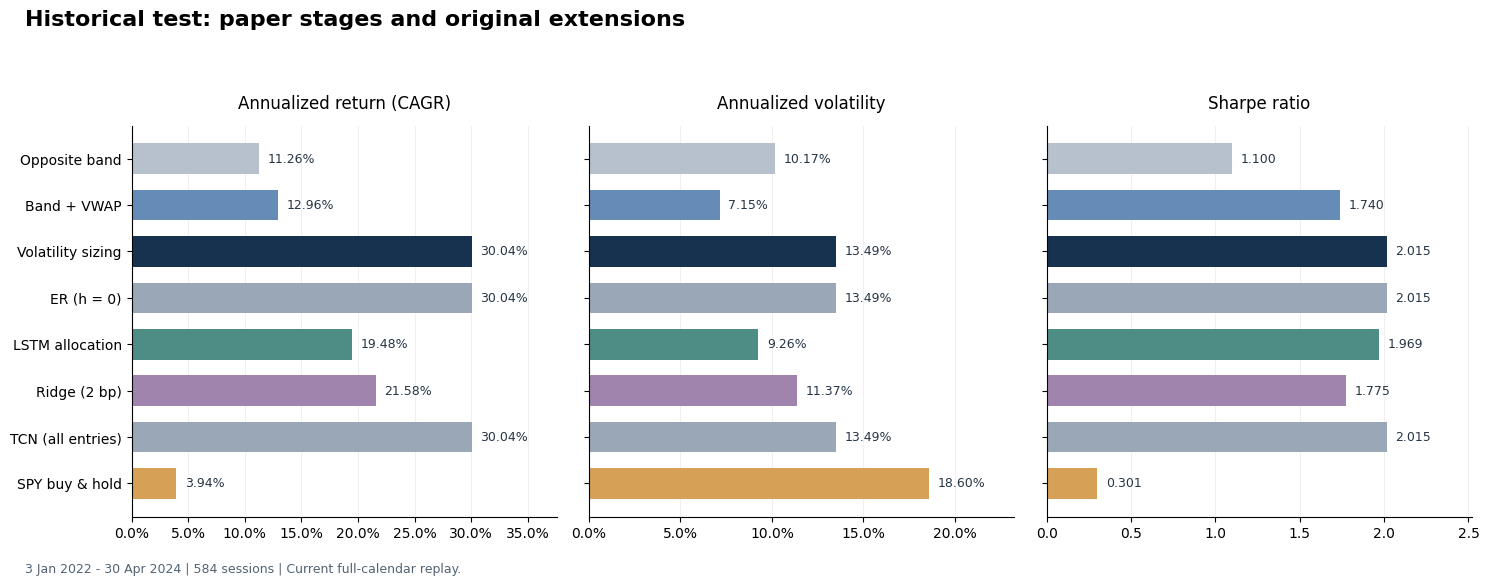

In [64]:

import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

_labels = [
    "Opposite band", "Band + VWAP", "Volatility sizing",
    "ER (h = 0)", "LSTM allocation", "Ridge (2 bp)",
    "TCN (all entries)", "SPY buy & hold",
]
_colors = ["#b7c1ce", "#658cb6", "#16324f", "#99a7b6",
           "#4e8d85", "#a184ad", "#99a7b6", "#d6a057"]
fig, axes = plt.subplots(1, 3, figsize=(15, 5.9), sharey=True)
for ax, metric, title in zip(
    axes, ["annual_return", "annual_volatility", "sharpe"],
    ["Annualized return (CAGR)", "Annualized volatility", "Sharpe ratio"],
):
    values = final_test[metric].to_numpy(float)
    positions = np.arange(len(values))
    ax.barh(positions, values, color=_colors, height=0.66)
    ax.set_yticks(positions, _labels)
    ax.set_title(title, fontsize=12, pad=12)
    ax.grid(axis="x", alpha=0.18)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)
    ax.set_xlim(0, max(values) * 1.25)
    if metric != "sharpe":
        ax.xaxis.set_major_formatter(PercentFormatter(1.0))
    for pos, value in zip(positions, values):
        label = f"{value:.2%}" if metric != "sharpe" else f"{value:.3f}"
        ax.text(value + max(values) * 0.025, pos, label,
                va="center", fontsize=9, color="#263545")
axes[0].invert_yaxis()
fig.suptitle("Historical test: paper stages and original extensions",
             fontsize=16, fontweight="bold", x=0.02, ha="left")
fig.text(0.02, 0.025,
         "3 Jan 2022 - 30 Apr 2024 | 584 sessions | "
         + ("Reported saved statistics; SPY replay not rerun."
            if FINAL_RESULTS_FROM_SNAPSHOT else "Current full-calendar replay."),
         fontsize=9, color="#536373")
fig.tight_layout(rect=(0, 0.055, 1, 0.92))
if "SAVE_OVERVIEW_FIGURE" in globals():
    fig.savefig(SAVE_OVERVIEW_FIGURE, dpi=170, bbox_inches="tight")
plt.show()


### 10.3 What each output establishes

| Output | Connection to the paper or experiment | Interpretation |
|---|---|---|
| Time-dependent upper/lower bounds | Paper Section 3, pp. 6-8 | Prior 14-session mean absolute movement, with gap-aware anchors |
| Opposite-band result | Paper pp. 9-11 | Initial breakout strategy and loose exit |
| Band + VWAP result | Paper pp. 12-14 | Faster exit improves test Sharpe from 1.100 to 1.740 |
| Volatility sizing | Paper pp. 14-15 | Raises test CAGR to 30.04%, alongside higher volatility and drawdown |
| ER, selected h=0 | Original entry-filter experiment | No filtering is selected; the repeated curve is expected |
| LSTM allocation | Original pre-session risk experiment | Average test allocation is 67.41%; test Sharpe is 1.969 |
| Ridge, selected 2 bp | Original linear forecast control | Validation benefit does not carry into higher test Sharpe |
| TCN, selected All entries | Original nonlinear entry filter | The deployed threshold bypasses filtering; it does not prove TCN skill |

The article reports 19.6% annual return and Sharpe 1.33 over May 2007-April 2024 using IQFeed. This notebook's 30.04% and 2.015 describe a shorter Alpaca historical test. They are not a like-for-like claim of outperforming the published strategy.


### 10.4 Saved detailed tables and equity paths

The following original six-strategy aggregation and equity figures are retained with their original code and outputs. ER is covered in Section 7, and the LSTM allocation and constant controls in Section 8. No new daily equity path has been inferred from rounded summary statistics.


#### Paper stages and forecast filters: detailed period table

Original saved aggregation for development, validation and historical test.

In [65]:
# ---------------------------------------------------------
# Compare all original strategies with Ridge and TCN.
# ---------------------------------------------------------

tcn_comparison = comparison_dynamic.copy()
tcn_comparison.index = pd.to_datetime(
    tcn_comparison.index
).normalize()
tcn_comparison = tcn_comparison.sort_index()

for name, result in [
    ("Ridge return filter", ridge_filtered_daily),
    ("TCN return filter", tcn_filtered_daily),
]:
    result = result.copy()
    result.index = pd.to_datetime(result.index).normalize()
    result = result.sort_index()

    if not tcn_comparison.index.equals(result.index):
        raise AssertionError(f"Calendar mismatch: {name}")

    tcn_comparison[name] = result["strategy_return"]

tcn_models = [
    "Opposite band",
    "Band + VWAP",
    "Band + VWAP + Vol target",
    "Ridge return filter",
    "TCN return filter",
    "SPY buy & hold",
]

tcn_periods = {
    "development": (
        tcn_comparison["split"].eq("train")
        & (tcn_comparison.index < TCN_VALIDATION_START)
    ),
    "validation": (
        tcn_comparison["split"].eq("train")
        & (tcn_comparison.index >= TCN_VALIDATION_START)
    ),
    "test": tcn_comparison["split"].eq("test"),
}

# Rebuild the performance table using all six strategies.
records = []

for period, mask in tcn_periods.items():
    for model in tcn_models:
        records.append({
            "period": period,
            "strategy": model,
            **performance_metrics(
                tcn_comparison.loc[mask, model]
            ),
        })

tcn_performance = pd.DataFrame(records).set_index(
    ["period", "strategy"]
)

formatted = tcn_performance.copy()

for col in [
    "total_return", "annual_return",
    "annual_volatility", "max_drawdown",
]:
    formatted[col] = formatted[col].map(
        lambda value: f"{value:.2%}"
    )

formatted["sharpe"] = formatted["sharpe"].map(
    lambda value: f"{value:.3f}"
)

print("\nComplete performance comparison:")
print(formatted.to_string())

# Use wider solid lines for the original strategies.



Complete performance comparison:
                                      days total_return annual_return annual_volatility sharpe max_drawdown
period      strategy                                                                                       
development Opposite band             1220        2.32%         0.47%             8.82%  0.098      -13.02%
            Band + VWAP               1220       13.03%         2.56%             6.80%  0.406      -12.41%
            Band + VWAP + Vol target  1220       51.40%         8.94%            14.30%  0.669      -25.72%
            Ridge return filter       1220      128.03%        18.56%            12.70%  1.403      -12.21%
            TCN return filter         1220       51.40%         8.94%            14.30%  0.669      -25.72%
            SPY buy & hold            1220      111.15%        16.69%            18.26%  0.938      -33.79%
validation  Opposite band              252        6.70%         6.70%             6.61%  1.014       -

#### Original equity panels

TCN and the volatility-sized strategy coincide because the selected operational rule admits all entries. Their overlap is an expected result.

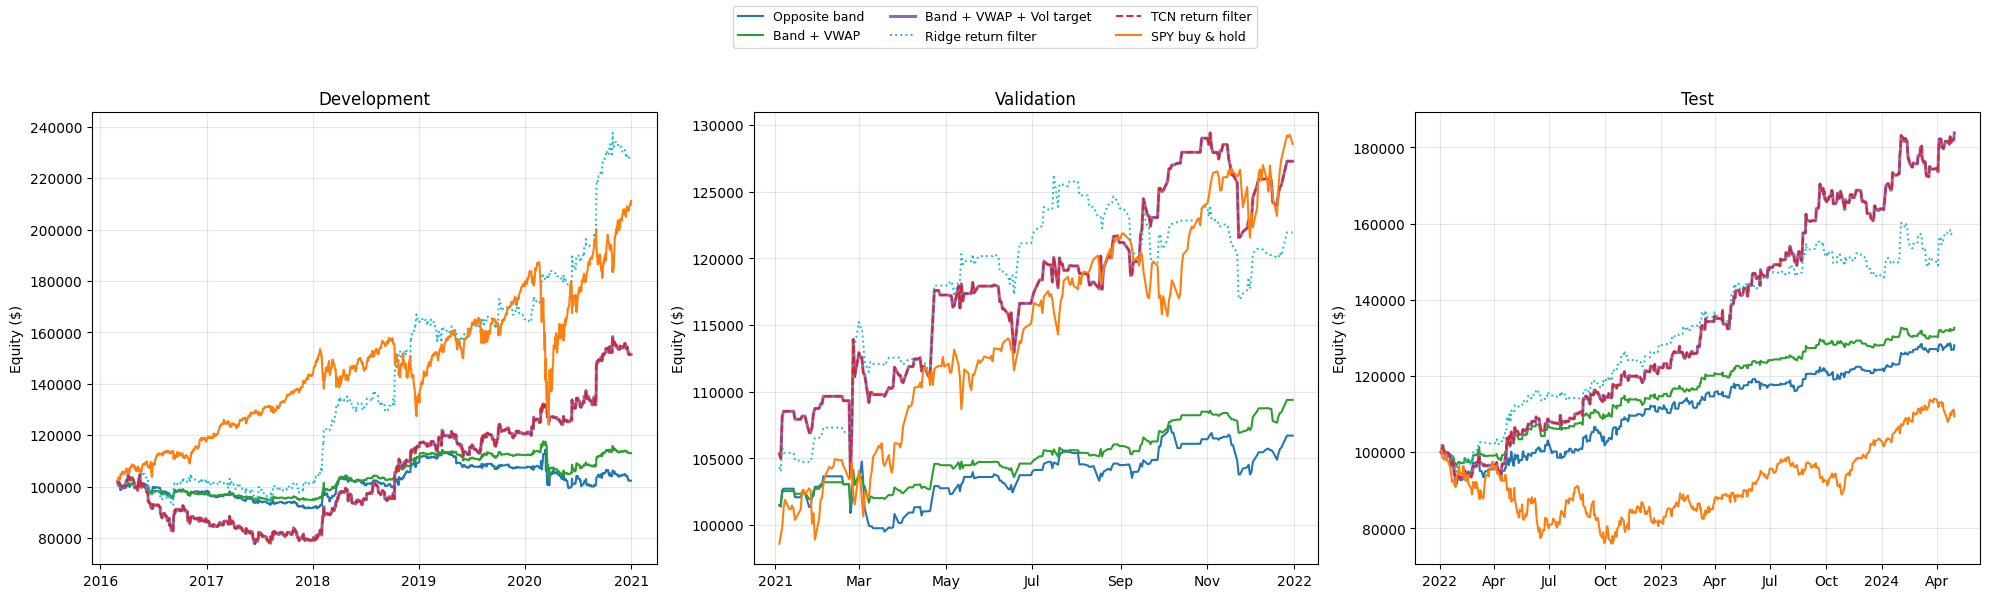


TCN selected threshold: All entries
Ridge selected threshold: 2.0 bp


In [66]:
styles = {
    "Opposite band": ("tab:blue", "-", 1.5),
    "Band + VWAP": ("tab:green", "-", 1.5),
    "Band + VWAP + Vol target": ("tab:purple", "-", 2.2),
    "Ridge return filter": ("tab:cyan", ":", 1.4),
    "TCN return filter": ("tab:red", "--", 1.4),
    "SPY buy & hold": ("tab:orange", "-", 1.5),
}

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, (period, mask) in zip(axes, tcn_periods.items()):
    sample = tcn_comparison.loc[mask]

    for model in tcn_models:
        color, linestyle, linewidth = styles[model]

        curve = (
            INITIAL_CASH * (1 + sample[model]).cumprod()
        )

        ax.plot(
            sample.index,
            curve,
            label=model,
            color=color,
            linestyle=linestyle,
            linewidth=linewidth,
        )

    locator = mdates.AutoDateLocator()
    ax.xaxis.set_major_locator(locator)
    ax.xaxis.set_major_formatter(
        mdates.ConciseDateFormatter(locator)
    )
    ax.set_title(period.capitalize())
    ax.set_ylabel("Equity ($)")
    ax.grid(alpha=0.3)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=3,
    fontsize=9,
)
fig.tight_layout(rect=(0, 0, 1, 0.88))
plt.show()

print(
    "\nTCN selected threshold:",
    "All entries" if tcn_threshold is None
    else f"{tcn_threshold:.1f} bp",
)
print(
    "Ridge selected threshold:",
    "All entries" if ridge_threshold is None
    else f"{ridge_threshold:.1f} bp",
)

## 11. Pending experiments: persistence and intraday risk control

**Status: not executed on the full SPY dataset in the supplied notebook.** This section is an implementation and experimental design. No performance advantage is claimed. The saved results in Section 10 belong to the preceding experiments.

### 11.1 Features, information timing and historical realized variance

**Research hypotheses.** Brief boundary breaches may be false breakouts. A daily volatility estimate based on the preceding 14 sessions may also react too slowly to an unusual intraday volatility increase. This section defines two original variations to test those weaknesses. Neither variation is claimed to be a rule from the paper.

The existing noise boundaries, HLC3-based session VWAP and lagged daily volatility estimate are reused. The full exchange calendar, including warm-up sessions, is retained.

**Breakout persistence.** Define a minute-level side as +1 when the completed close is above both the upper boundary and the contemporaneous VWAP, -1 when it is below both the lower boundary and VWAP, and 0 otherwise. A new long entry requires the preceding $m$ consecutive completed minutes to satisfy

$$
C_{t,\tau-j}>\max(UB_{t,\tau-j},VWAP_{t,\tau-j}),\qquad j=0,\ldots,m-1.
$$

The short condition is symmetric. Each minute uses its own boundary and its own then-available VWAP. Consecutive confirmation cannot cross a missing minute or a session boundary.

**Intraday realized variance.** Exclude overnight returns by starting at the actual session open:

$$
r_{t,1}=\log(C_{t,1}/O_t),\qquad r_{t,k}=\log(C_{t,k}/C_{t,k-1})\quad(k>1).
$$

$$
RV_{t,\tau}=\sum_{k=1}^{\tau}r_{t,k}^{2},\qquad
H_{t,\tau}=\mathrm{median}\{RV_{t-14,\tau},\ldots,RV_{t-1,\tau}\}.
$$

The reference uses the same elapsed minute in each of the previous 14 scheduled trading sessions. Shift the date panel before computing the rolling median. Require all 14 observations; unavailable or nonpositive references leave the risk multiplier at 1 rather than silently shortening the lookback.

**Causal missing-data policy.** Reindex each session to its scheduled minute grid without filling prices. Earlier trades remain valid if a later minute is missing. After the first missing/invalid minute is detected at its scheduled end, stop new trading for that session and liquidate at the first subsequent available minute open, or the closing price if that is the next usable terminal reference. A position with no usable liquidation price raises an error. Do not invent a fill. Realized variance becomes unavailable from the first invalid minute onward.

This is a historical data-handling convention, not evidence that a live order would obtain the reference price.

In [67]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
try:
    from IPython.display import display
except ImportError:
    def display(value):
        print(value.to_string() if hasattr(value, "to_string") else value)

required = [
    "features_vwap", "cal_sizing", "sigma_daily",
    "vol_target_daily", "comparison_dynamic", "performance_metrics",
    "INITIAL_CASH", "COMMISSION_PER_SHARE", "SLIPPAGE_PER_SHARE",
    "VOL_TARGET_DAILY", "MAX_LEVERAGE",
]
missing = [x for x in required if x not in globals()]
if missing:
    raise RuntimeError("Run the original volatility-target strategy cells first: " + ", ".join(missing))

UP_VALIDATION_START = pd.Timestamp("2021-01-01")
UP_CONFIRM_CANDIDATES = (1, 3, 5)
UP_RV_LOOKBACK = 14
UP_MIN_ACTIVE_DAYS = 20

up_cal = cal_sizing.copy()
up_cal["date"] = pd.to_datetime(up_cal["date"]).dt.normalize()
for col in ["market_open", "market_close"]:
    up_cal[col] = pd.to_datetime(up_cal[col], utc=True)
up_cal = up_cal.sort_values("date").reset_index(drop=True)
if up_cal["date"].duplicated().any():
    raise ValueError("Duplicate dates in the trading calendar.")

up_features = features_vwap.copy()
up_features["date"] = pd.to_datetime(up_features["date"]).dt.normalize()
up_features["bar_end_ny"] = pd.to_datetime(up_features["bar_end_ny"], utc=True)
if up_features["bar_end_ny"].duplicated().any():
    raise ValueError("Duplicate minute timestamps.")

up_groups = {
    d: g.set_index("bar_end_ny").sort_index()
    for d, g in up_features.groupby("date", sort=False)
}
up_dates = pd.DatetimeIndex(up_cal["date"], name="date")
up_eval_dates = pd.DatetimeIndex(
    up_cal.loc[up_cal["split"].isin(["train", "test"]), "date"]
)
up_max_minutes = int(up_cal["expected_minutes"].max())
up_rv_panel = pd.DataFrame(
    np.nan, index=up_dates, columns=np.arange(up_max_minutes)
)
up_cache = {}

for session in up_cal.itertuples(index=False):
    n = int(session.expected_minutes)
    ends = pd.date_range(
        session.market_open + pd.Timedelta(minutes=1),
        periods=n, freq="min",
    )
    if ends[-1] != session.market_close:
        raise ValueError("Scheduled minute count does not match the session close.")

    grid = up_groups.get(session.date, up_features.iloc[:0].set_index(
        "bar_end_ny"
    )).reindex(ends)

    o = grid["open"].to_numpy(float)
    c = grid["close"].to_numpy(float)
    ub = grid["upper_bound"].to_numpy(float)
    lb = grid["lower_bound"].to_numpy(float)
    vw = grid["vwap"].to_numpy(float)

    price_ok = np.isfinite(o) & np.isfinite(c) & (o > 0) & (c > 0)
    prefix_ok = np.logical_and.accumulate(price_ok)
    bad = np.flatnonzero(~price_ok)
    first_bad = int(bad[0]) if len(bad) else n

    signal_ok = (
        price_ok & np.isfinite(ub) & np.isfinite(lb) & (ub >= lb)
        & np.isfinite(vw) & (vw > 0)
    )
    side = np.zeros(n, dtype=int)
    side[signal_ok & (c > ub) & (c > vw)] = 1
    side[signal_ok & (c < lb) & (c < vw)] = -1

    # Reindex the minute grid; confirmation cannot cross gaps or sessions.
    streak = np.zeros(n, dtype=int)
    for k in range(n):
        if side[k] != 0:
            streak[k] = (
                streak[k - 1] + 1
                if k > 0 and side[k] == side[k - 1] else 1
            )

    # The first return runs from the session open to the first close; exclude overnight returns.
    with np.errstate(divide="ignore", invalid="ignore"):
        log_returns = np.diff(np.log(np.r_[o[0], c]))
    rv = np.cumsum(np.where(np.isfinite(log_returns), log_returns ** 2, 0.0))
    rv[~prefix_ok] = np.nan
    up_rv_panel.loc[session.date, np.arange(n)] = rv

    local_ends = ends.tz_convert("America/New_York")
    scheduled = np.isin(local_ends.minute, [0, 30]) & (ends < session.market_close)
    idx = np.flatnonzero(scheduled & prefix_ok)

    # The first missing/invalid bar is detected at its scheduled end.
    # Retain earlier signals and liquidate at the next available opening price.
    terminal_price = c[-1]
    terminal_time = session.market_close
    if first_bad < n:
        later = np.flatnonzero(
            (np.arange(n) > first_bad) & np.isfinite(o) & (o > 0)
        )
        if len(later):
            k = int(later[0])
            terminal_price = o[k]
            terminal_time = ends[k] - pd.Timedelta(minutes=1)

    up_cache[session.date] = {
        "split": session.split,
        "complete": bool(price_ok.all()),
        "status": (
            "halted_missing_prices" if first_bad < n else
            "partial_bounds" if (~signal_ok[idx]).any() else "complete"
        ),
        "missing_signal_points": int((~signal_ok[idx]).sum()),
        "day_open": o[0],
        "idx": idx,
        "side": side[idx],
        "streak": streak[idx],
        "references": np.r_[o[idx + 1], terminal_price],
        "times": list(ends[idx]) + [terminal_time],
        "rv": rv[idx],
    }

# Shift before rolling: exclude the current session from its historical reference.
up_rv_history = up_rv_panel.shift(1).rolling(
    UP_RV_LOOKBACK, min_periods=UP_RV_LOOKBACK
).median()

for date, info in up_cache.items():
    history = up_rv_history.loc[date].to_numpy(float)[info["idx"]]
    current = info["rv"]
    available = (
        np.isfinite(history) & (history > 0)
        & np.isfinite(current) & (current > 0)
    )
    multiplier = np.ones(len(current))
    multiplier[available] = np.minimum(
        1.0, np.sqrt(history[available] / current[available])
    )
    info["risk_multiplier"] = multiplier
    info["rv_available"] = available

up_period_dates = {
    "development": pd.DatetimeIndex(up_cal.loc[
        up_cal["split"].eq("train")
        & up_cal["date"].lt(UP_VALIDATION_START), "date"
    ]),
    "validation": pd.DatetimeIndex(up_cal.loc[
        up_cal["split"].eq("train")
        & up_cal["date"].ge(UP_VALIDATION_START), "date"
    ]),
    "test": pd.DatetimeIndex(up_cal.loc[
        up_cal["split"].eq("test"), "date"
    ]),
}
if any(len(x) == 0 for x in up_period_dates.values()):
    raise ValueError("Empty development, validation or test period; check the date split.")

print("Sessions by period:", {k: len(v) for k, v in up_period_dates.items()})
print("Evaluation sessions with incomplete prices:", sum(
    not up_cache[d]["complete"] for d in up_eval_dates
))


Sessions by period: {'development': 1220, 'validation': 252, 'test': 584}
Evaluation sessions with incomplete prices: 7


### 11.2 Unified replay, entry confirmation and intraday share sizing

**Retained baseline.** Keep the existing band/VWAP target direction, half-hour decisions, next-minute-open execution references, integer shares and end-of-session liquidation. The new feature calculations do not add off-schedule signal decisions; a data-gap liquidation is a separate data-handling exception.

The original daily sizing rule is

$$
\ell_t=\min\left(\ell_{\max},\frac{\sigma_{\mathrm{target}}}{\widehat{\sigma}_{t-1}}\right).
$$

Here $\widehat{\sigma}_{t-1}$ estimates historical SPY daily risk. The target is not a guarantee that the strategy portfolio realizes 2% daily volatility.

**Confirmation only gates a new side.** Apply the persistence requirement when opening from flat or reversing into a new direction. Retain the original exits without extra confirmation. A rejected reversal closes the old position but does not open the rejected side. An unchanged same-side position is not closed solely because its persistence count falls below $m$.

**Intraday risk multiplier.**

$$
g_{t,\tau}=\min\left(1,\sqrt{H_{t,\tau}/RV_{t,\tau}}\right).
$$

$$
Q_{t,\tau}=\left\lfloor\frac{E_{t-1}\ell_tg_{t,\tau}}{O_t}\right\rfloor,\qquad
q_{t,\tau}=s_{t,\tau}Q_{t,\tau}.
$$

Reuse session-start equity and the opening price to isolate the sizing modification. Update the multiplier only at the existing decision times. It may recover toward 1 as the relative volatility changes, but it never increases planned exposure above the original budget. Missing/zero historical references use $g=1$; report reference availability.

Every share adjustment incurs costs:

$$
\mathrm{Cost}_{t,j}=|\Delta q_{t,j}|(c+\delta).
$$

A reversal includes both closing and opening shares. Financing, borrow charges and size-dependent market impact remain unmodeled.

**Two replay modes.** Use $\texttt{legacy}$ only to verify the old whole-session data-quality convention. All formal extension comparisons use $\texttt{causal}$. Thus the new A baseline retains the original trading logic, while its incomplete-session handling can differ from the previously saved baseline.

In [68]:
def backtest_upgrade(
    confirm_minutes=1, shock_control=False, dates=None,
    cost_multiplier=1.0, missing_policy="causal", fixed_scale=1.0,
):
    if not isinstance(confirm_minutes, (int, np.integer)) or confirm_minutes < 1:
        raise ValueError("confirm_minutes must be a positive integer.")
    if missing_policy not in {"causal", "legacy"}:
        raise ValueError("missing_policy must be causal or legacy.")
    if not np.isfinite(cost_multiplier) or cost_multiplier < 0:
        raise ValueError("cost_multiplier must be finite and nonnegative.")
    if not np.isfinite(fixed_scale) or not 0 < fixed_scale <= 1:
        raise ValueError("fixed_scale must lie in (0, 1].")

    selected = up_eval_dates if dates is None else pd.DatetimeIndex(
        pd.to_datetime(dates)
    ).normalize().sort_values()
    if len(selected) == 0 or selected.has_duplicates:
        raise ValueError("Backtest dates are empty or duplicated.")
    if not selected.isin(up_eval_dates).all():
        raise ValueError("Backtest dates must belong to the original train/test calendar.")

    equity = float(INITIAL_CASH)
    daily_rows, order_rows = [], []
    commission = COMMISSION_PER_SHARE * cost_multiplier
    slippage = SLIPPAGE_PER_SHARE * cost_multiplier

    for date in selected:
        info = up_cache[date]
        start = equity
        sigma = float(sigma_daily.get(date, np.nan))
        leverage = (
            min(MAX_LEVERAGE, VOL_TARGET_DAILY / sigma)
            if np.isfinite(sigma) and sigma > 0 else 0.0
        )
        status = info["status"]
        active = (
            leverage > 0
            and np.isfinite(info["day_open"]) and info["day_open"] > 0
            and not (missing_policy == "legacy" and not info["complete"])
        )
        if missing_policy == "legacy" and not info["complete"]:
            status = "incomplete_prices"
        if leverage == 0:
            status = "missing_volatility"

        attempts = rejected = unfilled = 0
        gross = fee = slip = 0.0
        order_count = traded_shares = 0
        mean_multiplier = np.nan

        if active:
            factors = (
                info["risk_multiplier"] if shock_control
                else np.ones(len(info["side"]))
            ) * fixed_scale
            mean_multiplier = float(factors.mean()) if len(factors) else np.nan

            held = 0
            targets = []
            for j, desired in enumerate(info["side"]):
                desired = int(desired)
                new_side = desired != 0 and desired != int(np.sign(held))
                if new_side:
                    attempts += 1
                    if info["streak"][j] < confirm_minutes:
                        desired = 0
                        rejected += 1

                quantity = int(np.floor(
                    start * leverage * factors[j] / info["day_open"]
                ))
                target = desired * quantity

                # Do not assume execution when the next opening reference is unavailable.
                reference = info["references"][j]
                if target != held and (
                    not np.isfinite(reference) or reference <= 0
                ):
                    target = held
                    unfilled += 1

                held = target
                targets.append(target)

            terminal = info["references"][-1]
            if held != 0 and (not np.isfinite(terminal) or terminal <= 0):
                raise RuntimeError(
                    f"{date.date()} has an open position but no usable liquidation price. "
                    "Resolve the data gap; do not finish the backtest at an invented price."
                )

            targets = np.r_[targets, 0].astype(np.int64)
            changes = np.diff(np.r_[0, targets])
            nonzero = np.flatnonzero(changes)

            gross = -float(np.dot(
                changes[nonzero], info["references"][nonzero]
            ))
            traded_shares = int(np.abs(changes).sum())
            fee = traded_shares * commission
            slip = traded_shares * slippage
            order_count = len(nonzero)

            for j in nonzero:
                change = int(changes[j])
                reference = float(info["references"][j])
                terminal_event = j == len(targets) - 1
                order_rows.append({
                    "date": date, "execution_time": info["times"][j],
                    "shares_change": change,
                    "reference_price": reference,
                    "fill_price": reference + np.sign(change) * slippage,
                    "commission": abs(change) * commission,
                    "slippage": abs(change) * slippage,
                    "position_after": int(targets[j]),
                    "reason": (
                        ("market_close" if info["complete"] else "data_gap_exit")
                        if terminal_event else "signal_or_resize"
                    ),
                })

        net = gross - fee - slip
        equity = start + net
        if not np.isfinite(equity) or equity <= 0:
            raise RuntimeError(f"{date.date()} portfolio equity is nonpositive or invalid.")

        daily_rows.append({
            "date": date, "split": info["split"],
            "equity_start": start, "equity_end": equity,
            "strategy_return": net / start,
            "gross_pnl": gross, "commission": fee, "slippage": slip,
            "net_pnl": net, "orders": order_count,
            "traded_shares": traded_shares,
            "entry_attempts": attempts, "rejected_entries": rejected,
            "unfilled_signals": unfilled,
            "base_leverage": leverage,
            "mean_risk_multiplier": mean_multiplier,
            "rv_available_points": int(info["rv_available"].sum()),
            "decision_points": len(info["idx"]),
            "missing_signal_points": info["missing_signal_points"],
            "status": status,
        })

    return (
        pd.DataFrame(daily_rows).set_index("date"),
        pd.DataFrame(order_rows),
    )


### 11.3 Baseline identity check and validation-only parameter selection

**Identity check.** With $m=1$, shock control disabled, fixed scale 1 and legacy data handling, the new engine must reproduce the saved original volatility-target replay. Compare the common calendar, equity, gross PnL, commissions, slippage, net PnL and daily net returns. Resolve an assertion failure before attributing any performance difference to the extension.

**Small predefined grid.**

$$
m\in\{1,3,5\}.
$$

Use the original training sessions from 2021 onward as validation; earlier training sessions are development. Select the finite validation Sharpe with at least 20 active sessions. Break ties in favor of the smaller $m$. The candidate $m=1$ allows validation to retain the original entry rule. The shock-control formula and 14-session lookback are predefined rather than selected on test results.

Each validation candidate starts with the same initial capital. The subsequent full-history comparison compounds continuously, so period-specific integer rounding need not reproduce the standalone validation replay exactly.

**Constant-risk control.** Estimate the mean decision-point shock multiplier using development sessions only, then freeze that value. Apply it to the original entry rule throughout the full replay. This is a simple lower-exposure control, not exact realized-volatility or trade-weighted exposure matching.

**Research status.** The historical test period has already been inspected in earlier experiments. These additions are exploratory historical-test comparisons, not a newly untouched out-of-sample test. Do not revise the grid or choose another threshold after seeing test results.

In [69]:
# Use legacy only for the identity check; use causal for the extension experiment.
up_legacy_check, _ = backtest_upgrade(missing_policy="legacy")
up_previous = vol_target_daily.copy()
up_previous.index = pd.to_datetime(up_previous.index).normalize()
up_previous = up_previous.sort_index()
if not up_legacy_check.index.equals(up_previous.index):
    raise AssertionError("The original strategy and the new engine use different calendars.")

for col in [
    "equity_start", "equity_end", "gross_pnl",
    "commission", "slippage", "net_pnl", "strategy_return",
]:
    np.testing.assert_allclose(
        up_legacy_check[col], up_previous[col],
        rtol=1e-8, atol=1e-8, err_msg=f"Original-strategy identity check failed: {col}",
    )
print("Original-strategy identity check passed with extensions disabled and legacy data handling.")

up_selection_rows = []
for m in UP_CONFIRM_CANDIDATES:
    result, _ = backtest_upgrade(
        confirm_minutes=m, dates=up_period_dates["validation"]
    )
    up_selection_rows.append({
        "confirm_minutes": m,
        **performance_metrics(result["strategy_return"]),
        "active_days": int(result["orders"].gt(0).sum()),
        "rejected_entries": int(result["rejected_entries"].sum()),
    })

up_selection = pd.DataFrame(up_selection_rows)
eligible = up_selection.loc[
    np.isfinite(up_selection["sharpe"])
    & up_selection["active_days"].ge(UP_MIN_ACTIVE_DAYS)
]
if eligible.empty:
    raise RuntimeError("Too few active validation sessions; stop parameter selection.")

UP_SELECTED_M = int(eligible.sort_values(
    ["sharpe", "confirm_minutes"], ascending=[False, True]
).iloc[0]["confirm_minutes"])

display(up_selection.round(4))
print("Frozen confirmation window:", UP_SELECTED_M)
if UP_SELECTED_M == 1:
    print("Validation selects the original entry rule; persistence filtering has no validation support.")

# Estimate the constant-risk control on development data only, then freeze it.
up_development_shock, _ = backtest_upgrade(
    shock_control=True, dates=up_period_dates["development"]
)
up_constant_scale = float(
    up_development_shock["mean_risk_multiplier"].mean()
)
if not np.isfinite(up_constant_scale) or not 0 < up_constant_scale <= 1:
    raise RuntimeError("Cannot estimate a valid constant-risk multiplier from development data.")
print("Frozen constant-risk multiplier:", round(up_constant_scale, 4))


Original-strategy identity check passed with extensions disabled and legacy data handling.


,confirm_minutes,days,total_return,annual_return,annual_volatility,sharpe,max_drawdown,active_days,rejected_entries
0,1,252,0.2727,0.2727,0.1531,1.6520,-0.0606,144,0
1,3,252,0.1498,0.1498,0.1491,1.0104,-0.0780,138,39
2,5,252,0.1886,0.1886,0.1405,1.2993,-0.0780,134,59


Frozen confirmation window: 1
Validation selects the original entry rule; persistence filtering has no validation support.
Frozen constant-risk multiplier: 0.8931


### 11.4 Ablation study and common-calendar statistics

| Version | Entry rule | Share-sizing rule |
|---|---|---|
| A Original | Original band/VWAP rule | Original daily volatility target |
| B Confirmation | Validation-selected persistence | Original daily volatility target |
| C Shock control | Original band/VWAP rule | Intraday shock multiplier |
| D Combined | Selected persistence | Intraday shock multiplier |
| E Constant risk | Original band/VWAP rule | Frozen development-period constant |
| SPY buy & hold | Passive benchmark | Existing adjusted daily returns |

All active versions use the same causal missing-data policy, calendar, execution assumptions and per-share costs. Rerun A under that common policy; do not attribute changes relative to the old incomplete-session baseline to the new signal.

Use the existing zero-risk-free-rate metrics on daily net returns:

$$
W_N=\prod_{t=1}^{N}(1+R_t),\qquad
\mathrm{CAGR}=W_N^{252/N}-1.
$$

$$
\sigma_{\mathrm{annual}}=\mathrm{std}(R_t)\sqrt{252},\qquad
\mathrm{Sharpe}=\frac{\mathrm{mean}(R_t)}{\mathrm{std}(R_t)}\sqrt{252}.
$$

Include initial wealth in maximum drawdown and retain cash sessions. Report active days, order counts, traded shares, rejected entries, unavailable execution references and costs alongside the performance metrics.

$\texttt{cost\_return\_sum}$ is the sum of each day's costs divided by session-start equity. It is not costs divided by profits. The mean risk multiplier is an unweighted decision-point diagnostic, not actual average portfolio leverage.

**Interpretation.** B versus A isolates confirmation; C versus A examines dynamic sizing; C versus E checks whether dynamic adjustment adds value beyond simple de-risking; D versus B and C examines the combination. The existing passive benchmark has adjusted returns but no simulated trading fees.

In [70]:
up_specs = {
    "A Original": {},
    "B Confirmation": {"confirm_minutes": UP_SELECTED_M},
    "C Shock control": {"shock_control": True},
    "D Combined": {
        "confirm_minutes": UP_SELECTED_M, "shock_control": True
    },
    "E Constant risk": {"fixed_scale": up_constant_scale},
}
up_results, up_orders = {}, {}
for name, spec in up_specs.items():
    up_results[name], up_orders[name] = backtest_upgrade(**spec)

up_comparison = pd.DataFrame(index=up_eval_dates)
for name, result in up_results.items():
    if not result.index.equals(up_eval_dates):
        raise AssertionError(f"Calendar mismatch: {name}")
    up_comparison[name] = result["strategy_return"]

up_bh = comparison_dynamic.copy()
up_bh.index = pd.to_datetime(up_bh.index).normalize()
up_comparison["SPY buy & hold"] = up_bh["SPY buy & hold"].reindex(up_eval_dates)
if not np.isfinite(up_comparison.to_numpy(float)).all():
    raise ValueError("The comparison table contains missing or invalid returns.")

up_metric_rows, up_activity_rows = [], []
for period, dates in up_period_dates.items():
    for name in up_comparison:
        up_metric_rows.append({
            "period": period, "strategy": name,
            **performance_metrics(up_comparison.loc[dates, name]),
        })
    for name, result in up_results.items():
        sample = result.loc[dates]
        up_activity_rows.append({
            "period": period, "strategy": name,
            "active_days": int(sample["orders"].gt(0).sum()),
            "orders": int(sample["orders"].sum()),
            "traded_shares": int(sample["traded_shares"].sum()),
            "entry_attempts": int(sample["entry_attempts"].sum()),
            "rejected_entries": int(sample["rejected_entries"].sum()),
            "unfilled_signals": int(sample["unfilled_signals"].sum()),
            "rv_available_points": int(sample["rv_available_points"].sum()),
            "decision_points": int(sample["decision_points"].sum()),
            "cost_dollars": float(
                (sample["commission"] + sample["slippage"]).sum()
            ),
            "cost_return_sum": float((
                (sample["commission"] + sample["slippage"])
                / sample["equity_start"]
            ).sum()),
            "mean_risk_multiplier": sample["mean_risk_multiplier"].mean(),
        })

up_metrics = pd.DataFrame(up_metric_rows).set_index(["period", "strategy"])
up_activity = pd.DataFrame(up_activity_rows).set_index(["period", "strategy"])
formatted = up_metrics.copy()
for col in ["total_return", "annual_return", "annual_volatility", "max_drawdown"]:
    formatted[col] = formatted[col].map(lambda x: f"{x:.2%}")
formatted["sharpe"] = formatted["sharpe"].map(lambda x: f"{x:.3f}")

display(formatted)
display(up_activity.round(4))
print("All active strategies use the same causal missing-data policy.")
print("The mean multiplier is a decision-point diagnostic, not realized average leverage or exact risk matching.")


days total_return annual_return  \
period      strategy                                           
development A Original       1220       51.85%         9.01%   
            B Confirmation   1220       51.85%         9.01%   
            C Shock control  1220       31.91%         5.89%   
            D Combined       1220       31.91%         5.89%   
            E Constant risk  1220       45.88%         8.11%   
            SPY buy & hold   1220      111.15%        16.69%   
validation  A Original        252       27.29%        27.29%   
            B Confirmation    252       27.29%        27.29%   
            C Shock control   252       24.99%        24.99%   
            D Combined        252       24.99%        24.99%   
            E Constant risk   252       24.19%        24.19%   
            SPY buy & hold    252       28.60%        28.60%   
test        A Original        584       83.81%        30.04%   
            B Confirmation    584       83.81%        30.04%   
            C Shock control   584       79.20%        28.62%   
            D Combined        584       79.20%        28.62%   
            E Constant risk   584       72.56%        26.54%   
            SPY buy & hold    584        9.37%         3.94%   

                            annual_volatility sharpe max_drawdown  
period      strategy                                               
development A Original                 14.30%  0.674      -25.72%  
            B Confirmation             14.30%  0.674      -25.72%  
            C Shock control            10.23%  0.610      -21.54%  
            D Combined                 10.23%  0.610      -21.54%  
            E Constant risk            12.77%  0.674      -23.23%  
            SPY buy & hold             18.26%  0.938      -33.79%  
validation  A Original                 15.31%  1.653       -6.06%  
            B Confirmation             15.31%  1.653       -6.06%  
            C Shock control             9.84%  2.316       -4.61%  
            D Combined                  9.84%  2.316       -4.61%  
            E Constant risk            13.67%  1.653       -5.42%  
            SPY buy & hold             12.96%  2.007       -5.11%  
test        A Original                 13.49%  2.015       -9.95%  
            B Confirmation             13.49%  2.015       -9.95%  
            C Shock control            11.29%  2.287       -6.24%  
            D Combined                 11.29%  2.287       -6.24%  
            E Constant risk            12.05%  2.015       -8.92%  
            SPY buy & hold             18.60%  0.301      -24.50%

active_days  orders  traded_shares  \
period      strategy                                              
development A Original               709    2054        2316144   
            B Confirmation           709    2054        2316144   
            C Shock control          709    3587        2012490   
            D Combined               709    3587        2012490   
            E Constant risk          709    2054        2073490   
validation  A Original               144     419         512988   
            B Confirmation           144     419         512988   
            C Shock control          144     790         356722   
            D Combined               144     790         356722   
            E Constant risk          144     419         432830   
test        A Original               365    1082        1436096   
            B Confirmation           365    1082        1436096   
            C Shock control          365    1843        1096508   
            D Combined               365    1843        1096508   
            E Constant risk          365    1082        1158830   

                             entry_attempts  rejected_entries  \
period      strategy                                            
development A Original                 1028                 0   
            B Confirmation             1028                 0   
            C Shock control            1028                 0   
            D Combined                 1028                 0   
            E Constant risk            1028                 0   
validation  A Original                  210                 0   
            B Confirmation              210                 0   
            C Shock control             210                 0   
            D Combined                  210                 0   
            E Constant risk             210                 0   
test        A Original                  541                 0   
            B Confirmation              541                 0   
            C Shock control             541                 0   
            D Combined                  541                 0   
            E Constant risk             541                 0   

                             unfilled_signals  rv_available_points  \
period      strategy                                                 
development A Original                      0                13587   
            B Confirmation                  0                13587   
            C Shock control                 0                13587   
            D Combined                      0                13587   
            E Constant risk                 0                13587   
validation  A Original                      0                 2763   
            B Confirmation                  0                 2763   
            C Shock control                 0                 2763   
            D Combined                      0                 2763   
            E Constant risk                 0                 2763   
test        A Original                      0                 6600   
            B Confirmation                  0                 6600   
            C Shock control                 0                 6600   
            D Combined                      0                 6600   
            E Constant risk                 0                 6600   

                             decision_points  cost_dollars  cost_return_sum  \
period      strategy                                                          
development A Original                 14531     10422.648           0.1062   
            B Confirmation             14531     10422.648           0.1062   
            C Shock control            14531      9056.205           0.0920   
            D Combined                 14531      9056.205           0.0920   
            E Constant risk            14531      9330.705           0.0948   
validation  A Original                 

All active strategies use the same causal missing-data policy.
The mean multiplier is a decision-point diagnostic, not realized average leverage or exact risk matching.


### 11.5 Equity curves and historical-test metric comparison

Display development, validation and historical-test equity curves with each panel rebased to 1. Always include the original A strategy and passive SPY. Underlying active replay equity remains continuous across the full evaluation history; rebasing changes the display only.

The second figure compares historical-test CAGR, annual volatility and Sharpe. Maximum drawdown remains available in the statistics table. Also report metric changes relative to A.

If validation selects $m=1$, B coincides with A and D coincides with C. These overlapping curves are expected evidence that persistence filtering was not selected, rather than a plotting failure.

Lower drawdown alone does not establish a better signal. Examine risk-adjusted performance, return, activity and the constant-risk control together. Maximum drawdown is negative, so a positive change relative to A ordinarily means a smaller drawdown.

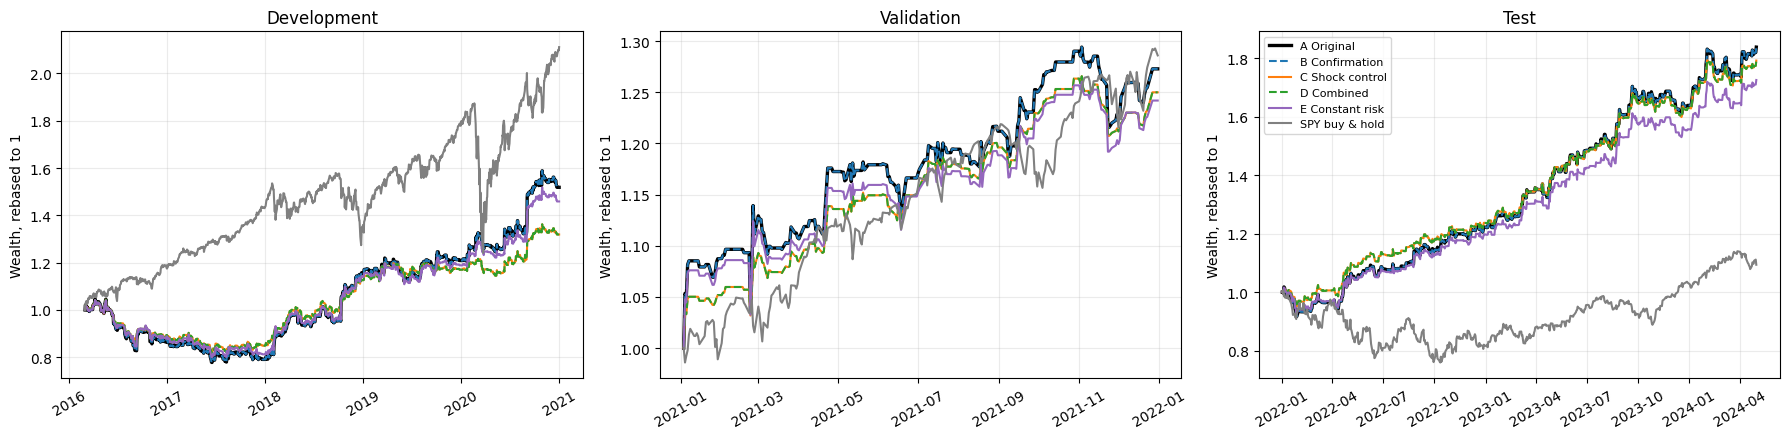

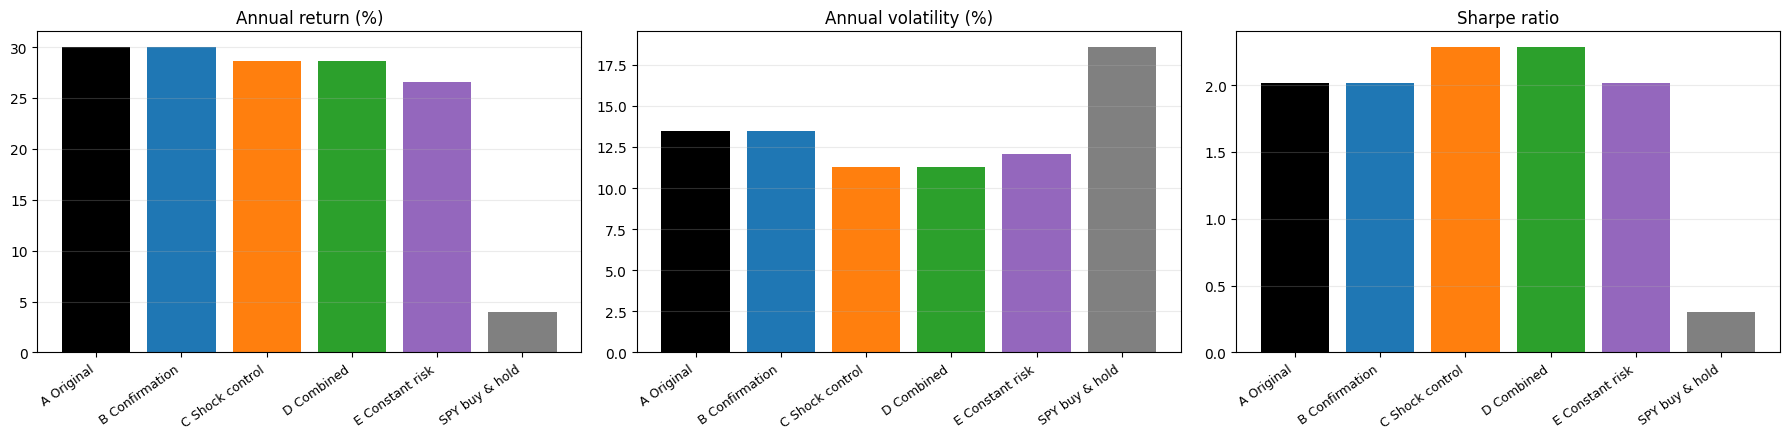

Test-period metric changes relative to the original strategy:


,annual_return,annual_volatility,sharpe,max_drawdown
strategy,,,,
A Original,0.0000,0.0000,0.0000,0.0000
B Confirmation,0.0000,0.0000,0.0000,0.0000
C Shock control,-0.0142,-0.0220,0.2719,0.0371
D Combined,-0.0142,-0.0220,0.2719,0.0371
E Constant risk,-0.0350,-0.0144,-0.0003,0.0103


In [71]:
up_colors = {
    "A Original": "black", "B Confirmation": "tab:blue",
    "C Shock control": "tab:orange", "D Combined": "tab:green",
    "E Constant risk": "tab:purple", "SPY buy & hold": "gray",
}

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
for ax, (period, dates) in zip(axes, up_period_dates.items()):
    for name in up_comparison:
        returns = up_comparison.loc[dates, name].to_numpy()
        x = [dates[0] - pd.Timedelta(days=1)] + list(dates)
        wealth = np.r_[1.0, np.cumprod(1.0 + returns)]
        ax.plot(
            x, wealth, label=name, color=up_colors[name],
            linewidth=2.4 if name == "A Original" else 1.5,
            linestyle="--" if name in ["B Confirmation", "D Combined"] else "-",
        )
    ax.set_title(period.capitalize())
    ax.set_ylabel("Wealth, rebased to 1")
    ax.grid(alpha=0.25)
    ax.tick_params(axis="x", rotation=30)
axes[-1].legend(fontsize=8)
fig.tight_layout()
plt.show()

up_test_metrics = up_metrics.xs("test", level="period")
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
for ax, metric, title in zip(
    axes, ["annual_return", "annual_volatility", "sharpe"],
    ["Annual return", "Annual volatility", "Sharpe ratio"],
):
    values = up_test_metrics[metric].copy()
    if metric != "sharpe":
        values *= 100
    ax.bar(
        np.arange(len(values)), values,
        color=[up_colors[x] for x in values.index],
    )
    ax.set_xticks(np.arange(len(values)))
    ax.set_xticklabels(values.index, rotation=35, ha="right", fontsize=9)
    ax.set_title(title + (" (%)" if metric != "sharpe" else ""))
    ax.grid(axis="y", alpha=0.25)
fig.tight_layout()
plt.show()

print("Test-period metric changes relative to the original strategy:")
display(up_test_metrics.loc[list(up_specs)].subtract(
    up_test_metrics.loc["A Original"], axis="columns"
)[["annual_return", "annual_volatility", "sharpe", "max_drawdown"]].round(4))


### 11.6 Frozen-parameter transaction-cost stress test

Predefine three commission/slippage scenarios:

$$
k\in\{1,2,5\},\qquad c_k=kc,\qquad \delta_k=k\delta.
$$

Apply the same multiplier to every active version. Keep the selected confirmation window and development-only constant-risk coefficient frozen. Recalculate the full equity path and integer shares for each cost scenario, then report historical-test metrics.

This is a simplified cost stress test, not a calibrated spread/impact model. It does not reproduce the paper's live execution experiment or add financing and borrow costs.

**Remaining limitations.**

1. Persistence confirmation may miss fast trend starts.
2. De-risking may remove exposure precisely when a profitable high-volatility trend develops.
3. Half-hour risk updates still leave response delays.
4. Historical same-time volatility references may become stale or unavailable.
5. Data-gap liquidation remains a simulation convention.
6. The already-inspected historical test requires confirmation on new data that did not inform the design.

**Reporting discipline.** No results are saved for this new section yet. Run its cells to obtain the statistics and figures. Claim improvement only if the observed comparisons support it; otherwise explain the cost of filtering or de-risking without inventing a positive conclusion.

In [72]:
up_cost_rows = []
for multiple in [1.0, 2.0, 5.0]:
    for name, spec in up_specs.items():
        # Keep parameters frozen; recalculate equity and integer shares under higher costs.
        result, _ = backtest_upgrade(
            **spec, cost_multiplier=multiple
        )
        sample = result.loc[up_period_dates["test"]]
        up_cost_rows.append({
            "cost_multiplier": multiple, "strategy": name,
            **performance_metrics(sample["strategy_return"]),
            "cost_dollars": float(
                (sample["commission"] + sample["slippage"]).sum()
            ),
            "orders": int(sample["orders"].sum()),
        })

up_cost_metrics = pd.DataFrame(up_cost_rows).set_index(
    ["cost_multiplier", "strategy"]
)
display(up_cost_metrics[[
    "annual_return", "annual_volatility", "sharpe",
    "max_drawdown", "cost_dollars", "orders",
]].round(4))


annual_return  annual_volatility  sharpe  \
cost_multiplier strategy                                                    
1.0             A Original              0.3004             0.1349  2.0150   
                B Confirmation          0.3004             0.1349  2.0150   
                C Shock control         0.2862             0.1129  2.2870   
                D Combined              0.2862             0.1129  2.2870   
                E Constant risk         0.2654             0.1205  2.0148   
2.0             A Original              0.2870             0.1349  1.9381   
                B Confirmation          0.2870             0.1349  1.9381   
                C Shock control         0.2745             0.1129  2.2063   
                D Combined              0.2745             0.1129  2.2063   
                E Constant risk         0.2538             0.1205  1.9382   
5.0             A Original              0.2478             0.1350  1.7077   
                B Confirmation          0.2478             0.1350  1.7077   
                C Shock control         0.2398             0.1128  1.9630   
                D Combined              0.2398             0.1128  1.9630   
                E Constant risk         0.2196             0.1205  1.7075   

                                 max_drawdown  cost_dollars  orders  
cost_multiplier strategy                                             
1.0             A Original            -0.0995      6462.432    1082  
                B Confirmation        -0.0995      6462.432    1082  
                C Shock control       -0.0624      4934.286    1843  
                D Combined            -0.0624      4934.286    1843  
                E Constant risk       -0.0892      5214.735    1082  
2.0             A Original            -0.1004     11318.580    1082  
                B Confirmation        -0.1004     11318.580    1082  
                C Shock control       -0.0632      8802.504    1841  
                D Combined            -0.0632      8802.504    1841  
                E Constant risk       -0.0901      9265.932    1082  
5.0             A Original            -0.1036     19012.410    1082  
                B Confirmation        -0.1036     19012.410    1082  
                C Shock control       -0.0655     15610.725    1832  
                D Combined            -0.0655     15610.725    1832  
                E Constant risk       -0.0929     16244.010    1082

## 12. Interpretation, limitations and next research step

### 12.1 Observed result

The strongest completed historical-test Sharpe is the paper-inspired band/VWAP strategy with volatility sizing (2.015). The tighter exit improves the one-times-exposure Sharpe from 1.100 to 1.740. Volatility sizing then raises return and risk. None of the completed original extensions demonstrates higher test Sharpe than that dynamic baseline in this saved run.

### 12.2 What the original extensions change

- **ER:** a 30-minute path-efficiency score gates a new entry, while retaining exits. Validation selects zero, so the final strategy applies no extra filter.
- **LSTM:** the preceding 20 sessions of eight daily state features generate a risk multiplier in [0, 1]. The model changes position size, not the long/short direction. Validation selects epoch 80. Test risk and drawdown fall, but Sharpe falls from 2.015 to 1.969. Constant 50% and development-exposure controls help distinguish timing skill from simple de-risking.
- **TCN/Ridge:** a direction-normalized 30-minute sequence estimates a hypothetical trade's net payoff in basis points. Ridge is the same-information linear control. Thresholds are selected on portfolio validation Sharpe. Ridge selects 2 bp; TCN selects All entries. Prediction correlation and calibrated trade selection are different tests.
- **Pending persistence:** require 1, 3 or 5 consecutive qualifying completed minutes before opening a new side; select the requirement using validation only and preserve exits.
- **Pending shock control:** compare current cumulative intraday realized variance with the preceding 14 sessions at the same minute. Reduce planned exposure by min(1, sqrt(historical/current variance)). Resizing incurs costs.
- **Pending controls:** rerun the original logic under the same data-gap policy, test confirmation and shock control separately and jointly, include a frozen constant-risk control, and stress both commission and slippage at 1x, 2x and 5x.

### 12.3 Mechanism and implementation boundaries

The article hypothesizes that persistent demand/supply imbalances create unusually large intraday moves. Time-dependent bands identify them; current-band/VWAP exits respond to weakening trends; lagged daily volatility sets planned risk. This notebook does not directly measure order flow or dealer gamma.

The replicated core is the signal/exit/sizing sequence. It does not reproduce the full VIX-regime, technical-pattern, weekday or gamma studies, their statistical significance tests, or the calibrated market-impact analysis in the article.

Known differences include a 2016-onward Alpaca sample, the HLC3 VWAP convention, next-minute-open execution references, raw previous-close anchors, adjusted passive benchmark returns, integer shares and a zero-risk-free-rate Sharpe. Linear costs exclude size-dependent impact, financing and borrow charges. Fixed 0.0035-dollar commission also differs from the article's discussion of volume discounts.

**Data quality:** the old engines classify the entire session in hindsight and keep incomplete sessions in cash. That is a retrospective data-quality convention and cannot be represented as a live decision rule. Section 11 instead halts after a detected gap and uses the next available liquidation reference. All Section 11 variants must use the same policy; compare their new A baseline rather than attributing a data-policy difference to a better signal.

**Research selection:** the historical test has already been examined. The LSTM/TCN training and threshold pipelines are chronological, but repeated experiments still create selection risk. Candidate trade labels can overlap within a day; their sample count is not a count of independent trades. Numerical and synthetic checks validate mechanics, not expected investment returns.

### 12.4 Status of the pending section

The persistence and shock-control cells have no saved full-SPY outputs. Run their identity check, validation selection, ablation and cost grid before drawing conclusions. A smaller drawdown alone does not establish a better signal. Evaluate Sharpe, return, activity, costs and the constant-risk control together.

### 12.5 Next research step

Freeze the research choices before testing a later untouched period, preferably with a predefined rolling development/validation schedule. Check prediction calibration, realistic execution costs, financing and borrow effects, and day-block uncertainty. These are proposed follow-ups, not completed results.

**Reference:** Zarattini, C., Aziz, A. and Barbon, A. (2025), *Beat the Market: An Effective Intraday Momentum Strategy for S&P500 ETF (SPY)*, version 3 February 2025. Signal pp. 6-8; trading pp. 9-10; VWAP pp. 12-14; sizing p. 15; costs pp. 24-25.
